# Measuring the Design Decisions of an Open-Source Post-Quantum HSM Chip: ML-KEM-512 NTT and Keccak from Python Golden Model to SKY130 Layout

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tandat08052007/sscs-ose-code-a-chip.github.io/blob/isscc27-hskem-pqc-sky130/ISSCC27/submitted_notebooks/HSKEM_PQC_SKY130/HSKEM_PQC_SKY130.ipynb)

| Name | Affiliation | IEEE Member | SSCS Member | Email |
|:---|:---|:---:|:---:|:---|
| Nguyen Tan Dat | University of Science, VNU-HCM (HCMUS), Faculty of Electronics and Telecommunications | No | No | nguyentandat08052007@gmail.com |

SPDX-License-Identifier: Apache-2.0

IEEE SSCS Open-Source Ecosystem *Code-a-Chip* travel grant, ISSCC 2027 · License: Apache-2.0 (`LICENSE`,
`NOTICE`) · Tools: Python, Yosys, Icarus Verilog, OpenROAD-flow-scripts, OpenSTA, KLayout, Magic, ngspice,
OpenRAM; SKY130

---

### Abstract

HSKEM is a post-quantum hardware security module (HSM) that I designed, brought up on a Terasic
DE25-Nano FPGA board (Altera Agilex 5) and implemented with the open-source OpenROAD flow as a SKY130 core
of more than 320,000 standard cells and 18 OpenRAM macros. This notebook takes the two datapaths at the
heart of ML-KEM (FIPS 203), the number-theoretic transform (NTT) and the Keccak-f[1600] permutation, and
asks:

> **What did each architectural decision I made for the ASIC actually cost in area, latency and energy,
> what does the design still leak, and can anyone re-derive those numbers with open tools?**

Part I establishes correctness, from an independent Python golden model and the official NIST vectors to
gate-level simulation of the routed blocks. Part II prices the two decisions after synthesis, after
place-and-route and across the whole chip, and turns the measurements into two verified redesigns of the
NTT; the second stores two coefficients in every SRAM word and, with three further changes that remove
no check, makes a decapsulation 2.8 times faster in simulation of the whole co-processor, a result that the FPGA
board reproduces to the cycle. Part III repeats the flow on the FPGA board and models a power-analysis adversary. The block-level
results can be regenerated from this folder; the chip-level ones are published as summaries and hashes,
because the chip's layout database is not public, and the chip itself is pre-silicon. The numbers in the
text are read from the committed results, and assertions stop the notebook if a claim and its data part
company.

**How to read it.** In ten minutes: *At a glance* below and the findings of Section 11. In half an hour:
Parts I to III. `Run all` takes about half an hour on a free Colab instance; cells marked `RUN_…` repeat
the long runs and are off by default.

## 0. Setup

The next cell runs locally from inside the submission folder or on Google Colab, where it fetches what
the notebook needs. Every step uses open-source tools; the FPGA bitstream of Section 9, built with
Quartus, serves only as a hardware cross-check.

| Fetched in Colab | Why |
|:---|:---|
| this folder (sparse clone of the author's fork) | sources, committed results, figures |
| [YosysHQ OSS CAD Suite](https://github.com/YosysHQ/oss-cad-suite-build), about 700 MB | Yosys with `slang` and Icarus Verilog for Sections 3–7 |
| `kyber-py` (pip) | an independent NTT for Section 2 |
| one block GDS from the release, KLayout (pip) | the layout rendered in Appendix B.2 |

Place-and-route takes longer than a Colab session allows, so its results are read from `results/asic/`;
Appendix E shows how each committed result is regenerated.

In [1]:
import os, sys, subprocess, pathlib, json, shutil, time
T_START = time.time()

IN_COLAB = "google.colab" in sys.modules or os.environ.get("CAC_EMULATE_COLAB") == "1"   # the latter: local rehearsal
# Where the submission folder lives when this notebook is opened stand-alone in Colab.
# Before the pull request is merged the files live on the author's fork/branch;
# afterwards REPO_URL = "https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io", REPO_BRANCH = "main".
REPO_URL = "https://github.com/tandat08052007/sscs-ose-code-a-chip.github.io"
REPO_BRANCH = "isscc27-hskem-pqc-sky130"
SUBDIR = "ISSCC27/submitted_notebooks/HSKEM_PQC_SKY130"
OSS_CAD_TAG = "2026-09-28"
RUN_PNR = False          # True = rerun OpenROAD-flow-scripts (Linux + ORFS install required)

if pathlib.Path("golden/mlkem_ref.py").exists():
    ROOT = pathlib.Path.cwd()
else:
    if not pathlib.Path("cac").exists():
        subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", "--branch", REPO_BRANCH, REPO_URL, "cac"], check=True)
        subprocess.run(["git", "-C", "cac", "sparse-checkout", "set", SUBDIR], check=True)
    ROOT = pathlib.Path("cac", SUBDIR).resolve()
os.chdir(ROOT)

def have(tool): return shutil.which(tool) is not None

if not (have("yosys") and have("iverilog")):
    tgz = f"oss-cad-suite-linux-x64-{OSS_CAD_TAG.replace('-', '')}.tgz"
    url = f"https://github.com/YosysHQ/oss-cad-suite-build/releases/download/{OSS_CAD_TAG}/{tgz}"
    if not pathlib.Path("/content/oss-cad-suite").exists() and IN_COLAB:
        subprocess.run(f"curl -sL {url} | tar xz -C /content", shell=True, check=True)
    os.environ["PATH"] = "/content/oss-cad-suite/bin:" + os.environ["PATH"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", "kyber-py==1.2.0"],
               check=False, capture_output=True)

for t, flag in (("yosys", "-V"), ("iverilog", "-V")):
    v = subprocess.run([t, flag], capture_output=True, text=True).stdout.splitlines()
    print(f"{t:9s}", shutil.which(t), "|", v[0] if v else "?")
print("python   ", sys.version.split()[0])
print("root     ", ROOT)

yosys     /root/colabtest/oss-cad-suite/bin/yosys | Yosys 0.69+154 (git sha1 30d62572e-dirty, Release, Clang /usr/bin/clang++ 21.1.8)
iverilog  /root/colabtest/oss-cad-suite/bin/iverilog | Icarus Verilog version 14.0 (devel) (s20260301-500-g2e81fcccb-dirty)
python    3.10.12
root      /mnt/d/TKVM_ATTT_2026_test/codeachip


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, SVG, display, Markdown
sys.path.insert(0, str(ROOT / "scripts"))
import plotstyle as ps          # validated palette, recessive axes, thin marks
ps.apply()
import nbdisplay as nbd         # table alignment and the per-section run timer
nbd.install()
# readable names, and one fixed colour per design point (colour follows the entity)
LABEL = {"ntt_dp": "NTT, dual-port store", "ntt_sp": "NTT, single-port store",
         "keccak_r1": "Keccak, one round per clock", "keccak_s7": "Keccak, row-serialized",
         "ntt_opt_b1_w12": "NTT iteration: 12-bit store", "ntt_opt_pipe_w12": "NTT iteration: + pipeline",
         "ntt_macro": "NTT, OpenRAM macro store", "ntt_opt_pipe_macro": "NTT iteration: + pipeline, OpenRAM macro store",
         "ntt_packed": "NTT iteration: packed pairs, 24 × 128 macro"}
COLOR = {"ntt_dp": ps.SERIES[0], "ntt_sp": ps.SERIES[1], "keccak_r1": ps.SERIES[0],
         "keccak_s7": ps.SERIES[1], "ntt_opt_b1_w12": ps.SERIES[2], "ntt_opt_pipe_w12": ps.SERIES[2],
         "ntt_macro": ps.SERIES[1], "ntt_opt_pipe_macro": ps.SERIES[2], "ntt_packed": ps.SERIES[6]}
nbd.VALUES.update(LABEL)        # tables show these names instead of the run identifiers
sys.path.insert(0, str(ROOT / "golden"))
import mlkem_ref as ref
import re
def total_area(run):
    # standard-cell and macro area of a routed run, from its final ORFS report
    j = json.loads(next((ROOT/"results/asic"/run/"logs").rglob("6_report.json")).read_text())
    return j["finish__design__instance__area__stdcell"], j.get("finish__design__instance__area__macros", 0.0)
def slew_violations(run, cells_only=False):
    # number of max-slew violations in the final report of a routed run (cells_only: without the SRAM
    # macro's own pins, which Appendix B.4 measures separately)
    rpt = next((ROOT/"results/asic"/run/"reports").rglob("6_finish.rpt")).read_text()
    sec = rpt.split("report_check_types -max_slew", 1)[1].split("=====", 1)[0]
    slew = sec.split("max slew", 1)[1] if "max slew" in sec else ""       # only the max-slew table
    slew = re.split(r"\nmax (?:capacitance|fanout)", slew)[0]
    return len([l for l in slew.splitlines() if "(VIOLATED)" in l and not (cells_only and "u_macro/" in l)])
def energy_spread(run):
    # energy of the committed input and of four further random inputs (seeds 1-4, results/gls_power/<run>_seed*)
    e = [next(v for k, v in json.loads((ROOT/"results/gls_power"/d/"summary.json").read_text()).items()
              if k.startswith("energy_per")) for d in [run] + [f"{run}_seed{i}" for i in (1, 2, 3, 4)]]
    return 100 * (max(e) - min(e)) / np.mean(e)
def sh(cmd):
    r = subprocess.run(cmd, shell=True, cwd=ROOT, capture_output=True, text=True)
    print(r.stdout[-4000:], r.stderr[-2000:]); r.check_returncode(); return r.stdout

## At a glance

The figure summarizes the method, one row per part of the notebook, and the table beneath it collects
the headline results from the committed files. Three of them carry the argument. The design is correct
from the golden model to the routed layout (Sections 2, 4 and 7). The row-serialized Keccak core, nine
times slower as a block, adds under 5 % to a decapsulation, because the system rarely waits for it
(Section 8). And the measurements led to two redesigns of the NTT. The first clocks at 83 instead of
48 MHz with the chip's own SRAM macro; the second stores two coefficients in every SRAM word, finishes a
transform nine times sooner for a third of the energy and, with three further changes that remove no
check, shortens a decapsulation of the whole co-processor from 99,537 to 36,110 cycles (Sections 7 and 8).

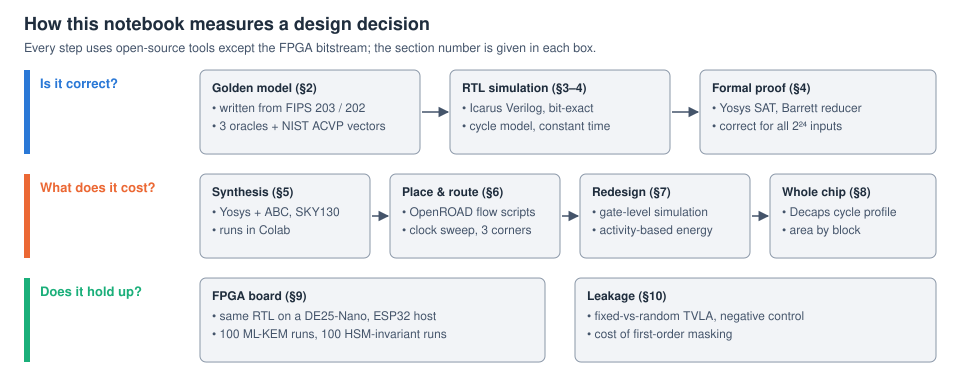

Question,Result,Value,Section
Is it correct?,RTL against the golden model,"0 mismatches over 208,896 NTT coefficients and 404 Keccak permutations, constant latency",§4
,Complete RTL against NIST ACVP keyGen,"25/25 cases byte-exact (ek, dkPKE, z), FPGA and ASIC configurations",§4
,"Barrett reducer, all 2²⁴ inputs",3 variants proven; the negative control fails as it must,§4
What does it cost?,NTT redesign after place-and-route,"area −21%, fmax 49.8 → 82.5 MHz, area × time −46%",§7
,Energy per forward NTT (routed netlist),"2.48 µJ → 1.96 µJ with the 12-bit store, 0.50 µJ with the chip's SRAM macro as the store",§6–7
,Second NTT redesign: two coefficients per SRAM word (routed),forward NTT 130 → 14.4 µs and 0.50 → 0.16 µJ against the original macro-store engine; total area +47%,§7
,Energy per Keccak permutation (routed netlists),"14.5 nJ one round per clock, 80.4 nJ row-serialized",§6
,"Decapsulation, ASIC vs FPGA choices","99,537 vs 81,457 cycles (+22%); the NTT is busy 50%, the Keccak permutation 0.8% of the time",§8
,"Decapsulation with the redesigns (RTL, whole co-processor)","99,537 → 36,110 cycles (2.8× faster), every check and output unchanged, valid and rejected ciphertexts equally long; the board agrees to the cycle",§8–9
,Full SKY130 core,"11.2 mm² die, 320,615 standard cells, 18 SRAM macros; LVS: circuits match uniquely",§8


In [3]:
import re
display(SVG(filename=str(ROOT/"figures/method_flow.svg")))
R_ = ROOT/"results"
sim_logs = " ".join((R_/"sim"/f"{n}.log").read_text() for n in ["ntt_dualport", "ntt_singleport", "keccak_round", "keccak_serial"])
n_err = sum(int(e) for e in re.findall(r"errors=(\d+)", sim_logs))
n_coef = sum(int(c) for c in re.findall(r"coeffs_checked=(\d+)", sim_logs))
n_kec = sum(int(v) for v in re.findall(r"KECCAK_RESULT serial=\d vectors=(\d+)", sim_logs))
assert n_err == 0 and set(re.findall(r"timing_variations=(\d+)", sim_logs)) == {"0"}
proofs = json.loads((R_/"formal/summary.json").read_text())["results"]
acvp_rtl = json.loads((R_/"acvp_rtl/keygen_asic.json").read_text())
assert all(json.loads((R_/f"acvp_rtl/keygen_{c}.json").read_text())["passed"] == 25 for c in ("fpga", "asic"))
dse =pd.read_csv(R_/"dse_metrics.csv").set_index(["variant", "clk_target_ns"])
o, n = dse.loc[("ntt_sp", 20.0)], dse.loc[("ntt_opt_pipe_w12", 20.0)]
gls = {r: json.loads((R_/"gls_power"/r/"summary.json").read_text()) for r in ["ntt_sp_20ns", "ntt_opt_b1_w12_20ns", "ntt_opt_pipe_w12_20ns"]}
e_uj = {r: g["energy_per_forward_ntt_nj"] / 1e3 for r, g in gls.items()}
e_macro = json.loads((R_/"gls_power/ntt_macro_20ns/summary.json").read_text())["energy_per_forward_ntt_nj"] / 1e3
pkd, mac0 = dse.loc[("ntt_packed", 20.0)], dse.loc[("ntt_macro", 20.0)]
e_pk = json.loads((R_/"gls_power/ntt_packed_20ns/summary.json").read_text())["energy_per_forward_ntt_nj"] / 1e3
a_m0, a_pk = (sum(total_area(r)) for r in ("ntt_macro_20ns", "ntt_packed_20ns"))
psy_ = json.loads((R_/"system_sim/packed_system.json").read_text())["steps"]
kj = {v: json.loads((R_/"gls_power"/f"{v}_20ns"/"summary.json").read_text())["energy_per_permutation_nj"]
      for v in ["keccak_r1", "keccak_s7"]}
prof_ = {c: v["profile"] for c, v in json.loads((R_/"system_sim/decaps_profile.json").read_text())["configs"].items()}
c3 = pd.read_csv(R_/"fpga/c3_repeat.csv"); bank_ = pd.read_csv(R_/"fpga/bank_repeat.csv")
tv = {k: json.loads((R_/d/"tvla_summary.json").read_text()) for k, d in [("plain", "leakage"), ("masked", "leakage_masked")]}
chip = json.loads((R_/"fullchip/summary.json").read_text()); cm = chip["orfs_metrics"]
pw_ = json.loads((R_/"fullchip/power.json").read_text())
e_ = {k: v * pw_["window_cycles"] * pw_["clock_ns"] * 1e-6 for k, v in pw_["power_mw"].items()}   # uJ per decapsulation
e_["sram"] = json.loads((R_/"fullchip/sram_energy.json").read_text())["sram_energy_per_decaps_uj"]
e_tot = sum(e_.values())
rows = [
    ("Is it correct?", "RTL against the golden model",
     f"{n_err} mismatches over {n_coef:,} NTT coefficients and {n_kec} Keccak permutations, constant latency", "§4"),
    ("", "Complete RTL against NIST ACVP keyGen",
     f"{acvp_rtl['passed']}/{acvp_rtl['cases']} cases byte-exact (ek, dkPKE, z), FPGA and ASIC configurations", "§4"),
    ("", "Barrett reducer, all 2²⁴ inputs",
     f"{sum(v.startswith('PROVEN') for v in proofs.values())} variants proven; the negative control fails as it must", "§4"),
    ("What does it cost?", "NTT redesign after place-and-route",
     f"area {n.cell_area_um2 / o.cell_area_um2 - 1:+.0%}, fmax {o.fmax_mhz:.1f} → {n.fmax_mhz:.1f} MHz, "
     f"area × time {n.at_product / o.at_product - 1:+.0%}", "§7"),
    ("", "Energy per forward NTT (routed netlist)",
     f"{e_uj['ntt_sp_20ns']:.2f} µJ → {e_uj['ntt_opt_b1_w12_20ns']:.2f} µJ with the 12-bit store, "
     f"{e_macro:.2f} µJ with the chip's SRAM macro as the store", "§6–7"),
    ("", "Second NTT redesign: two coefficients per SRAM word (routed)",
     f"forward NTT {mac0.latency_us_at_fmax:.0f} → {pkd.latency_us_at_fmax:.1f} µs and {e_macro:.2f} → {e_pk:.2f} µJ "
     f"against the original macro-store engine; total area {a_pk / a_m0 - 1:+.0%}", "§7"),
    ("", "Energy per Keccak permutation (routed netlists)",
     f"{kj['keccak_r1']:.1f} nJ one round per clock, {kj['keccak_s7']:.1f} nJ row-serialized", "§6"),
    ("", "Decapsulation, ASIC vs FPGA choices",
     f"{prof_['asic']['cycles']:,} vs {prof_['fpga']['cycles']:,} cycles "
     f"(+{prof_['asic']['cycles'] / prof_['fpga']['cycles'] - 1:.0%}); the NTT is busy "
     f"{prof_['fpga']['ntt_busy'] / prof_['fpga']['cycles']:.0%}, the Keccak permutation "
     f"{prof_['fpga']['perm_busy'] / prof_['fpga']['cycles']:.1%} of the time", "§8"),
    ("", "Decapsulation with the redesigns (RTL, whole co-processor)",
     f"{psy_['published']:,} → {psy_['D']:,} cycles ({psy_['published'] / psy_['D']:.1f}× faster), every check "
     f"and output unchanged, valid and rejected ciphertexts equally long; the board agrees to the cycle", "§8–9"),
    ("", "Full SKY130 core",
     f"{cm['finish__design__die__area'] / 1e6:.1f} mm² die, {cm['finish__design__instance__count__stdcell']:,} standard cells, "
     f"{cm['finish__design__instance__count__macros']} SRAM macros; LVS: {chip['signoff']['primary_compare'].lower()}", "§8"),
    ("", "Energy per decapsulation (full chip, 25 MHz)",
     f"{e_tot / 1e3:.2f} mJ: clock network and register clock pins {(e_['clock'] + e_['sequential']) / e_tot:.0%}, "
     f"SRAM macros {e_['sram'] / e_tot:.0%}, combinational logic {e_['combinational'] / e_tot:.0%}", "§8"),
    ("Does it hold up?", "Same RTL on the DE25-Nano",
     f"{int(c3.result_pass.sum())}/{len(c3)} two-role ML-KEM runs and "
     f"{int((bank_.filter(like='bank_') == 'PASS').all(axis=1).sum())}/{len(bank_)} HSM-invariant runs pass", "§9"),
    ("", "Fixed-vs-random TVLA (simulated)",
     f"largest t-statistic {tv['plain']['max_abs_t']:.1f} unmasked, {tv['masked']['max_abs_t']:.1f} with first-order "
     f"masking (leakage threshold 4.5)", "§10"),
]
# the three results quoted above the figure
mac0, mac1 = dse.loc[("ntt_macro", 20.0)], dse.loc[("ntt_opt_pipe_macro", 20.0)]
assert round(mac0.fmax_mhz) == 48 and round(mac1.fmax_mhz) == 83
assert 1.6 < n.fmax_mhz / o.fmax_mhz < 1.75 and 0.5 < n.at_product / o.at_product < 0.6
sysd = json.loads((R_/"system_sim/summary.json").read_text())
assert sysd["decomposition"]["keccak_serial_delta"] / int(sysd["configs"]["fpga"]["decaps_cycles"]) < 0.05
assert prof_["fpga"]["perm_busy"] / prof_["fpga"]["cycles"] < 0.01 and 0.45 < prof_["fpga"]["ntt_busy"] / prof_["fpga"]["cycles"] < 0.55
assert 8.5 < mac0.latency_us_at_fmax / pkd.latency_us_at_fmax < 9.5 and 0.28 < e_pk / e_macro < 0.38   # "nine times", "a third"
assert (psy_["published"], psy_["D"]) == (99537, 36110)
nbd.show(pd.DataFrame([(q, r, v.replace('-', '−') if v.startswith('area ') else v, s) for q, r, v, s in rows],
                      columns=["Question", "Result", "Value", "Section"]))

## 1. Context: where these blocks sit in HSKEM

HSKEM (working name TrustEdge-PQC) is a security co-processor. An ESP32 host issues commands over SPI,
while the co-processor keeps every secret on chip, runs ML-KEM-512 key generation, encapsulation and
decapsulation, derives a device root key from a ring-oscillator physically unclonable function (PUF) and
stores wrapped keys in an A/B vault that survives power loss. I built it on the DE25-Nano board, where it
occupies about 39,000 adaptive logic modules (ALMs) at 50 MHz, and then ported its digital core to SKY130.

Most of the arithmetic in ML-KEM is either polynomial arithmetic in $\mathbb{Z}_{3329}[X]/(X^{256}+1)$,
accelerated by the NTT (seven layers of 128 butterflies per transform), or Keccak-f[1600] [2, 4], the
permutation behind SHAKE and SHA-3, which expands the public matrix, samples noise and hashes keys and
ciphertexts. The *same RTL* serves the FPGA and the ASIC, with one architectural switch in each block:

| Block | FPGA choice | ASIC choice | Why the ASIC differs |
|:---|:---|:---|:---|
| NTT coefficient store | true dual-port RAM (one M20K block) | single-port SRAM | The chip uses OpenRAM's single-port macros; dual-port or banked macros were not evaluated. |
| Keccak round | one full round per clock | row-serialized round (seven clocks) | I expected the 1600-bit round logic to be costly in standard cells. |

The rest of the notebook measures what these two decisions actually cost.

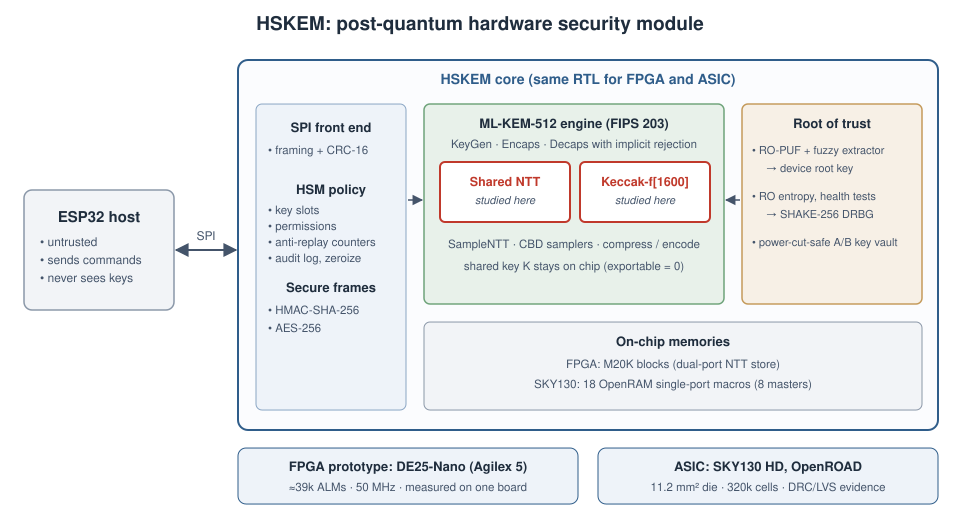

In [4]:
display(SVG(filename=str(ROOT/"figures/hskem_architecture.svg")))

# Part I — Is it correct?

A cost is only worth measuring for a design that computes the right result. This part checks the RTL
against a reference that owes nothing to it, up to the official NIST vectors.

## 2. An independent golden model

The model in `golden/mlkem_ref.py` is written from the text of FIPS 203 and FIPS 202 alone [1, 2]; its
twiddle factors, for example, are recomputed as $\zeta^{\mathrm{BitRev}_7(i)} \bmod q$ with $\zeta = 17$
rather than copied from the RTL. Three oracles that share no code with it check the model:

1. **Mathematics:** $\mathrm{NTT}^{-1}(\mathrm{NTT}(a) \circ \mathrm{NTT}(b))$ must equal the schoolbook negacyclic product $a\cdot b \bmod (X^{256}+1)$.
2. **An independent implementation:** the NTT must agree with [`kyber-py`](https://github.com/GiacomoPope/kyber-py) [12].
3. **The Python standard library:** a SHA3-256 sponge built on my Keccak-f must reproduce `hashlib.sha3_256`.

In [5]:
print("first twiddles:", ref.ZETAS[:8], " 128^-1 mod q =", ref.INV128)
print(ref.self_check(trials=50))

first twiddles: [1, 1729, 2580, 3289, 2642, 630, 1897, 848]  128^-1 mod q = 3303


{'ntt_trials': 50, 'kyber_py_crosscheck': 50, 'sha3_lengths': 6}


### From blocks to the whole KEM: NIST ACVP vectors

On top of these blocks, `golden/mlkem_full.py` implements the complete ML-KEM-512 scheme, implicit
rejection included, and is checked against the official vectors of NIST's Automated Cryptographic
Validation Protocol (ACVP) [3], stored with their provenance in `golden/acvp/`: 25 key generations, 25
encapsulations and 10 decapsulations, some with modified ciphertexts. Two negative controls show that the
check is able to fail: flipping a single input bit must change the result, and a tampered ciphertext must
decapsulate to the implicit-rejection key $J(z\,\|\,c)$ instead of the genuine shared secret.

In [6]:
import mlkem_full as kem
acvp = kem.acvp_check()
print("NIST ACVP ML-KEM-512:", acvp)
assert all(v.split("/")[0] == v.split("/")[1] for v in acvp.values())

x = bytes.fromhex
tv = json.loads((ROOT/"golden/acvp/mlkem512_keygen.json").read_text())[0]
d = bytearray(x(tv["d"])); d[0] ^= 1
assert kem.keygen_internal(bytes(d), x(tv["z"]))[0] != x(tv["ek"]), "negative control failed"
dv = [t for t in json.loads((ROOT/"golden/acvp/mlkem512_encapdecap.json").read_text())["decapsulation"]
      if t["reason"] == "valid decapsulation"][0]
c = bytearray(x(dv["c"])); c[10] ^= 1
k_rej = kem.decaps_internal(x(dv["dk"]), bytes(c))
assert k_rej != x(dv["k"]) and k_rej == kem.J(x(dv["dk"])[-32:] + bytes(c)), "implicit rejection failed"
print("negative controls: PASS (flipped d -> different ek; tampered c -> J(z||c))")

NIST ACVP ML-KEM-512: {'keyGen': '25/25', 'encapsulation': '25/25', 'decapsulation': '10/10'}
negative controls: PASS (flipped d -> different ek; tampered c -> J(z||c))


## 3. RTL architecture and an analytical cycle model

`rtl/kyber_ntt_engine.sv` processes one butterfly at a time with a single multiplier and a Barrett
reducer [5] (`rtl/barrett_reduce.v`, $M=\lfloor 2^{24}/q \rfloor = 5039$), stepping through a small
state machine. The single-port variant needs two extra states, because both operands and both results
must take turns on one SRAM port:

| State | Dual-port | Single-port |
|:---|:---|:---|
| FETCH | read $a_j$, $a_{j+len}$ | read $a_j$ |
| CAPTURE | latch both | latch $a_j$, read $a_{j+len}$ |
| CAPTURE_B | — | latch $a_{j+len}$ |
| REDUCE | $\zeta\cdot b$, Barrett reduction | same |
| EXEC | add / subtract mod $q$ | same |
| WRITE | write both | write $a_j$ |
| WRITE_B | — | write $a_{j+len}$ |

With 896 butterflies and one start and one completion cycle, a forward NTT should therefore take
$896 \times 5 + 2$ cycles with the dual-port store and $896 \times 7 + 2$ with the single-port one; the
inverse transform adds a scaling pass of $256 \times 5$ cycles. `rtl/keccak_f1600_iter.sv` needs $24 + 1$
cycles per permutation with one round per clock, and $24\times 7 + 1$ when each round is split into a
θ-D phase, a θ/ρ/π phase and five χ/ι row phases. The controller trace below tests these predictions.

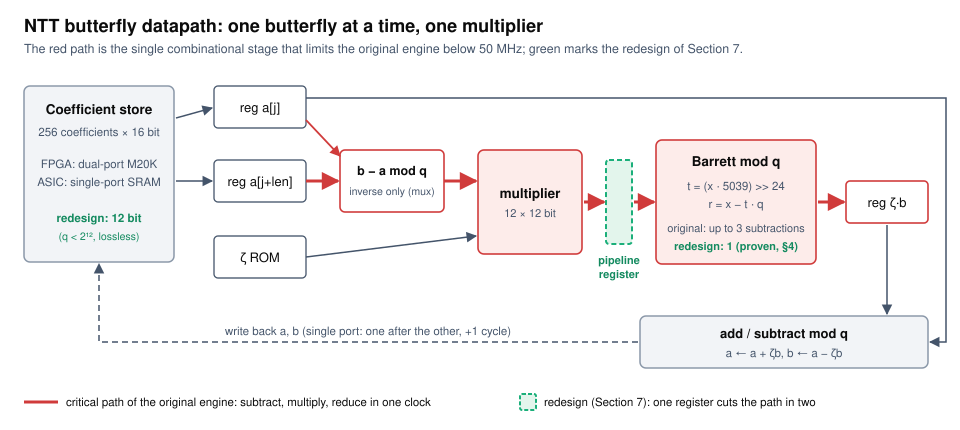

In [7]:
display(SVG(filename=str(ROOT/"figures/ntt_datapath.svg")))

In [8]:
model = {
    "ntt_dp": {"fwd": 896*5 + 2, "inv": 896*5 + 256*5 + 2},
    "ntt_sp": {"fwd": 896*7 + 2, "inv": 896*7 + 256*5 + 2},
    "keccak_r1": {"perm": 24*1 + 1},
    "keccak_s7": {"perm": 24*7 + 1},
}
model

{'ntt_dp': {'fwd': 4482, 'inv': 5762},
 'ntt_sp': {'fwd': 6274, 'inv': 7554},
 'keccak_r1': {'perm': 25},
 'keccak_s7': {'perm': 169}}

### Watching the controller work

`scripts/fsm_trace.sh` simulates one forward transform of each NTT variant with Icarus Verilog and samples
the controller's state at every clock edge. The trace confirms that the 896 butterflies follow the order
of FIPS 203, Algorithm 9, and that the transform lasts exactly as many cycles as the model predicts; its
first butterflies show where the single-port variant spends its two extra cycles.

both controllers visit all 896 butterflies in FIPS 203 order; cycles per forward transform: {'ntt_dp': 4482, 'ntt_sp': 6274}


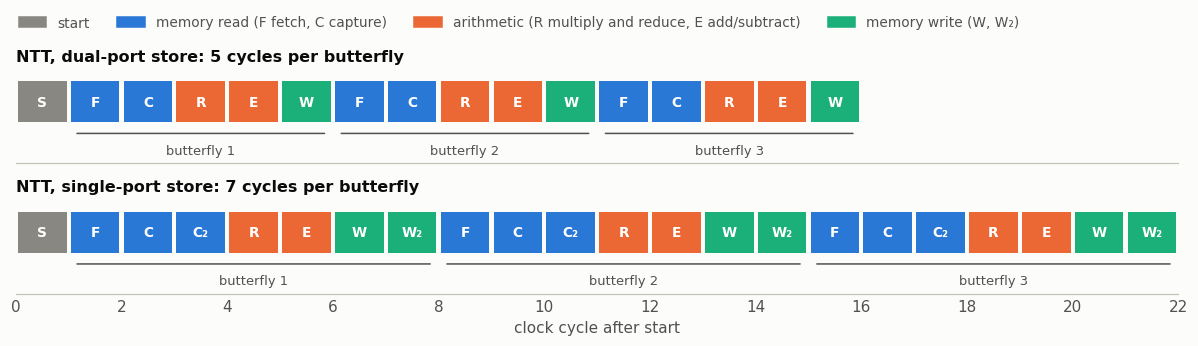

In [9]:
if IN_COLAB or not (ROOT/"results/fsm_trace/ntt_sp.csv").exists():
    sh("bash scripts/fsm_trace.sh 7000")
tr = {v: pd.read_csv(ROOT/"results/fsm_trace"/f"{v}.csv") for v in ["ntt_dp", "ntt_sp"]}
fips_order = [(L, j) for L in (128, 64, 32, 16, 8, 4, 2) for s in range(0, 256, 2 * L) for j in range(s, s + L)]
for v, d in tr.items():
    f = d[d.state == "FETCH"]
    assert list(zip(f.len, f.j)) == fips_order, f"{v}: butterfly order differs from FIPS 203"
    assert len(d) == model[v]["fwd"], f"{v}: trace length differs from the cycle model"
print("both controllers visit all 896 butterflies in FIPS 203 order; cycles per forward transform:",
      {v: len(d) for v, d in tr.items()})

KIND = {"IDLE": ("start", ps.MUTED), "FETCH": ("memory read", ps.SERIES[0]), "CAPTURE": ("memory read", ps.SERIES[0]),
        "CAPTURE_B": ("memory read", ps.SERIES[0]), "REDUCE": ("arithmetic", ps.SERIES[1]),
        "EXEC": ("arithmetic", ps.SERIES[1]), "WRITE": ("memory write", ps.SERIES[2]), "WRITE_B": ("memory write", ps.SERIES[2])}
SHORT = {"IDLE": "S", "FETCH": "F", "CAPTURE": "C", "CAPTURE_B": "C₂", "REDUCE": "R", "EXEC": "E", "WRITE": "W", "WRITE_B": "W₂"}
fig, axes = plt.subplots(2, 1, figsize=(11, 2.9), sharex=True)
for ax, v in zip(axes, ["ntt_dp", "ntt_sp"]):
    per = 5 if v == "ntt_dp" else 7
    d = tr[v].iloc[: 1 + 3 * per]
    for c, s in zip(d.cycle, d.state):
        ax.barh(0, 0.92, left=c + 0.04, height=0.8, color=KIND[s][1])
        ax.text(c + 0.5, 0, SHORT[s], ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    for b in range(3):
        ax.annotate("", (1 + b * per + 0.1, -0.62), (1 + (b + 1) * per - 0.1, -0.62),
                    arrowprops=dict(arrowstyle="-", color=ps.INK_2, lw=1))
        ax.text(1 + b * per + per / 2, -0.95, f"butterfly {b + 1}", ha="center", va="center", fontsize=8.5, color=ps.INK_2)
    ax.set_ylim(-1.2, 0.5); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{LABEL[v]}: {per} cycles per butterfly", fontsize=10.5)
    ax.spines["left"].set_visible(False)
axes[-1].set_xlabel("clock cycle after start"); axes[-1].set_xlim(0, 1 + 3 * 7)
axes[-1].set_xticks(range(0, 23, 2))
from matplotlib.patches import Patch
fig.legend([Patch(color=c) for c in (ps.MUTED, ps.SERIES[0], ps.SERIES[1], ps.SERIES[2])],
           ["start", "memory read (F fetch, C capture)", "arithmetic (R multiply and reduce, E add/subtract)",
            "memory write (W, W₂)"], ncols=4, loc="lower left", bbox_to_anchor=(0.01, 0.97), frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

## 4. RTL against the golden model and the NIST vectors

`scripts/run_sim.sh` runs four testbenches on vectors from the golden model, corner cases followed by
random inputs. Each compares every output exactly and flags any vector whose latency differs from the
others, which doubles as a constant-time check; raising `N` runs more random vectors.

In [10]:
N = 60   # random vectors per block (the committed logs used 200)
# writes to results/sim_notebook so the committed 200-vector logs in results/sim stay untouched
out = sh(f"CAC_SIM_OUT=results/sim_notebook CAC_VEC_OUT=vectors_notebook bash scripts/run_sim.sh --ntt {N} --keccak {N} | grep -E 'RESULT|PASS|FAIL'")

NTT_RESULT vectors=64 coeffs_checked=32768 errors=0 cycles_fwd=4482 cycles_inv=5762 timing_variations=0
PASS
NTT_RESULT vectors=64 coeffs_checked=32768 errors=0 cycles_fwd=6274 cycles_inv=7554 timing_variations=0
PASS
KECCAK_RESULT serial=0 vectors=62 errors=0 cycles=25 timing_variations=0
PASS
KECCAK_RESULT serial=1 vectors=62 errors=0 cycles=169 timing_variations=0
PASS
 


In [11]:
import re
SIM_DIR = "results/sim_notebook"   # this run; results/sim holds the committed 200-vector run
def parse_sim():
    rows = {}
    for name, key in [("ntt_dualport","ntt_dp"),("ntt_singleport","ntt_sp"),("keccak_round","keccak_r1"),("keccak_serial","keccak_s7")]:
        log = (ROOT/SIM_DIR/f"{name}.log").read_text()
        d = {k: int(v) for k, v in re.findall(r"(\w+)=(\d+)", log.split("RESULT",1)[1].splitlines()[0])}
        d["pass"] = "PASS" in log
        rows[key] = d
    return pd.DataFrame(rows).T
sim = parse_sim()
sim["model_fwd_or_perm"] = [model[k].get("fwd", model[k].get("perm")) for k in sim.index]
sim["model_inv"] = [model[k].get("inv", np.nan) for k in sim.index]
sim["cycles_measured"] = [int(r.cycles_fwd) if pd.notna(r.get("cycles_fwd")) else int(r.cycles) for _, r in sim.iterrows()]
assert (sim["cycles_measured"] == sim["model_fwd_or_perm"]).all(), "analytical model disagrees with RTL"
assert (sim.loc[["ntt_dp","ntt_sp"], "cycles_inv"] == sim.loc[["ntt_dp","ntt_sp"], "model_inv"]).all()
assert (sim["timing_variations"] == 0).all() and sim["pass"].all()
sim

,vectors,coefficients checked,errors,"cycles, forward NTT","cycles, inverse NTT",latency variations,pass,row-serialized,cycles,model: forward NTT / permutation,model: inverse NTT,cycles measured
"NTT, dual-port store",64,32768,0,4482,5762,0,True,,,4482,5762,4482
"NTT, single-port store",64,32768,0,6274,7554,0,True,,,6274,7554,6274
"Keccak, one round per clock",62,,0,,,0,True,0,25,25,,25
"Keccak, row-serialized",62,,0,,,0,True,1,169,169,,169


### A formal proof for the modular reducer

Simulation covers only the vectors it is given, but the Barrett reducer's 24-bit input allows a proof
for all $2^{24}$ inputs, which `formal/prove_barrett.sh` obtains from Yosys' SAT solver. The proof also
settles a design question. The RTL applies up to three conditional subtractions of $q$, yet for this $M$
one suffices: the reducer is proven correct with three, two and one subtraction, while a negative control
with none fails with a concrete counterexample.

barrett_proof                              no model found: SUCCESS!
barrett_no_third_correction                no model found: SUCCESS!
barrett_one_correction                     no model found: SUCCESS!
barrett_negative_control_no_correction     model found: FAIL!


exhaustive check: pre-correction remainder in [0, 5713] < 2q; 6,012,719 inputs need exactly one subtraction, none need two


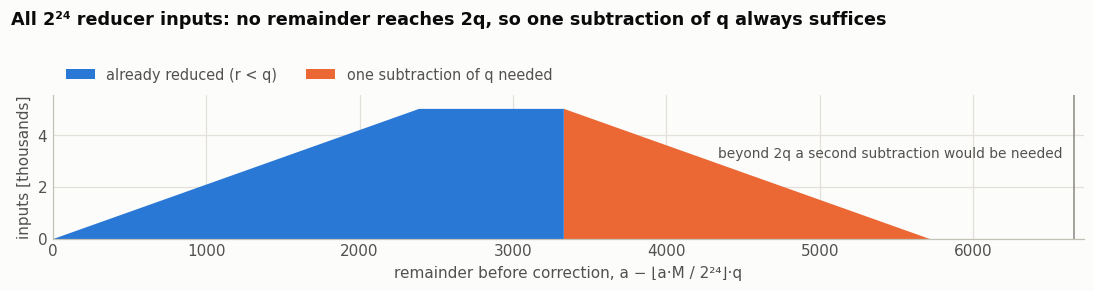

In [12]:
RUN_FORMAL = False   # True re-runs the four SAT proofs (about 15 minutes on one core)
if RUN_FORMAL:
    for impl, tag in [("../rtl/barrett_reduce.v", "barrett_proof"),
                      ("barrett_reduce_no_r3.v", "barrett_no_third_correction"),
                      ("barrett_reduce_one_correction.v", "barrett_one_correction"),
                      ("barrett_reduce_mutant_none.v", "barrett_negative_control_no_correction")]:
        sh(f"bash formal/prove_barrett.sh {impl} {tag}")
for tag in ["barrett_proof", "barrett_no_third_correction", "barrett_one_correction",
            "barrett_negative_control_no_correction"]:
    log = (ROOT/"results/formal"/f"{tag}.log").read_text()
    verdict = re.search(r"SAT proof finished - (.*)", log)[1]
    print(f"{tag:42s} {verdict}")

# independent exhaustive cross-check of the same arithmetic
a = np.arange(1 << 24, dtype=np.int64)
r0 = a - ((a * 5039) >> 24) * 3329
assert r0.min() >= 0 and r0.max() < 2 * 3329
r1 = np.where(r0 >= 3329, r0 - 3329, r0)
assert (r1 == a % 3329).all() and not (r0 == a % 3329).all()
print(f"exhaustive check: pre-correction remainder in [{r0.min()}, {r0.max()}] < 2q; "
      f"{int((r0 >= 3329).sum()):,} inputs need exactly one subtraction, none need two")

# where the 2^24 pre-correction remainders fall
hist = np.bincount(r0, minlength=2 * 3329)
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.fill_between(np.arange(3329), hist[:3329] / 1e3, step="mid", color=ps.SERIES[0], lw=0, label="already reduced (r < q)")
ax.fill_between(np.arange(3329, 2 * 3329), hist[3329:2 * 3329] / 1e3, step="mid", color=ps.SERIES[1], lw=0,
                label="one subtraction of q needed")
ps.reference_line(ax, 2 * 3329, axis="x")
ax.annotate("beyond 2q a second subtraction would be needed", (2 * 3329, hist.max() / 1e3 * 0.62), xytext=(-8, 0),
            textcoords="offset points", ha="right", fontsize=9, color=ps.INK_2)
ax.set_xlim(0, 2 * 3329 + 60); ax.set_ylim(0, hist.max() / 1e3 * 1.1)
ax.set_xlabel("remainder before correction, a − ⌊a·M / 2²⁴⌋·q"); ax.set_ylabel("inputs [thousands]")
ax.legend(ncols=2, loc="lower left", bbox_to_anchor=(0, 1.0))
fig.suptitle("All 2²⁴ reducer inputs: no remainder reaches 2q, so one subtraction of q always suffices",
             x=0.01, ha="left", y=1.0, fontsize=11.5, fontweight="bold")
ps.finish(fig); plt.show()

### The complete co-processor against the NIST vectors

The complete RTL can face the NIST vectors directly, because its SPI interface accepts a deterministic
key-generation seed for test purposes. `scripts/acvp_rtl_keygen.py` runs all 25 ACVP key-generation
cases in the FPGA and the ASIC configuration and compares the key memories with the NIST answers byte
for byte, covering every part of the decapsulation key except a hash of the already compared
encapsulation key; a negative control with $k = 3$ must fail. Encapsulation and decapsulation cannot be
driven this way, since the co-processor accepts no external key, so the full-system testbench of
Section 8 checks them against an independent software model.

In [13]:
RUN_ACVP_RTL = IN_COLAB   # about one minute per configuration
if RUN_ACVP_RTL:
    for cfg in ("fpga", "asic"):
        print(sh(f"python3 scripts/acvp_rtl_keygen.py {cfg}").strip().splitlines()[-1])
for cfg in ("fpga", "asic"):
    r = json.loads((ROOT/f"results/acvp_rtl/keygen_{cfg}.json").read_text())
    diff = sum(c[k] for c in r["details"] for k in c if k.endswith("bytes_diff"))
    print(f"{cfg}: {r['passed']} of {r['cases']} ACVP keyGen cases byte-exact (ekPKE, dkPKE, z; {diff} differing bytes); "
          f"negative control k = 3: {r['negative_control']['ekpke_t_bytes_diff_vs_case_0']} of 768 bytes of t differ")
    assert r["passed"] == r["cases"] == 25 and diff == 0 and r["negative_control"]["ekpke_t_bytes_diff_vs_case_0"] > 0

fpga: 25 of 25 ACVP keyGen cases byte-exact (ekPKE, dkPKE, z; 0 differing bytes); negative control k = 3: 766 of 768 bytes of t differ
asic: 25 of 25 ACVP keyGen cases byte-exact (ekPKE, dkPKE, z; 0 differing bytes); negative control k = 3: 766 of 768 bytes of t differ


# Part II — What does each decision cost?

With correctness established, the two decisions can be priced: first by logic synthesis, which runs in
Colab, then after place-and-route, where wires and the clock tree take their share, and finally across
the whole chip, where what matters is how often the system waits for each block. Between the second and
third step, Section 7 turns the measurements into two redesigns of the NTT. The figures of merit are defined
once, here:

| Quantity | Definition |
|:---|:---|
| fmax | $1/(T - \mathrm{slack}_{reg\to reg})$ of the routed block at the typical corner (Appendix B.1 explains why register-to-register) |
| latency, area × time | cycles of one operation / fmax; standard-cell plus macro area × latency |
| energy per operation | $P \cdot N_\mathrm{cycles} \cdot T$ at the 20 ns clock, with $P$ from OpenSTA: gate-level activity of one operation on the extracted parasitics |
| SRAM energy | $V_\mathrm{DD}\int i_\mathrm{DD}\,dt$ over each clock cycle of a transistor-level simulation of the macro |
| decapsulation | the first profiled decapsulation of the full-system testbench, from its second busy cycle; 25 MHz on the chip |

All figures are for the typical corner (25 °C, 1.8 V) unless a column says otherwise.

## 5. Synthesis: the second port costs a third more area, serializing Keccak saves none

`scripts/synth_sky130.sh` synthesizes each point with Yosys and ABC [11] to the `sky130_fd_sc_hd` library
and reports its area and combinational delay, an estimate without wires or clock tree. The NTT store is
built from flip-flops here, so that both memory variants compete on equal terms, and both Keccak cores
sit in the same lane wrapper, so that any difference between them belongs to the core.

In [14]:
SWEEP_CLOCKS = "20"          # "10 20 40" reproduces the full sweep (~15 min)
if IN_COLAB or not list((ROOT/"results/synth").glob("*/summary.json")):
    sh(f"bash scripts/synth_sweep.sh 'ntt_dp ntt_sp keccak_r1 keccak_s7' '{SWEEP_CLOCKS}'")
syn = []
for p in sorted((ROOT/"results/synth").glob("*/summary.json")):
    v, t = re.match(r"(\w+?_\w+?)_(\d+)ns", p.parent.name).groups()
    syn.append({"variant": v, "clk_ns": int(t), **json.loads(p.read_text())})
syn = pd.DataFrame(syn).sort_values(["variant","clk_ns"]).reset_index(drop=True)
syn["cycles"] = syn.variant.map(sim["cycles_measured"])
syn

design,clock target [ns],cell area [µm²],cells,ABC delay estimate [ns],cycles
"Keccak, one round per clock",10,201281.7952,23103,2.4111,25
"Keccak, one round per clock",20,201281.7952,23103,2.4111,25
"Keccak, one round per clock",40,201281.7952,23103,2.4111,25
"Keccak, row-serialized",10,203970.6240,23768,2.5073,169
"Keccak, row-serialized",20,203970.6240,23768,2.5073,169
"Keccak, row-serialized",40,203970.6240,23768,2.5073,169
"NTT, dual-port store",10,238319.8176,27672,15.5569,4482
"NTT, dual-port store",20,238039.5488,27672,18.3328,4482
"NTT, dual-port store",40,238039.5488,27672,18.3328,4482
NTT iteration: 1-subtraction Barrett,10,182372.4096,13164,15.6251,


**Reading the synthesis table.** The dual-port NTT adds a second write port and a second read-multiplexer
tree to the same 4096 stored bits. The row-serialized Keccak computes χ/ι for one row instead of five but
pays with a 320-bit θ-D register and a wider next-state selection, which leaves it about one percent
larger. The cell groups below show where each design spends its area.

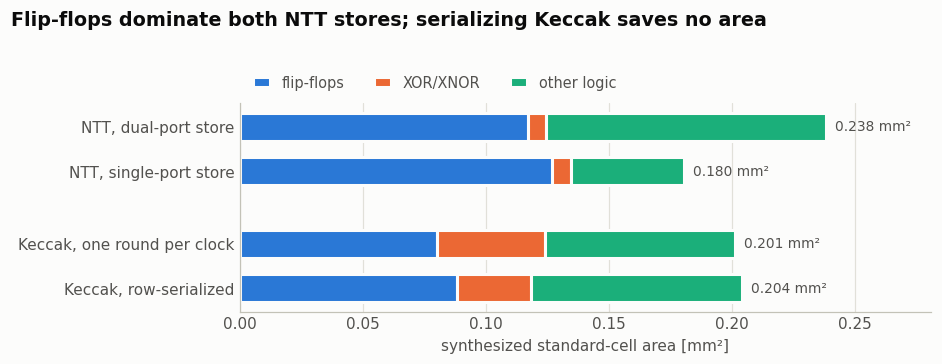

,flip-flops,XOR/XNOR,other logic
"NTT, dual-port store",0.1171,0.0074,0.1136
"NTT, single-port store",0.1269,0.0078,0.0458
"Keccak, one round per clock",0.0803,0.0438,0.0773
"Keccak, row-serialized",0.0884,0.0301,0.0855


In [15]:
def cell_groups(variant, clk=20):
    st = (ROOT/"results/synth"/f"{variant}_{clk}ns"/"stat.txt").read_text()
    g = {"flip-flops": 0.0, "XOR/XNOR": 0.0, "other logic": 0.0}
    for n, area, cell in re.findall(r"^\s*(\d+)\s+([\d.E+-]+)\s+sky130_fd_sc_hd__(\w+)", st, re.M):
        k = "flip-flops" if cell.startswith(("df", "edf")) else "XOR/XNOR" if cell.startswith(("xor", "xnor")) else "other logic"
        g[k] += float(area)
    return g
grp = pd.DataFrame({v: cell_groups(v) for v in ["ntt_dp", "ntt_sp", "keccak_r1", "keccak_s7"]}).T / 1e6

fig, ax = plt.subplots(figsize=(8.6, 3.2))
rows = list(grp.index)[::-1]
ypos = {v: y for y, v in zip([0, 0.8, 2.1, 2.9], rows)}          # a gap separates the two families
left = np.zeros(len(rows))
for slot, part in enumerate(grp.columns):
    vals = grp.loc[rows, part].values
    ax.barh([ypos[v] for v in rows], vals, left=left, height=0.5, label=part, **ps.bar_kw(ps.SERIES[slot]))
    left += vals
for v, total in zip(rows, left):
    ax.annotate(f"{total:.3f} mm²", (total, ypos[v]), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=ps.INK_2)
ax.set_yticks([ypos[v] for v in rows], [LABEL[v] for v in rows])
ax.set_xlabel("synthesized standard-cell area [mm²]")
ax.set_xlim(0, left.max() * 1.18); ax.grid(axis="y", visible=False)
ax.legend(ncols=3, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1.2)
ps.finish(fig, title="Flip-flops dominate both NTT stores; serializing Keccak saves no area"); plt.show()
grp.round(4)

## 6. Place-and-route: the dual-port store loses its speed, the serialized Keccak its purpose

Each design point was then taken through the complete OpenROAD-flow-scripts (ORFS) flow [8] for the
SKY130 HD library [10] at a common 20 ns clock target; Appendix B holds every routed run, the clock sweep,
the process corners and the layouts.

In [16]:
if RUN_PNR:
    sh("bash scripts/sweep.sh 'ntt_dp ntt_sp keccak_r1 keccak_s7' '20' 4")
sh("python3 scripts/collect_metrics.py > /dev/null")
pnr = pd.read_csv(ROOT/"results/dse_metrics.csv")
# the four architecture points at the common 20 ns target; Appendix B.1 lists every routed run
arch = ["ntt_dp", "ntt_sp", "keccak_r1", "keccak_s7"]
a20 = pnr[(pnr.clk_target_ns == 20) & pnr.variant.isin(arch)].set_index("variant").loc[arch]
pd.DataFrame({
    "cell area [mm²]": a20.cell_area_um2 / 1e6,
    "flip-flops": a20.flops.astype(int),
    "reg→reg fmax [MHz]": a20.fmax_mhz,
    "cycles per operation": a20.cycles.astype(int),
    "latency [µs]": a20.latency_us_at_fmax,
    "area × time [mm²·µs]": a20.at_product,
    "DRC / antenna": a20.drc_errors.astype(int).astype(str) + " / " + a20.antenna_violating_nets.astype(int).astype(str),
}).rename(index=LABEL).round(3)

design,cell area [mm²],flip-flops,reg→reg fmax [MHz],cycles per operation,latency [µs],area × time [mm²·µs],DRC / antenna
"NTT, dual-port store",0.288,4277,47.483,4482,94.391,27.157,0 / 0
"NTT, single-port store",0.216,4267,49.751,6274,126.107,27.225,0 / 0
"Keccak, one round per clock",0.234,3207,181.159,25,0.138,0.032,0 / 0
"Keccak, row-serialized",0.231,3534,130.208,169,1.298,0.300,0 / 0


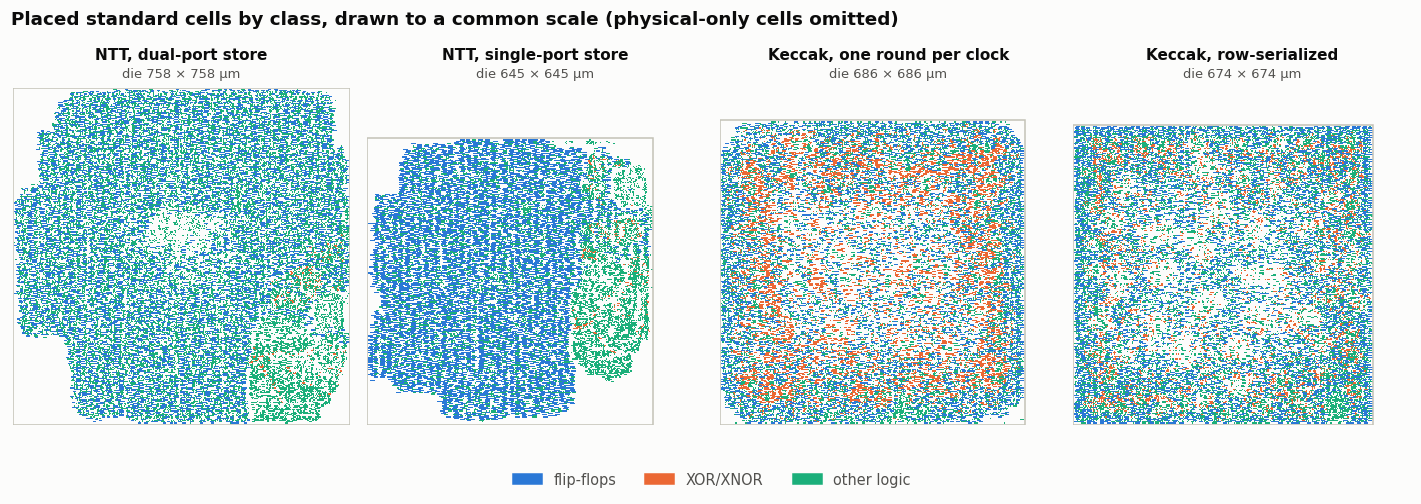

In [17]:
import placement_map as pm
from matplotlib.patches import Patch
runs = ["ntt_dp_20ns", "ntt_sp_20ns", "keccak_r1_20ns", "keccak_s7_20ns"]
extent = max((lambda b: max(b[2] - b[0], b[3] - b[1]))(pm.load(r)[1]) for r in runs)
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, r in zip(axes, runs):
    pm.draw(ax, r, LABEL[r.rsplit("_", 1)[0]], extent=extent)
fig.legend([Patch(color=c) for _, c in pm.CLASSES], [n for n, _ in pm.CLASSES], ncols=3,
           loc="upper center", bbox_to_anchor=(0.5, 0.0), frameon=False)
fig.suptitle("Placed standard cells by class, drawn to a common scale (physical-only cells omitted)",
             x=0.01, ha="left", y=1.02, fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

The routed numbers confirm the synthesis estimate and add a twist. The dual-port NTT is about a third
larger, and its selection logic, spread through the whole store in the placement map, lengthens the wires
enough to cost it a little speed. The two NTT variants therefore end up equal in area × time: the second
port buys a shorter transform and nothing more. Row-serializing Keccak ends up about one percent smaller after routing,
while its seven times as many cycles, at a clock about 30 % lower, make each permutation nine times
slower.

### Area–latency trade-off

The figure places each design point by standard-cell area and by latency at its own fmax, lower left
being better on both counts. A tighter clock target lifts the Keccak cores further, but both original NTT
blocks stay below 50 MHz, because their subtract–multiply–reduce path is a single combinational stage
(Appendix B.3); Section 7 removes that ceiling.

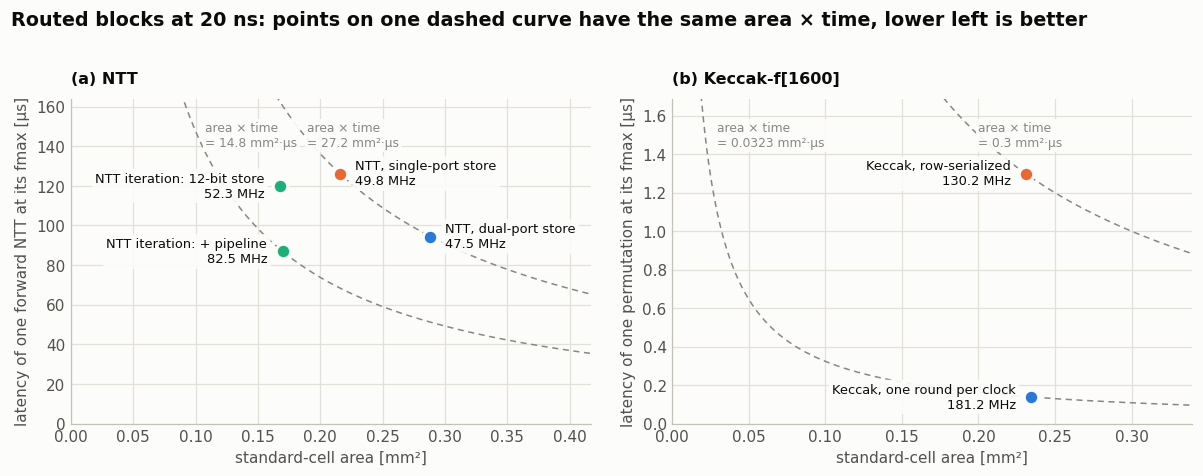

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
P20 = pnr[pnr.clk_target_ns == 20].set_index("variant")
SIDE = {"ntt_dp": 1, "ntt_sp": 1}          # labels to the right of these points, to the left of the others
for ax, tag, pts, curves, op in [
        (axes[0], "(a) NTT", ["ntt_dp", "ntt_sp", "ntt_opt_b1_w12", "ntt_opt_pipe_w12"], ["ntt_sp", "ntt_opt_pipe_w12"],
         "one forward NTT"),
        (axes[1], "(b) Keccak-f[1600]", ["keccak_r1", "keccak_s7"], ["keccak_r1", "keccak_s7"], "one permutation")]:
    a, t = P20.cell_area_um2[pts] / 1e6, P20.latency_us_at_fmax[pts]
    xmax, ymax = a.max() * 1.45, t.max() * 1.3
    xs = np.linspace(xmax * 0.03, xmax, 400)
    for v in curves:                       # every point on one dashed curve has the same area x time
        at = a[v] * t[v]
        ax.plot(xs, at / xs, color=ps.MUTED, lw=1, ls=(0, (4, 3)), zorder=1)
        ax.annotate(f"area × time\n= {at:.3g} mm²·µs", (at / (0.93 * ymax), 0.93 * ymax), xytext=(9, 0),
                    textcoords="offset points", ha="left", va="top", fontsize=8, color=ps.MUTED, zorder=2,
                    bbox=dict(boxstyle="round,pad=0.2", fc=ps.SURFACE, ec="none", alpha=0.92))
    for v in pts:
        ax.scatter(a[v], t[v], **{**ps.marker_kw(COLOR[v]), "zorder": 4})
        r = SIDE.get(v, -1)
        ax.annotate(f"{LABEL[v]}\n{P20.fmax_mhz[v]:.1f} MHz", (a[v], t[v]), xytext=(10 * r, 0), textcoords="offset points",
                    ha="left" if r > 0 else "right", va="center", fontsize=8.5, color=ps.INK, zorder=5,
                    bbox=dict(boxstyle="round,pad=0.25", fc=ps.SURFACE, ec="none", alpha=0.92))
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax)
    ax.set_xlabel("standard-cell area [mm²]"); ax.set_ylabel(f"latency of {op} at its fmax [µs]")
    ax.set_title(tag, loc="left", fontsize=10.5)
ps.finish(fig, title="Routed blocks at 20 ns: points on one dashed curve have the same area × time, lower left is better")
ps.save_pdf(fig, "area_latency"); plt.show()

### The chip's actual store: an OpenRAM macro

On the chip the store is the single-port OpenRAM macro `sky130_sram_1rw_16x256_wpr8`, so the single-port
engine was also routed with that macro. Its cycle count is unchanged, and since OpenRAM's power view is
not physical (it reports several megawatts), the macro's energy is priced with its transistor-level
access energies (Appendix C.4) and added to that of the standard cells.

In [19]:
mc = pnr[(pnr.clk_target_ns == 20) & pnr.variant.isin(["ntt_sp", "ntt_macro"])].set_index("variant").loc[["ntt_sp", "ntt_macro"]]
areas = {v: total_area(f"{v}_20ns") for v in mc.index}
store = pd.DataFrame({
    "standard cells [mm²]": [areas[v][0] / 1e6 for v in mc.index],
    "SRAM macro [mm²]": [areas[v][1] / 1e6 for v in mc.index],
    "total [mm²]": [sum(areas[v]) / 1e6 for v in mc.index],
    "die [mm²]": (mc.die_area_um2 / 1e6).values,
    "flip-flops": mc.flops.astype(int).values,
    "fmax [MHz]": mc.fmax_mhz.values,
    "area × time [mm²·µs]": [sum(areas[v]) / 1e6 * mc.loc[v, "latency_us_at_fmax"] for v in mc.index],
    "DRC / antenna": (mc.drc_errors.astype(int).astype(str) + " / " + mc.antenna_violating_nets.astype(int).astype(str)).values,
    "max-slew violations": [slew_violations(f"{v}_20ns") for v in mc.index],
}, index=["flip-flop store", "OpenRAM macro store"])
gpm = {v: json.loads((ROOT/"results/gls_power"/f"{v}_20ns"/"summary.json").read_text()) for v in mc.index}
store["energy / forward NTT [µJ]"] = [gpm[v]["energy_per_forward_ntt_nj"] / 1e3 for v in mc.index]
store["of which the SRAM macro [µJ]"] = [gpm[v].get("macro_energy_nj", float("nan")) / 1e3 for v in mc.index]
display(store.round(3).fillna("–"))
blk_ntt = pd.read_csv(ROOT/"results/fullchip/blocks.csv").set_index("block").loc["u_shared_ntt", "flops"]
print(f"flip-flops of the macro-store block: {int(mc.loc['ntt_macro', 'flops'])}; of the NTT engine on the chip: {int(blk_ntt)}")
# guards for the statements made in the text below
assert (mc.drc_errors == 0).all() and (mc.antenna_violating_nets == 0).all()
assert 0.6 < store["total [mm²]"].iloc[1] / store["total [mm²]"].iloc[0] < 0.7     # "about a third less"
assert store["standard cells [mm²]"].iloc[1] < 0.2 * store["standard cells [mm²]"].iloc[0]
# the macro is smaller than the flip-flops and multiplexers it replaces
assert store["SRAM macro [mm²]"].iloc[1] < store["standard cells [mm²]"].iloc[0] - store["standard cells [mm²]"].iloc[1]
assert abs(mc.fmax_mhz.iloc[1] / mc.fmax_mhz.iloc[0] - 1) < 0.05
assert abs(int(mc.loc["ntt_macro", "flops"]) - int(blk_ntt)) <= 2
assert store["max-slew violations"].iloc[0] == 0 < store["max-slew violations"].iloc[1]
assert all(gpm[v]["gls_pass"] for v in mc.index) and gpm["ntt_macro"]["cycles_fwd"] == gpm["ntt_sp"]["cycles_fwd"]
e_ratio_m = store["energy / forward NTT [µJ]"].iloc[1] / store["energy / forward NTT [µJ]"].iloc[0]
assert 0.15 < e_ratio_m < 0.25                                                   # "about a fifth"
assert 0.6 < gpm["ntt_macro"]["macro_energy_nj"] / gpm["ntt_macro"]["energy_per_forward_ntt_nj"] < 0.8  # "most of it"

,standard cells [mm²],SRAM macro [mm²],total [mm²],die [mm²],flip-flops,fmax [MHz],area × time [mm²·µs],DRC / antenna,max-slew violations,energy / forward NTT [µJ],of which the SRAM macro [µJ]
flip-flop store,0.216,0.000,0.216,0.416,4267,49.751,27.225,0 / 0,0,2.479,–
OpenRAM macro store,0.039,0.103,0.141,0.293,155,48.077,18.465,0 / 0,2,0.504,0.372


flip-flops of the macro-store block: 155; of the NTT engine on the chip: 154


With the macro, the standard-cell area shrinks to less than a fifth, and even with the macro counted in
full the block needs about a third less area than its flip-flop counterpart. A forward transform costs
about a fifth of the energy, most of it now spent in the macro, because 4096 flip-flops no longer receive
the clock in every cycle, while the clock rate barely changes. This is the trade-off behind the chip's
choice: a much smaller and more frugal store for two extra cycles per butterfly. The block's register
count matches the NTT engine of the integrated chip within a flip-flop or two, so the experiment
describes the chip's own engine.

### Energy per Keccak permutation

`scripts/run_gls_power_keccak.sh` simulates both routed Keccak netlists with the SKY130 cell models,
checks every output lane against the golden model, and passes the switching activity of one permutation
to OpenSTA with the extracted parasitics.

In [20]:
ke = {v: json.loads((ROOT/"results/gls_power"/f"{v}_20ns"/"summary.json").read_text()) for v in ["keccak_r1", "keccak_s7"]}
ke = pd.DataFrame(ke).T
assert ke.gls_pass.all(), "a routed Keccak netlist failed gate-level simulation"
assert (ke.cycles_perm.astype(int) == [model["keccak_r1"]["perm"], model["keccak_s7"]["perm"]]).all()
kgrp = {}
for v in ke.index:
    kgrp[v] = {g: float(s) / 100 for g, s in re.findall(r"^(Sequential|Combinational|Clock)\s.*?([\d.]+)%\s*$",
               (ROOT/"results/gls_power"/f"{v}_20ns"/"power.log").read_text(), re.M)}
tab = pd.DataFrame({
    "cycles / permutation": ke.cycles_perm.astype(int),
    "power [mW]": ke.total_power_w.astype(float) * 1e3,
    "energy / permutation [nJ]": ke.energy_per_permutation_nj.astype(float),
    "clock tree + flip-flops [% of power]": [100 * (kgrp[v]["Clock"] + kgrp[v]["Sequential"]) for v in ke.index],
    "energy spread, 5 inputs [%]": [energy_spread(f"{v}_20ns") for v in ke.index],
}).rename(index=LABEL)
assert (tab["energy spread, 5 inputs [%]"] < 0.5).all(), "the energy now depends noticeably on the input"
e_ratio = ke.loc["keccak_s7", "energy_per_permutation_nj"] / ke.loc["keccak_r1", "energy_per_permutation_nj"]
p_ratio = ke.loc["keccak_s7", "total_power_w"] / ke.loc["keccak_r1", "total_power_w"]
print(f"row-serialized / one round per clock: power x{p_ratio:.2f}, energy per permutation x{e_ratio:.1f}")
assert 5 < e_ratio < 6 and 0.75 < p_ratio < 0.9     # stated in the text below
assert kgrp["keccak_s7"]["Clock"] + kgrp["keccak_s7"]["Sequential"] > 0.65
tab.round(2)

row-serialized / one round per clock: power x0.82, energy per permutation x5.5


,cycles / permutation,power [mW],energy / permutation [nJ],clock tree + flip-flops [% of power],"energy spread, 5 inputs [%]"
"Keccak, one round per clock",25,29.10,14.55,58.5,0.41
"Keccak, row-serialized",169,23.78,80.39,69.2,0.24


Both routed blocks compute the permutation bit-exactly, and further random states change the energy by
less than half a percent. Row-serialization lowers the power per cycle by less than a fifth but needs
almost seven times as many cycles, so a permutation costs about five and a half times more energy. The
reason is that the clock tree and the 1600-bit state, clocked in every cycle whether a round is computed
or not, draw two thirds of the serialized block's power. Serializing the round thus saves almost no area and costs both
time and energy.

## 7. Closing the loop: a measured redesign of the NTT

The results so far suggest three improvements. The proof of Section 4 shows two of the reducer's three
subtractions to be redundant, place-and-route puts the critical path through the multiplier and the
reducer, and the FPGA synthesis already drops four always-zero coefficient bits (Appendix D.1).
`rtl/kyber_ntt_engine_opt.sv` implements all three behind parameters:

| Parameter | Effect |
|:---|:---|
| `BARRETT_1C` | single-subtraction Barrett reducer (`rtl/barrett_reduce_1c.v`), proven equivalent |
| `PIPE_MUL` | a register between the multiplier and the reducer; one extra cycle per butterfly |
| `COEFF_W = 12` | a 12-bit coefficient store, lossless because $q < 2^{12}$ |

With all three disabled the engine is cycle-identical to the original, and every variant is checked
against the golden model. The redesign is an experiment beside the chip, which keeps the original engine.

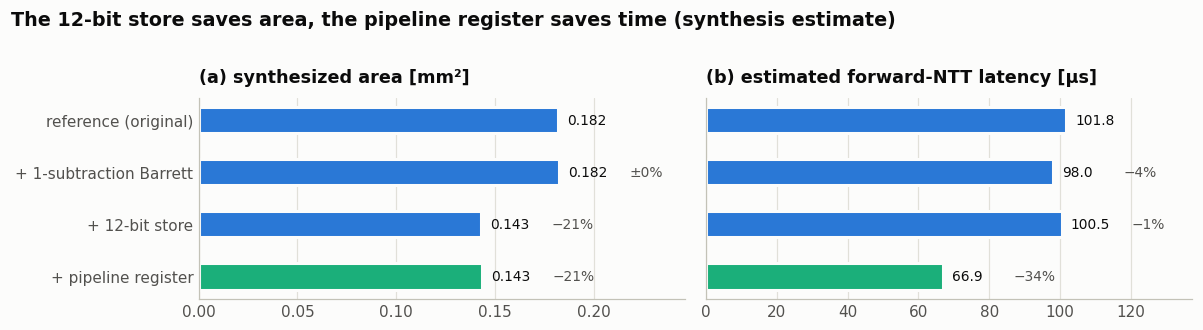

,simulation errors,latency variations,"cycles, forward NTT","cycles, inverse NTT",cell area [µm²],ABC delay estimate [ns],estimated forward latency [µs],area vs reference,delay vs reference,latency vs reference
NTT iteration: reference (single-port),0,0,6274,7554,181904.4608,16.2298,101.83,+0.0%,+0.0%,+0.0%
NTT iteration: 1-subtraction Barrett,0,0,6274,7554,182372.4096,15.6251,98.03,+0.3%,-3.7%,-3.7%
NTT iteration: 12-bit store,0,0,6274,7554,142878.2816,16.0129,100.47,-21.5%,-1.3%,-1.3%
NTT iteration: + pipeline,0,0,7170,8706,143372.5056,9.3280,66.88,-21.2%,-42.5%,-34.3%


In [21]:
if IN_COLAB:
    sh("bash scripts/run_sim_opt.sh")
    sh("bash scripts/synth_sweep.sh 'ntt_opt_ref ntt_opt_b1 ntt_opt_b1_w12 ntt_opt_pipe_w12' '10'")
opt = json.loads((ROOT/"results/synth/ntt_opt_summary.json").read_text())["variants"]
opt = pd.DataFrame(opt).T[["sim_errors", "timing_variations", "cycles_fwd", "cycles_inv",
                           "cell_area_um2", "abc_comb_delay_ns", "est_fwd_latency_us"]]
assert (opt.sim_errors == 0).all() and (opt.timing_variations == 0).all()
assert opt.loc["ntt_opt_ref", "cycles_fwd"] == sim.loc["ntt_sp", "cycles_measured"]
ref0 = opt.loc["ntt_opt_ref"]          # the reference variant (not the golden-model module ref)
opt["area_vs_ref"] = (opt.cell_area_um2 / ref0.cell_area_um2 - 1).map("{:+.1%}".format)
opt["delay_vs_ref"] = (opt.abc_comb_delay_ns / ref0.abc_comb_delay_ns - 1).map("{:+.1%}".format)
opt["latency_vs_ref"] = (opt.est_fwd_latency_us / ref0.est_fwd_latency_us - 1).map("{:+.1%}".format)

names = {"ntt_opt_ref": "reference (original)", "ntt_opt_b1": "+ 1-subtraction Barrett",
         "ntt_opt_b1_w12": "+ 12-bit store", "ntt_opt_pipe_w12": "+ pipeline register"}
order = list(names)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(11, 2.9), sharey=True)
for ax, col, unit, title in [(axes[0], "cell_area_um2", 1e6, "(a) synthesized area [mm²]"),
                             (axes[1], "est_fwd_latency_us", 1, "(b) estimated forward-NTT latency [µs]")]:
    vals = opt.loc[order, col].astype(float) / unit
    colours = [ps.SERIES[2] if v == "ntt_opt_pipe_w12" else ps.SERIES[0] for v in order]
    ax.barh(range(len(order)), vals, height=0.5, color=colours, edgecolor=ps.SURFACE, linewidth=2)
    for y, (v, x) in enumerate(zip(order, vals)):
        rel = x / (float(opt.loc["ntt_opt_ref", col]) / unit) - 1
        ax.annotate(f"{x:.3f}" if unit != 1 else f"{x:.1f}", (x, y), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color=ps.INK)
        if v != "ntt_opt_ref":
            txt = "±0%" if abs(rel) < 0.005 else f"{rel:+.0%}".replace("-", "−")
            ax.annotate(txt, (x, y), xytext=(46, 0), textcoords="offset points",
                        va="center", fontsize=9, color=ps.INK_2)
    ax.set_title(title); ax.grid(axis="y", visible=False); ax.set_xlim(0, vals.max() * 1.35)
axes[0].set_yticks(range(len(order)), [names[v] for v in order])
ps.finish(fig, title="The 12-bit store saves area, the pipeline register saves time (synthesis estimate)"); plt.show()
opt

Synthesis already sorts the three ideas. The single subtraction barely changes the delay, because the
long path is the pair of multiplications inside the reducer; the 12-bit store removes about a fifth of
the area, and the pipeline register nearly halves the combinational delay. The two variants that keep the
useful ideas, the 12-bit store without and with the pipeline register, were therefore routed like the
original blocks.

In [22]:
it = pnr[(pnr.clk_target_ns == 20) & pnr.variant.isin(["ntt_sp", "ntt_opt_b1_w12", "ntt_opt_pipe_w12"])]
it = it.set_index("variant").loc[["ntt_sp", "ntt_opt_b1_w12", "ntt_opt_pipe_w12"]]
base_it = it.loc["ntt_sp"]
tab = pd.DataFrame({
    "cell area [mm²]": it.cell_area_um2 / 1e6,
    "flip-flops": it.flops.astype(int),
    "fmax [MHz]": it.fmax_mhz,
    "cycles / forward NTT": it.cycles.astype(int),
    "latency [µs]": it.latency_us_at_fmax,
    "area × time [mm²·µs]": it.at_product,
    "DRC / antenna": it.drc_errors.astype(int).astype(str) + " / " + it.antenna_violating_nets.astype(int).astype(str),
}).rename(index={"ntt_sp": "original (single-port)", "ntt_opt_b1_w12": "+ 1-subtraction Barrett, 12-bit store",
                 "ntt_opt_pipe_w12": "+ pipeline register"})
assert (it.drc_errors == 0).all() and (it.antenna_violating_nets == 0).all()
assert it.loc["ntt_opt_pipe_w12", "latency_us_at_fmax"] < 0.75 * base_it.latency_us_at_fmax
assert it.loc["ntt_opt_b1_w12", "cell_area_um2"] < 0.8 * base_it.cell_area_um2
assert it.loc["ntt_opt_b1_w12", "fmax_mhz"] >= 50 > base_it.fmax_mhz
assert base_it.flops - it.loc["ntt_opt_b1_w12", "flops"] == 1024 + 4    # stated in the text below
tab.round(3)

design,cell area [mm²],flip-flops,fmax [MHz],cycles / forward NTT,latency [µs],area × time [mm²·µs],DRC / antenna
original (single-port),0.216,4267,49.751,6274,126.107,27.225,0 / 0
"+ 1-subtraction Barrett, 12-bit store",0.168,3239,52.274,6274,120.022,20.125,0 / 0
+ pipeline register,0.170,3265,82.508,7170,86.900,14.754,0 / 0


Place-and-route confirms the estimates. The 12-bit store removes 1,028 flip-flops and a fifth of the cell
area, and the lighter layout just closes the 50 MHz target that the original missed by 0.1 ns. The
pipeline register lifts the post-route frequency by about two thirds, which more than repays its extra
cycle: a forward transform finishes about 30 % sooner, and the area–time product falls by almost half.
Both iterations are free of DRC and antenna violations, and at 12 ns only the pipelined one closes timing
(Appendix B.6).

### Gate-level verification and measured-activity energy

A routed layout is only worth comparing if it still computes the right result, so
`scripts/run_gls_power.sh` simulates each routed netlist against the golden vectors, and the same
simulation yields the switching activity from which OpenSTA derives the energy. The functional half also
runs in Colab, from a committed netlist and the cell models in `third_party/`.

In [23]:
RUN_GLS = IN_COLAB   # re-simulate the routed netlist of the pipelined NTT (about 5-8 minutes)
if RUN_GLS:
    out = sh("bash scripts/run_gls.sh ntt_opt_pipe_w12_20ns")
    assert "errors=0" in out and "PASS" in out, "the routed netlist failed gate-level simulation"
gp = {}
for r in ["ntt_sp_20ns", "ntt_opt_b1_w12_20ns", "ntt_opt_pipe_w12_20ns"]:
    f = ROOT/"results/gls_power"/r/"summary.json"
    if f.exists():
        gp[r.rsplit("_", 1)[0]] = json.loads(f.read_text())
gp = pd.DataFrame(gp).T
assert gp.gls_pass.all(), "a routed netlist failed gate-level simulation"
gp["power [mW]"] = gp.total_power_w.astype(float) * 1e3
gp["energy / forward NTT [µJ]"] = gp.energy_per_forward_ntt_nj.astype(float) / 1e3
gp.index = [LABEL.get(v, v) for v in gp.index]
if len(gp) == 3:
    e = gp["energy / forward NTT [µJ]"].astype(float).values
    assert e[1] < e[2] < e[0], "energy ordering stated in the text no longer holds"
    assert 0.75 < e[1] / e[0] < 0.85, "the 12-bit store no longer saves about a fifth of the energy"
# power groups of the original block, as reported by OpenSTA
grp_pw = {g: float(s) / 100 for g, s in re.findall(r"^(Sequential|Clock)\s.*?([\d.]+)%\s*$",
          (ROOT/"results/gls_power/ntt_sp_20ns/power.log").read_text(), re.M)}
print("original single-port NTT, share of power:", {g: f"{s:.0%}" for g, s in grp_pw.items()})
assert 0.45 < grp_pw["Sequential"] < 0.55 and 0.35 < grp_pw["Clock"] < 0.45
gp["energy spread, 5 inputs [%]"] = [energy_spread(r) for r in ["ntt_sp_20ns", "ntt_opt_b1_w12_20ns", "ntt_opt_pipe_w12_20ns"]]
assert (gp["energy spread, 5 inputs [%]"] < 0.2).all(), "the energy now depends noticeably on the input"
gp[["gls_pass", "cycles_fwd", "power [mW]", "energy / forward NTT [µJ]", "energy spread, 5 inputs [%]"]].round(3)

original single-port NTT, share of power: {'Sequential': '50%', 'Clock': '40%'}


,gate-level simulation passed,"cycles, forward NTT",power [mW],energy / forward NTT [µJ],"energy spread, 5 inputs [%]"
"NTT, single-port store",True,6274,19.760,2.479,0.106
NTT iteration: 12-bit store,True,6274,15.627,1.961,0.122
NTT iteration: + pipeline,True,7170,15.668,2.247,0.103


The original engine and both iterations compute the transform bit-exactly at gate level, and further random inputs change the energy by less
than 0.2 %. Nine tenths of the original block's power goes into its flip-flops and the clock tree that
feeds them, so removing a quarter of the storage saves about a fifth of the energy. The pipeline register
gives part of that back through its extra cycle, a speed-versus-energy choice that these numbers make
explicit.

### The iteration with the chip's own store

To see whether the benefit carries over to the chip, the pipelined iteration was also routed with the
chip's macro as its store (`rtl/sram_macro_16x256_opt.sv`), like the macro-store point of Section 6.

In [24]:
om = pnr[pnr.variant.isin(["ntt_macro", "ntt_opt_pipe_macro"])].copy()
om["design"] = om.variant.map(LABEL) + ", " + om.clk_target_ns.map("{:g} ns".format)
om["total area [mm²]"] = [sum(total_area(f"{v}_{c:g}ns")) / 1e6 for v, c in zip(om.variant, om.clk_target_ns)]
om["area × time, total [mm²·µs]"] = om["total area [mm²]"] * om.latency_us_at_fmax
gpo = {f"{v}_{c:g}ns": ROOT/"results/gls_power"/f"{v}_{c:g}ns"/"summary.json" for v, c in zip(om.variant, om.clk_target_ns)}
gpo = {r: json.loads(f.read_text()) for r, f in gpo.items() if f.exists()}     # measured at 20 ns
om["energy / forward NTT [µJ]"] = [gpo[r]["energy_per_forward_ntt_nj"] / 1e3 if r in gpo else float("nan")
                                   for r in (f"{v}_{c:g}ns" for v, c in zip(om.variant, om.clk_target_ns))]
omt = om.set_index("design")[["cell_area_um2", "total area [mm²]", "flops", "fmax_mhz", "cycles",
                               "latency_us_at_fmax", "area × time, total [mm²·µs]", "energy / forward NTT [µJ]",
                               "drc_errors", "antenna_violating_nets"]]
display(omt.round(3).fillna("–"))       # energy: measured at 20 ns only
a0 = om[(om.variant == "ntt_macro") & (om.clk_target_ns == 20)].iloc[0]
a1 = om[(om.variant == "ntt_opt_pipe_macro") & (om.clk_target_ns == 20)].iloc[0]
a2 = om[(om.variant == "ntt_opt_pipe_macro") & (om.clk_target_ns == 12)].iloc[0]
print(f"pipelined iteration vs original, both with the macro at 20 ns: fmax {a0.fmax_mhz:.1f} -> {a1.fmax_mhz:.1f} MHz, "
      f"latency {a0.latency_us_at_fmax:.0f} -> {a1.latency_us_at_fmax:.0f} us, standard cells {a1.cell_area_um2 / a0.cell_area_um2 - 1:+.0%}")
# guards for the statements made in the text below
assert (om.drc_errors == 0).all() and (om.antenna_violating_nets == 0).all()
assert 1.6 < a1.fmax_mhz / a0.fmax_mhz < 1.8 and 0.8 < a1.cell_area_um2 / a0.cell_area_um2 < 0.9
assert a1.latency_us_at_fmax < 0.75 * a0.latency_us_at_fmax and a2.fmax_mhz > 1e3 / 12
ps_ = json.loads((ROOT/"results/asic/macro_pin_slew.json").read_text())["runs"]
assert ps_["ntt_opt_pipe_macro_20ns"]["pins_over_limit"] == 0 and slew_violations("ntt_opt_pipe_macro_20ns") == 0
assert ps_["ntt_opt_pipe_macro_12ns"]["pins_over_limit"] == 2 and ps_["ntt_opt_pipe_macro_12ns"]["max_ns"] <= 0.045
assert 86.5 < a2.fmax_mhz < 88
e_m0, e_m1 = (gpo[r]["energy_per_forward_ntt_nj"] for r in ("ntt_macro_20ns", "ntt_opt_pipe_macro_20ns"))
assert gpo["ntt_opt_pipe_macro_20ns"]["gls_pass"] and 1.08 < e_m1 / e_m0 < 1.2           # "about a seventh more"
assert abs(e_m1 / e_m0 - a1.cycles / a0.cycles) < 0.03                              # tracks the extra cycles

design,cell area [µm²],total area [mm²],flip-flops,reg→reg fmax [MHz],cycles,latency at fmax [µs],"area × time, total [mm²·µs]",energy / forward NTT [µJ],DRC errors,antenna violations
"NTT, OpenRAM macro store, 20 ns",38804.7,0.141,155,48.077,6274,130.499,18.465,0.504,0,0
"NTT iteration: + pipeline, OpenRAM macro store, 12 ns",33079.2,0.136,181,87.489,7170,81.953,11.127,–,0,0
"NTT iteration: + pipeline, OpenRAM macro store, 20 ns",32835.2,0.136,181,82.850,7170,86.542,11.728,0.574,0,0


pipelined iteration vs original, both with the macro at 20 ns: fmax 48.1 -> 82.9 MHz, latency 130 -> 87 us, standard cells -15%


The speed carries over. With the macro store the pipelined iteration clocks about 70 % faster than the
original engine with the same macro, finishes a forward transform in about two thirds of the time with a
sixth less standard-cell area, and closes timing near 87 MHz at a 12 ns target. The energy does not: the
macro keeps its width either way, so only the pipeline's extra cycle remains, and a transform costs about
a seventh more energy than with the original engine.

The layout of this design point, rendered at three scales from its released GDS, shows what the numbers
describe. The macro fills the lower half of the block (a), with the NTT logic above it; along the macro's
bottom edge sit the address-pin drivers that Appendix B.4 moved to the edge of the placement halo (b);
and at the scale of a few micrometres the logic resolves into individual standard cells, with their
diffusion, poly gates and local interconnect (c).

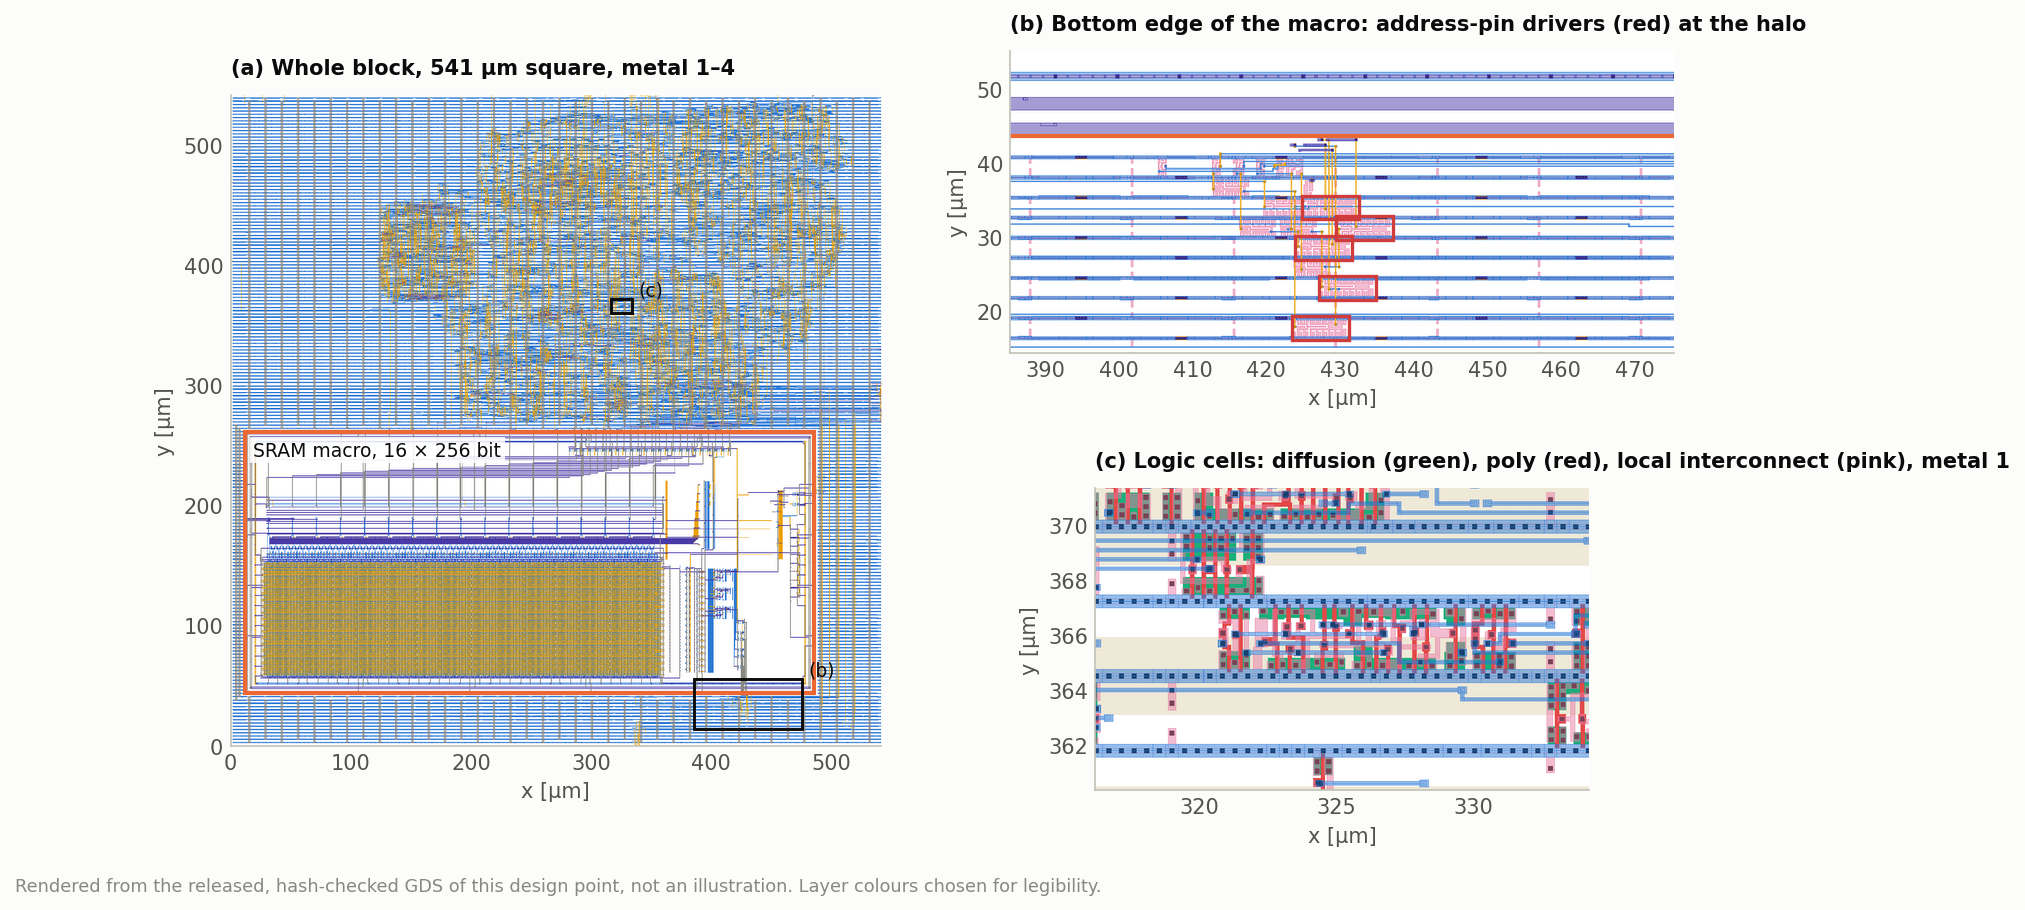

In [25]:
display(Image(str(ROOT/"figures/layout_zoom.png")))   # scripts/layout_zoom_figure.py, from the released GDS

### A second iteration: two coefficients in every SRAM word

The pipelined iteration makes the macro-store engine faster but not cheaper, and the measurements above
show why. Both engines access the single-port macro in every cycle of a transform, 6,274 times in the
original, and those accesses account for three quarters of the energy of a transform. Section 8 adds that
the single port alone lengthens a decapsulation by 14,336 cycles. Fewer accesses, rather than a faster
datapath, are therefore what the chip's store needs.

Two properties of ML-KEM make fewer accesses possible without a second port. Its NTT stops at butterflies
of distance two, so the lowest bit of a coefficient index never selects a partner, and the first
iteration showed twelve bits per coefficient to be enough. A word of the 24 × 128 OpenRAM macro, one of
the chip's own macro types, can therefore hold the pair $a_{2w}$ and $a_{2w+1}$, and in every layer the
partner of a coefficient lies in the same half of another word (a). One access thus moves two
coefficients that never meet in a butterfly. On top of the pairing the engine fuses layers: a pass reads
a group of up to eight words into one of two register banks, applies two or three consecutive layers
there, and writes the group back while the other bank fills. Three passes cover the seven layers (b–d),
so a transform needs 768 accesses. A single pipelined butterfly unit serves both directions, and the
inverse folds its final scaling by $128^{-1}$ into its last layer.

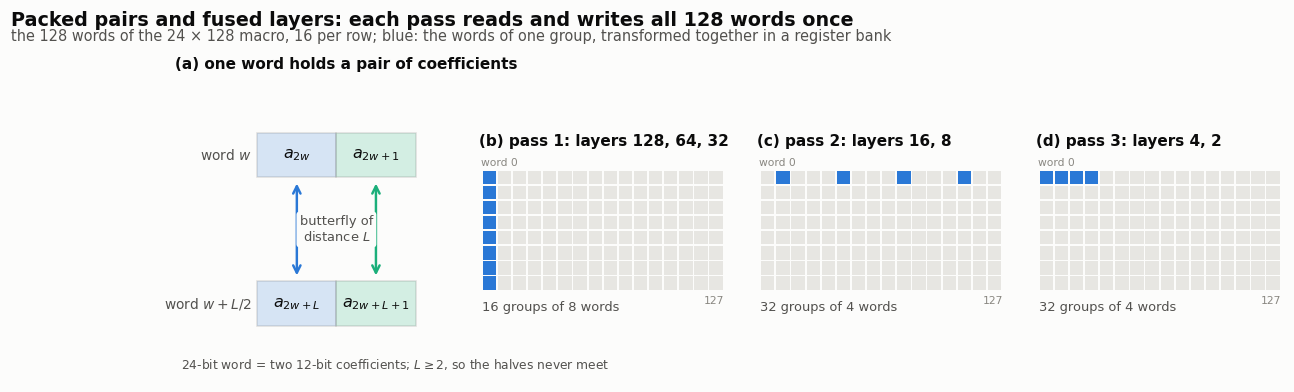

In [26]:
from matplotlib.patches import Rectangle, FancyArrowPatch
BLUE, LIGHT = ps.SERIES[0], "#e7e6e2"
fig = plt.figure(figsize=(13, 3.7))
gs_ = fig.add_gridspec(1, 4, width_ratios=[1.1, 1, 1, 1], wspace=0.12)
ax = fig.add_subplot(gs_[0]); ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis("off")
ax.set_title("(a) one word holds a pair of coefficients", loc="left", fontsize=10)
for y, lab, lo, hi in [(7.6, "word $w$", "$a_{2w}$", "$a_{2w+1}$"), (2.6, "word $w + L/2$", "$a_{2w+L}$", "$a_{2w+L+1}$")]:
    for k, (txt, x) in enumerate(((lo, 3.0), (hi, 5.9))):
        ax.add_patch(Rectangle((x, y - 0.75), 2.9, 1.5, facecolor=BLUE if k == 0 else ps.SERIES[2], alpha=0.18,
                               edgecolor=ps.INK_2, linewidth=1))
        ax.text(x + 1.45, y, txt, ha="center", va="center", fontsize=10.5, color=ps.INK)
    ax.text(2.8, y, lab, ha="right", va="center", fontsize=9, color=ps.INK_2)
for x, c in ((4.45, BLUE), (7.35, ps.SERIES[2])):
    ax.add_patch(FancyArrowPatch((x, 6.75), (x, 3.45), arrowstyle="<->", mutation_scale=12, color=c, linewidth=1.6))
ax.text(5.9, 5.1, "butterfly of\ndistance $L$", ha="center", va="center", fontsize=8.5, color=ps.INK_2,
        bbox=dict(boxstyle="round,pad=0.25", facecolor=ps.SURFACE, edgecolor="none"))
ax.text(0.2, 0.4, "24-bit word = two 12-bit coefficients; $L \\geq 2$, so the halves never meet",
        fontsize=8, color=ps.INK_2)
PASSES = [("(b) pass 1: layers 128, 64, 32", lambda w: w % 16, 0, "16 groups of 8 words"),
          ("(c) pass 2: layers 16, 8", lambda w: (w // 16) * 4 + w % 4, 1, "32 groups of 4 words"),
          ("(d) pass 3: layers 4, 2", lambda w: w // 4, 0, "32 groups of 4 words")]
for i, (title, group, w0, note) in enumerate(PASSES):
    ax = fig.add_subplot(gs_[i + 1])
    ax.set_xlim(-0.2, 16.2); ax.set_ylim(8.9, -0.6); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, loc="left", fontsize=10)
    for w in range(128):
        r, c = divmod(w, 16)
        ax.add_patch(Rectangle((c + 0.06, r + 0.06), 0.88, 0.88, edgecolor="none",
                               facecolor=BLUE if group(w) == group(w0) else LIGHT))
    ax.text(0, 8.65, note, fontsize=8.5, color=ps.INK_2, va="top")
    ax.text(-0.05, -0.15, "word 0", fontsize=7, color=ps.MUTED, va="bottom")
    ax.text(16.05, 8.35, "127", fontsize=7, color=ps.MUTED, ha="right", va="top")
    # each pass's groups partition the 128 words: every word is read and written once per pass
    sizes = pd.Series([group(w) for w in range(128)]).value_counts()
    assert sizes.nunique() == 1 and sizes.iloc[0] * len(sizes) == 128
import warnings
with warnings.catch_warnings():        # equal-aspect panels: tight_layout cannot fit them exactly
    warnings.simplefilter("ignore", UserWarning)
    ps.finish(fig, title="Packed pairs and fused layers: each pass reads and writes all 128 words once",
              subtitle="the 128 words of the 24 × 128 macro, 16 per row; blue: the words of one group, "
                       "transformed together in a register bank")
fig.subplots_adjust(top=0.84)
ps.save_pdf(fig, "packed_ntt_schedule"); plt.show()

Neither idea is new on its own. Kyber accelerators on FPGAs store a pair of coefficients in each memory
word [13], and software for microcontrollers merges NTT layers to save loads and stores [15]. What this
section adds is their combination for one single-port, compiler-generated SRAM with a single multiplier,
chosen because of the measurements above and measured on the routed layout.
`rtl/kyber_ntt_engine_packed.sv` keeps the ports of the original engine, `golden/packed_ntt_model.py`
reproduces its schedule cycle by cycle, and the testbenches check it like every other engine.

In [27]:
if IN_COLAB:
    sh("bash scripts/run_sim_packed.sh")
PK = ["ntt_macro", "ntt_opt_pipe_macro", "ntt_packed"]
pk = pnr[(pnr.clk_target_ns == 20) & pnr.variant.isin(PK)].set_index("variant").loc[PK]
gpk = {v: json.loads((ROOT/"results/gls_power"/f"{v}_20ns"/"summary.json").read_text()) for v in PK}
acc_ = {v: sum(gpk[v]["macro_accesses"][k] for k in ("writes", "reads_new_address", "reads_same_address")) for v in PK}
ar_ = {v: total_area(f"{v}_20ns") for v in PK}
feol_ = json.loads((ROOT/"results/asic/feol_blocks.json").read_text())["layouts"]
ptab = pd.DataFrame({
    "standard cells [mm²]": [ar_[v][0] / 1e6 for v in PK],
    "SRAM macro [mm²]": [ar_[v][1] / 1e6 for v in PK],
    "fmax [MHz]": pk.fmax_mhz.values,
    "cycles, forward / inverse NTT": [f"{int(a):,} / {int(b):,}" for a, b in zip(pk.cycles, pk.cycles_inv)],
    "forward-NTT latency [µs]": pk.latency_us_at_fmax.values,
    "macro accesses per forward NTT": [acc_[v] for v in PK],
    "energy per forward NTT [µJ]": [gpk[v]["energy_per_forward_ntt_nj"] / 1e3 for v in PK],
    "DRC / antenna / FEOL": [f"{int(pk.drc_errors[v])} / {int(pk.antenna_violating_nets[v])} / "
                             f"{feol_[v + '_20ns']['feol_markers']}" for v in PK],
}, index=[LABEL[v] for v in PK])
ptab.insert(2, "total area [mm²]", ptab["standard cells [mm²]"] + ptab["SRAM macro [mm²]"])
ptab["area × time, total [mm²·µs]"] = ptab["total area [mm²]"] * ptab["forward-NTT latency [µs]"]
sp_log = {x: (ROOT/"results/sim_packed"/f"packed_x{x}.log").read_text() for x in (0, 1)}
display(ptab.round(3))
# guards for the statements made in the text below
o_, n_ = ptab.iloc[0], ptab.iloc[2]
assert all("errors=0" in l and "timing_variations=0" in l for l in sp_log.values())
assert re.search(r"cycles_fwd=988 cycles_inv=1116", sp_log[1]) and int(pk.cycles["ntt_packed"]) == 988
assert gpk["ntt_packed"]["gls_pass"] and 768 <= acc_["ntt_packed"] < 800 and acc_["ntt_macro"] == 6274
assert gpk["ntt_packed"]["logic_energy_per_forward_ntt_nj"] > gpk["ntt_packed"]["macro_energy_nj"]   # "most of what remains"
assert all(0.73 < gpk[v]["macro_energy_nj"] / gpk[v]["energy_per_forward_ntt_nj"] < 0.75 for v in PK[:2])
assert ptab["DRC / antenna / FEOL"].eq("0 / 0 / 0").all() and slew_violations("ntt_packed_20ns", cells_only=True) == 0
assert o_["forward-NTT latency [µs]"] / n_["forward-NTT latency [µs]"] > 8
assert ptab.iloc[1]["forward-NTT latency [µs]"] / n_["forward-NTT latency [µs]"] > 5
assert 0.28 < n_["energy per forward NTT [µJ]"] / o_["energy per forward NTT [µJ]"] < 0.38      # "about a third"
assert 1.35 < n_["total area [mm²]"] / o_["total area [mm²]"] < 1.55
assert o_["area × time, total [mm²·µs]"] / n_["area × time, total [mm²·µs]"] > 5

,standard cells [mm²],SRAM macro [mm²],total area [mm²],fmax [MHz],"cycles, forward / inverse NTT",forward-NTT latency [µs],macro accesses per forward NTT,energy per forward NTT [µJ],DRC / antenna / FEOL,"area × time, total [mm²·µs]"
"NTT, OpenRAM macro store",0.039,0.103,0.141,48.077,"6,274 / 7,554",130.499,6274,0.504,0 / 0 / 0,18.465
"NTT iteration: + pipeline, OpenRAM macro store",0.033,0.103,0.136,82.850,"7,170 / 8,706",86.542,7170,0.574,0 / 0 / 0,11.728
"NTT iteration: packed pairs, 24 × 128 macro",0.076,0.132,0.208,68.399,"988 / 1,116",14.445,769,0.161,0 / 0 / 0,2.999


The pairing pays off in every figure of merit except area. A forward transform takes 988 instead of 6,274
cycles and finishes nine times sooner than with the original macro-store engine and six times sooner than
with the pipelined iteration. It costs about a third of the energy, because the macro is accessed fewer
than 800 instead of 6,274 times and is deselected in the remaining cycles; most of what remains is the
clocking of the two register banks. The price is area: the 24 × 128 macro
is a quarter larger than the 16 × 256 one, and the two register banks double the standard-cell area, so
the block grows by almost half, while its area–time product falls sixfold. The layout is free of DRC,
antenna and FEOL violations, and the routed netlist computes bit-exactly with a latency that does not
depend on the data. Section 8 measures what the engine does for a whole decapsulation, and Section 10
repeats the leakage assessment for it.

The figure below gathers the effect of the iterations. For each kind of store it sets the original
engine (grey) beside its iterations on the four figures of merit, and the percentages give the change
against the original with the same store. Every iteration is faster. The energy falls with the narrower
flip-flop store and, with the macro, only once the packed engine stops accessing it in every cycle.

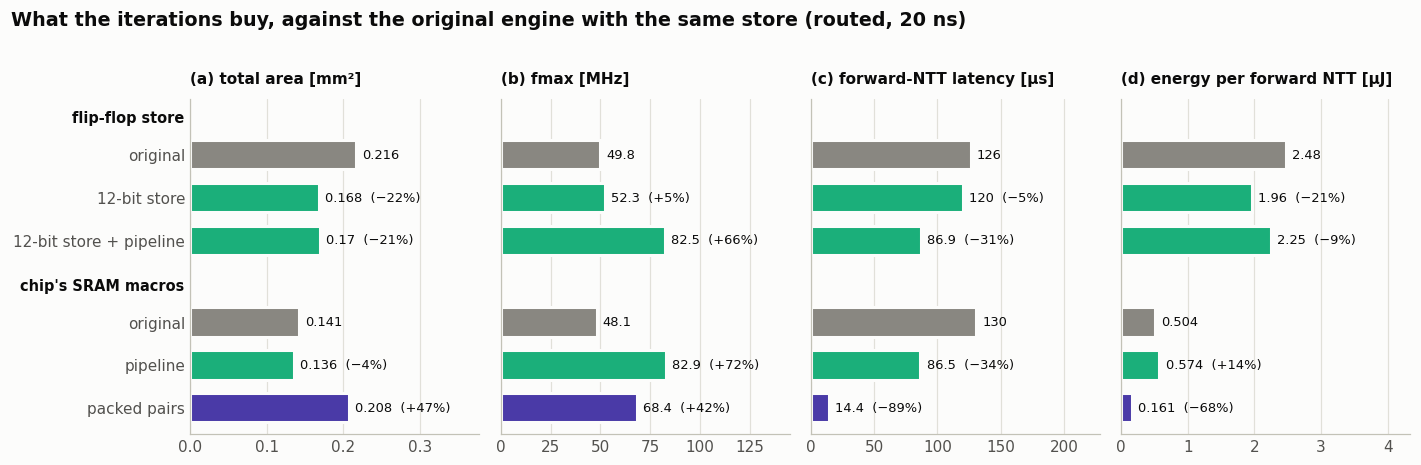

In [28]:
GROUPS = [("flip-flop store", ["ntt_sp", "ntt_opt_b1_w12", "ntt_opt_pipe_w12"]),
          ("chip's SRAM macros", ["ntt_macro", "ntt_opt_pipe_macro", "ntt_packed"])]
NAMES = {"ntt_sp": "original", "ntt_opt_b1_w12": "12-bit store", "ntt_opt_pipe_w12": "12-bit store + pipeline",
         "ntt_macro": "original", "ntt_opt_pipe_macro": "pipeline", "ntt_packed": "packed pairs"}
P20 = pnr[pnr.clk_target_ns == 20].set_index("variant")
def _energy_uj(v):
    return json.loads((ROOT/"results/gls_power"/f"{v}_20ns"/"summary.json").read_text())["energy_per_forward_ntt_nj"] / 1e3
METRICS = [("total area [mm²]", lambda v: sum(total_area(f"{v}_20ns")) / 1e6),
           ("fmax [MHz]", lambda v: P20.fmax_mhz[v]),
           ("forward-NTT latency [µs]", lambda v: P20.latency_us_at_fmax[v]),
           ("energy per forward NTT [µJ]", _energy_uj)]
rows = [(g, v, vs[0]) for g, vs in GROUPS for v in vs]
ypos = [0, 1, 2, 3.9, 4.9, 5.9]
fig, axes = plt.subplots(1, 4, figsize=(13, 4.1), sharey=True)
for ax, tag, (name, f) in zip(axes, "abcd", METRICS):
    vals = [f(v) for _, v, _ in rows]
    for y, (g, v, ref_v), x in zip(ypos, rows, vals):
        ax.barh(y, x, height=0.68, **ps.bar_kw(ps.MUTED if v == ref_v else COLOR[v]))
        txt = f"{x:.3g}" + ("" if v == ref_v else f"  ({x / f(ref_v) - 1:+.0%})".replace("-", "−"))
        ax.annotate(txt, (x, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8.5, color=ps.INK)
    ax.set_title(f"({tag}) {name}", loc="left", fontsize=10)
    ax.set_xlim(0, max(vals) * 1.75); ax.grid(axis="y", visible=False)
axes[0].set_yticks(ypos, [NAMES[v] for _, v, _ in rows]); axes[0].set_ylim(6.5, -1.3)
for g, y in ((GROUPS[0][0], -0.85), (GROUPS[1][0], 3.05)):
    axes[0].annotate(g, (0, y), xycoords=("axes fraction", "data"), xytext=(-4, 0), textcoords="offset points",
                     ha="right", va="center", fontsize=9.5, fontweight="bold", color=ps.INK)
ps.finish(fig, title="What the iterations buy, against the original engine with the same store (routed, 20 ns)")
ps.save_pdf(fig, "redesign_effect"); plt.show()

### All seven NTT layouts side by side

Sections 6 and 7 produced seven NTT layouts at 20 ns: two flip-flop stores, two flip-flop iterations, the
original and pipelined engine with the chip's 16 × 256 macro, and the packed engine with a 24 × 128 one. The figure plots total area against energy per
transform, and in Colab or Jupyter its two menus select any other pair of metrics. Whatever the pair, no
layout wins on every axis, which is why this notebook reports its decisions as trade-offs.

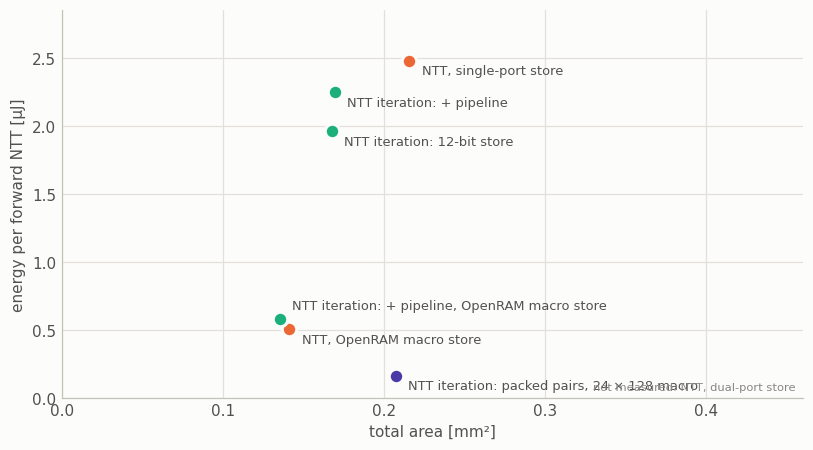

interactive(children=(Dropdown(description='x axis', index=1, options=('total area [mm²]', 'fmax [MHz]', 'late…

In [29]:
nt = pnr[(pnr.clk_target_ns == 20) & pnr.variant.str.startswith("ntt") & ~pnr.variant.str.contains("hm")].set_index("variant")
def _energy(v):
    f = ROOT/"results/gls_power"/f"{v}_20ns"/"summary.json"
    return json.loads(f.read_text())["energy_per_forward_ntt_nj"] / 1e3 if f.exists() else np.nan
explore = pd.DataFrame({
    "total area [mm²]": [sum(total_area(f"{v}_20ns")) / 1e6 for v in nt.index],
    "fmax [MHz]": nt.fmax_mhz.values,
    "latency of a forward NTT [µs]": nt.latency_us_at_fmax.values,
    "energy per forward NTT [µJ]": [_energy(v) for v in nt.index],
    "flip-flops": nt.flops.astype(int).values,
}, index=nt.index)
explore["area × time [mm²·µs]"] = explore["total area [mm²]"] * explore["latency of a forward NTT [µs]"]

def show_points(x="total area [mm²]", y="energy per forward NTT [µJ]"):
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    pts = explore.dropna(subset=[x, y]).sort_values(y)
    for k, (v, r) in enumerate(pts.iterrows()):
        ax.scatter(r[x], r[y], **ps.marker_kw(COLOR[v]))
        close = k > 0 and abs(r[y] - pts[y].iloc[k - 1]) < 0.06 * pts[y].max()   # neighbours: label above
        ax.annotate(LABEL[v], (r[x], r[y]), xytext=(8, 7 if close else -9), textcoords="offset points",
                    fontsize=8.5, color=ps.INK_2)
    ax.set_xlim(0, explore[x].max() * 1.6); ax.set_ylim(0, explore[y].max() * 1.15)
    ax.set_xlabel(x); ax.set_ylabel(y)
    missing = explore.index[explore[[x, y]].isna().any(axis=1)]
    if len(missing):
        ax.text(0.99, 0.02, "not measured: " + ", ".join(LABEL[v] for v in missing), transform=ax.transAxes,
                ha="right", fontsize=7.5, color=ps.MUTED)
    ps.finish(fig)
    if (x, y) == ("total area [mm²]", "energy per forward NTT [µJ]"):
        ps.save_pdf(fig, "ntt_layouts_area_energy")
    plt.show()

show_points()                          # the default pair, stored with the notebook so that it shows everywhere
try:                                   # in Colab or Jupyter: menus for any other pair
    import ipywidgets as widgets
    widgets.interact(show_points,
                     x=widgets.Dropdown(options=list(explore), value="fmax [MHz]", description="x axis"),
                     y=widgets.Dropdown(options=list(explore), value="area × time [mm²·µs]", description="y axis"))
except ImportError:
    pass
# guard for the statement in the text above: no layout is best on every figure of merit
better_high = {"fmax [MHz]"}
best = {m: (explore[m].idxmax() if m in better_high else explore[m].idxmin()) for m in explore}
assert len(set(best.values())) > 1, best

## 8. The full chip: where decapsulation spends its time and energy

On the chip, the blocks above share one digital core with the SPI front end, the HSM policy logic,
SHA-256/HMAC, AES-256, the PUF services and 18 OpenRAM [9] SRAM macros of eight distinct types, and the
build uses the **row-serialized Keccak** and the **single-port NTT store**. The routed core passes
layout-versus-schematic (LVS), with the SRAMs checked separately, and the complete SKY130 design-rule
(DRC) deck once sub-minimum implant gaps inside the OpenRAM macros are closed (Appendix C). This section
asks what the chip spends its area, time and energy on, and how much of that the two decisions explain.

die area [mm²]                                                                      11.2314
std cells                                                                            320615
std-cell area [mm²]                                                                 2.03292
SRAM macros                                                                              18
SRAM area [mm²]                                                                     2.16121
flip-flops                                                                            28460
clock target [ns]                                                                      40.0
setup WNS [ns]                                                                      4.89328
hold WNS [ns]                                                                      0.119253
post-route fmax [MHz]                                                               37.8185
LVS (primary / repeat)                    Circuits match uniquely / Circuits mat

claim boundary: pre-silicon top-level integration LVS with 8 SRAM abstractions and independent transistor-level LVS for each SRAM


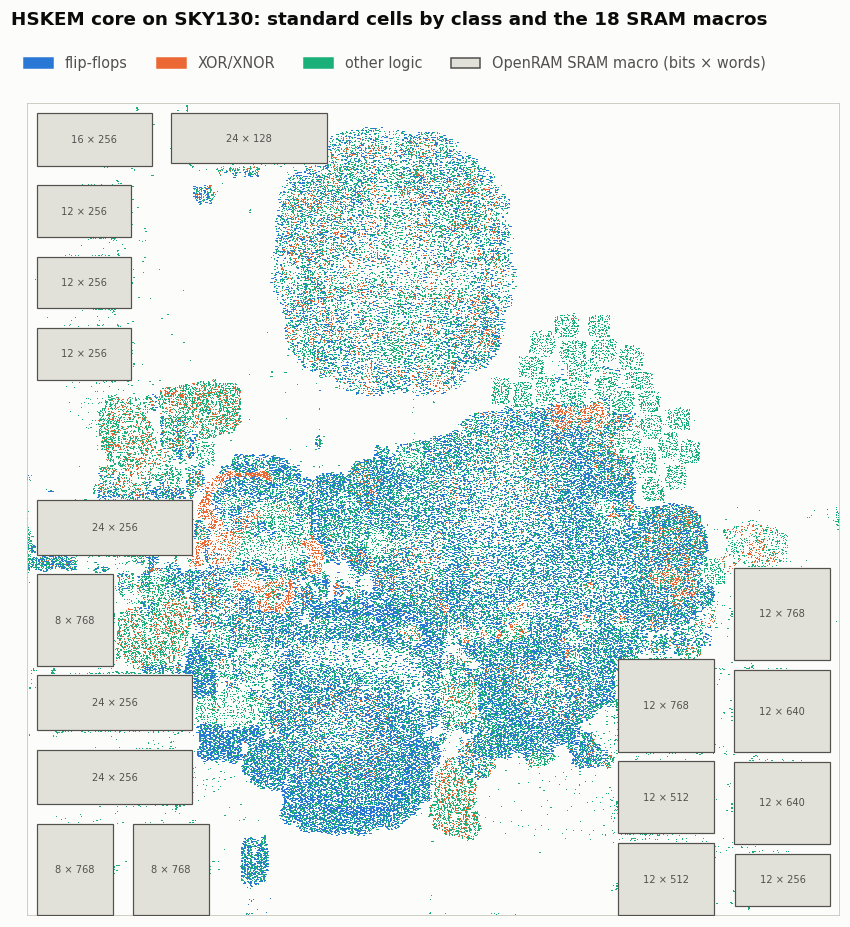

In [30]:
fc = json.loads((ROOT/"results/fullchip/summary.json").read_text())
feol = json.loads((ROOT/"results/fullchip/feol_drc.json").read_text())
m, s = fc["orfs_metrics"], fc["signoff"]
display(pd.Series({
    "die area [mm²]": m["finish__design__die__area"]/1e6,
    "std cells": m["finish__design__instance__count__stdcell"],
    "std-cell area [mm²]": m["finish__design__instance__area__stdcell"]/1e6,
    "SRAM macros": m["finish__design__instance__count__macros"],
    "SRAM area [mm²]": m["finish__design__instance__area__macros"]/1e6,
    "flip-flops": m["finish__design__instance__count__class:sequential_cell"],
    "clock target [ns]": fc["clock_target_ns"],
    "setup WNS [ns]": m["finish__timing__setup__ws"], "hold WNS [ns]": m["finish__timing__hold__ws"],
    "post-route fmax [MHz]": m["finish__timing__fmax"]/1e6,
    "LVS (primary / repeat)": f'{s["primary_compare"]} / {s["repeat_compare"]}',
    "LVS negative control detected": s["negative_control_detected"],
    "DRC markers, BEOL + off-grid rules": s["drc_markers"],
    "DRC markers, FEOL rules (Appendix C.3)": feol["after_implant_fix"]["markers_total"],
}, name="HSKEM core"))
print("claim boundary:", s["claim_boundary"])
# the abstract quotes these two figures
assert m["finish__design__instance__count__stdcell"] > 320_000 and m["finish__design__instance__count__macros"] == 18
import placement_map as pm
from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(8, 8.4))
pm.draw_chip(ax)
ax.set_position([0.02, 0.01, 0.96, 0.88])          # square die directly under the legend
fig.legend([Patch(color=c) for _, c in pm.CLASSES] + [Patch(facecolor="#e1e0d9", edgecolor=ps.INK_2)],
           [n for n, _ in pm.CLASSES] + ["OpenRAM SRAM macro (bits × words)"], ncols=4, loc="upper left",
           bbox_to_anchor=(0.02, 0.955), frameon=False)
fig.suptitle("HSKEM core on SKY130: standard cells by class and the 18 SRAM macros",
             x=0.02, ha="left", y=0.99, fontsize=12, fontweight="bold")
plt.show()

### Where the chip's registers and macros sit

Every flip-flop and SRAM macro of the flattened layout keeps its hierarchical name, which
`scripts/fullchip_blocks.py` uses to attribute them to the HSKEM blocks; combinational logic cannot be
attributed this way.

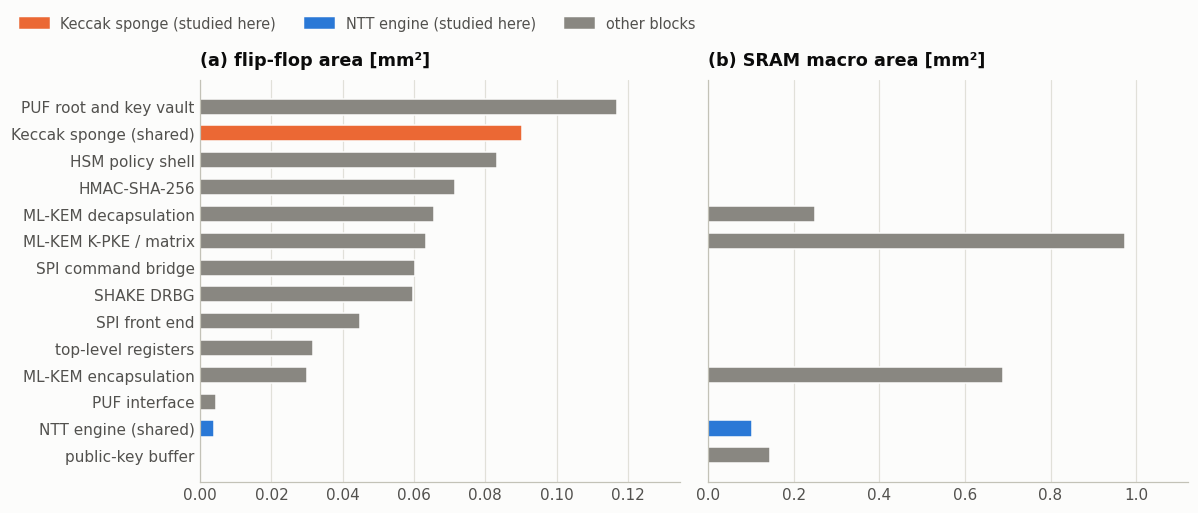

NTT engine: 154 flip-flops (0.5% of the flip-flop area) and one 4096-bit SRAM macro; Keccak sponge: 3606 flip-flops (12.4%) and no SRAM


In [31]:
blk = pd.read_csv(ROOT/"results/fullchip/blocks.csv").set_index("block")
# the attribution must account for the whole chip
assert abs(blk.flops.sum() - m["finish__design__instance__count__class:sequential_cell"]) <= 5
assert abs(blk.sram_area_um2.sum() - m["finish__design__instance__area__macros"]) / m["finish__design__instance__area__macros"] < 0.001
BLOCK = {"g_qualification_puf_vault": "PUF root and key vault", "u_shared_mlkem_sponge": "Keccak sponge (shared)",
         "u_hsm_shell": "HSM policy shell", "u_security_hmac": "HMAC-SHA-256", "u_mlkem512_decaps_partial": "ML-KEM decapsulation",
         "u_c2_shake_drbg": "SHAKE DRBG", "u_mlkem512_kpke_partial": "ML-KEM K-PKE / matrix", "u_bridge": "SPI command bridge",
         "u_spi": "SPI front end", "(top-level registers)": "top-level registers", "u_mlkem512_encaps_partial": "ML-KEM encapsulation",
         "u_puf": "PUF interface", "u_shared_ntt": "NTT engine (shared)", "u_c3_pk_pair_sram": "public-key buffer"}
blk.index = [BLOCK.get(b, b) for b in blk.index]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
rows_ = blk.sort_values("flop_area_um2").index
hl = {"Keccak sponge (shared)": ps.SERIES[1], "NTT engine (shared)": ps.SERIES[0]}
for ax, col, title in [(axes[0], "flop_area_um2", "(a) flip-flop area [mm²]"), (axes[1], "sram_area_um2", "(b) SRAM macro area [mm²]")]:
    vals = blk.loc[rows_, col] / 1e6
    ax.barh(range(len(rows_)), vals, height=0.6, color=[hl.get(r, ps.MUTED) for r in rows_], edgecolor=ps.SURFACE)
    ax.set_title(title); ax.grid(axis="y", visible=False); ax.set_xlim(0, vals.max() * 1.15)
axes[0].set_yticks(range(len(rows_)), rows_)
fig.legend([Patch(color=c) for c in hl.values()] + [Patch(color=ps.MUTED)],
           ["Keccak sponge (studied here)", "NTT engine (studied here)", "other blocks"], ncols=3,
           loc="lower left", bbox_to_anchor=(0.01, 0.98), frameon=False)
ps.finish(fig); plt.show()
tot_ff = blk.flop_area_um2.sum()
print(f"NTT engine: {blk.loc['NTT engine (shared)', 'flops']:.0f} flip-flops "
      f"({blk.loc['NTT engine (shared)', 'flop_area_um2'] / tot_ff:.1%} of the flip-flop area) and one "
      f"{blk.loc['NTT engine (shared)', 'sram_bits']:.0f}-bit SRAM macro; "
      f"Keccak sponge: {blk.loc['Keccak sponge (shared)', 'flops']:.0f} flip-flops "
      f"({blk.loc['Keccak sponge (shared)', 'flop_area_um2'] / tot_ff:.1%}) and no SRAM")
assert blk.loc["NTT engine (shared)", "flop_area_um2"] / tot_ff < 0.01
assert blk.flops.rank(ascending=False)["Keccak sponge (shared)"] == 2

The NTT keeps its coefficients in one of the eighteen macros and has few registers of its own, whereas
the Keccak sponge, which holds its 1600-bit states in flip-flops, is the second-largest register block of
the chip; in time, as the profile below shows, the order is reversed.

### What the two ASIC decisions cost at system level

A block that is nine times slower matters little if the system rarely waits for it. The full-system
testbench drives the co-processor through its SPI interface exactly as the ESP32 host does and measures
the busy interval of a decapsulation, which the board's 16-bit cycle counter (Section 9) cannot report.
`scripts/run_system_sim.sh` runs it in four configurations: the FPGA one, each ASIC decision on its own,
and both together; the FPGA result reproduces an earlier ModelSim run exactly.

,decapsulation cycles,Keccak permutations,shared-secret fingerprints,testbench result,decapsulation at 50 MHz [ms],change vs FPGA configuration
FPGA configuration,81457,26,['27033e5e'],ALL PASS (baseline + D1/D2 internal restore + HSM-4E auth + HSM-4F legacy lock),1.6291,0
row-serialized Keccak only,85201,26,['27033e5e'],FAIL (7 errors),1.7040,3744
single-port store only,95793,26,['27033e5e'],ALL PASS (baseline + D1/D2 internal restore + HSM-4E auth + HSM-4F legacy lock),1.9159,14336
ASIC configuration (both choices),99537,26,['27033e5e'],ALL PASS (baseline + D1/D2 internal restore + HSM-4E auth + HSM-4F legacy lock),1.9907,18080


published RTL copy (hskem_rtl/): ALL PASS, decapsulation 81,457 cycles
single-port store: +14336 cycles = 8 transforms x 896 butterflies x 2
row-serialized Keccak: +3744 cycles = 26 permutations x 144
the two effects add exactly: True
note on keccak_only: keccak_only is not a configuration the testbench's hard-coded cycle oracle supports: its 7 FAIL lines are cycle-count equality checks only; every digest and permutation count matches, and each measured count equals the FPGA oracle plus 144 cycles per Keccak permutation (KeyGen 35171+36*144=40355, Encaps 55692+20*144=58572, Encrypt 50449+7*144=51457).


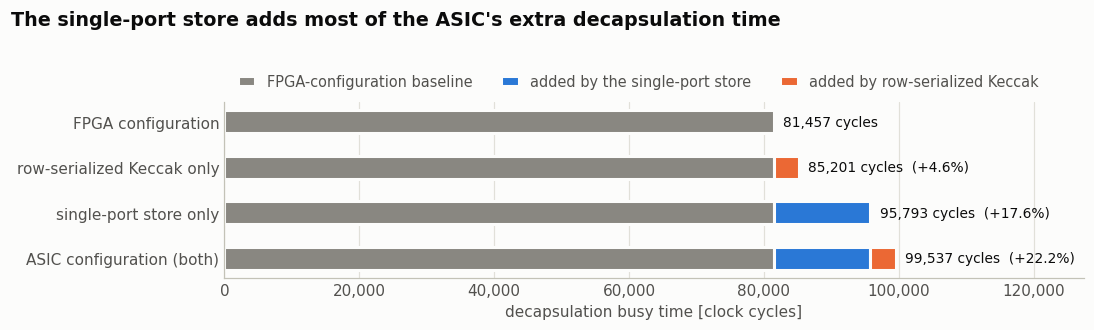

In [32]:
ss_ = json.loads((ROOT/"results/system_sim/summary.json").read_text())
cfg = pd.DataFrame(ss_["configs"]).T[["decaps_cycles", "decaps_keccak_permutations", "shared_secret_fingerprints", "tb_result"]]
cfg["decaps_ms_at_50MHz"] = cfg.decaps_cycles.astype(float) / 50e6 * 1e3
cfg["delta_vs_fpga"] = cfg.decaps_cycles.astype(int) - int(cfg.loc["fpga", "decaps_cycles"])
display(cfg)
dec = ss_["decomposition"]
assert dec["additive"] and dec["keccak_serial_delta"] == dec["keccak_serial_model"] \
       and dec["single_port_sram_delta"] == dec["single_port_sram_model"]
assert cfg.shared_secret_fingerprints.map(tuple).nunique() == 1, "configurations disagree on the shared key"
pc = ss_["published_copy_check"]
assert pc["tb_result"].startswith("ALL PASS") and pc["decaps_cycles"] == int(cfg.loc["fpga", "decaps_cycles"])
print(f"published RTL copy (hskem_rtl/): {pc['tb_result'][:8]}, decapsulation {pc['decaps_cycles']:,} cycles")
print(f"single-port store: +{dec['single_port_sram_delta']} cycles = 8 transforms x 896 butterflies x 2")
print(f"row-serialized Keccak: +{dec['keccak_serial_delta']} cycles = 26 permutations x 144")
print("the two effects add exactly:", dec["additive"])
print("note on keccak_only:", ss_["note_keccak_only"])

base = int(cfg.loc["fpga", "decaps_cycles"])
rows = [("FPGA configuration", 0, 0), ("row-serialized Keccak only", 0, dec["keccak_serial_delta"]),
        ("single-port store only", dec["single_port_sram_delta"], 0),
        ("ASIC configuration (both)", dec["single_port_sram_delta"], dec["keccak_serial_delta"])][::-1]
fig, ax = plt.subplots(figsize=(10, 2.9))
for y, (name, ntt_extra, kec_extra) in enumerate(rows):
    ax.barh(y, base, height=0.5, label="FPGA-configuration baseline" if y == 0 else None, **ps.bar_kw(ps.MUTED))
    if ntt_extra:
        ax.barh(y, ntt_extra, left=base, height=0.5, label="added by the single-port store" if y == 0 else None, **ps.bar_kw(ps.SERIES[0]))
    if kec_extra:
        ax.barh(y, kec_extra, left=base + ntt_extra, height=0.5, label="added by row-serialized Keccak" if y == 0 else None, **ps.bar_kw(ps.SERIES[1]))
    total = base + ntt_extra + kec_extra
    ax.annotate(f"{total:,} cycles" + (f"  (+{total / base - 1:.1%})" if total > base else ""),
                (total, y), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=ps.INK)
ax.set_yticks(range(len(rows)), [r[0] for r in rows]); ax.grid(axis="y", visible=False)
ax.set_xlim(0, (base + dec["both_delta"]) * 1.28); ax.set_xlabel("decapsulation busy time [clock cycles]")
ps.thousands(ax)
ax.legend(ncols=3, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1.2)
ps.finish(fig, title="The single-port store adds most of the ASIC's extra decapsulation time"); plt.show()

Both decisions lengthen a decapsulation, and their effects add exactly, as the cycle model predicts. The
single-port store accounts for most of the difference between the FPGA and the ASIC configuration, while
the row-serialized Keccak adds only a few percent. Valid and implicitly rejected ciphertexts take the same
number of cycles in every configuration, so the decapsulation time does not reveal which one arrived.

### Where decapsulation spends its cycles

A small monitor, `tb/decaps_profiler.sv`, measures the split directly. It reads signals through
hierarchical references only, leaving the RTL and the testbench untouched, and counts cycle by cycle
whether the NTT engine, the Keccak sponge and the permutation inside it are busy.

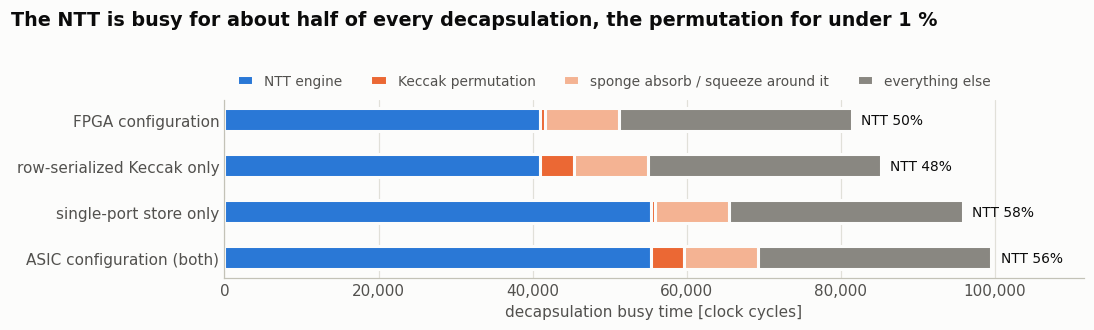

,NTT engine,Keccak permutation,sponge absorb / squeeze around it,everything else
FPGA configuration,0.503,0.008,0.118,0.372
row-serialized Keccak only,0.481,0.051,0.112,0.356
single-port store only,0.577,0.007,0.100,0.316
ASIC configuration (both),0.556,0.044,0.096,0.304


In [33]:
# True re-runs the profiled full-system simulation of the FPGA and ASIC configurations with Icarus
# Verilog (about six minutes, both in parallel; works in Colab); the two single-decision
# configurations are then read from the committed logs
RUN_SYSTEM_SIM = False
if RUN_SYSTEM_SIM:
    sh("for c in fpga asic; do CAC_PROFILE=1 CAC_SIM_TAG=_prof bash scripts/run_system_sim.sh $c & done; wait")
    sh("python3 scripts/collect_profile.py")
prof = json.loads((ROOT/"results/system_sim/decaps_profile.json").read_text())["configs"]
pf = pd.DataFrame({c: v["profile"] for c, v in prof.items()}).T
# the profile must reproduce the testbench's own latency and the decomposition above
assert (pf.cycles == cfg.loc[pf.index, "decaps_cycles"].astype(int)).all()
assert pf.ntt_and_sponge.eq(0).all(), "NTT and sponge were expected never to overlap"
assert pf.other.nunique() == 1 and pf.sponge_io.nunique() == 1, "the ASIC choices changed unrelated work"
assert pf.loc["sram_only", "ntt_busy"] - pf.loc["fpga", "ntt_busy"] == dec["single_port_sram_delta"]
assert pf.loc["keccak_only", "perm_busy"] - pf.loc["fpga", "perm_busy"] == dec["keccak_serial_delta"]
assert (pf.ntt_starts == 8).all() and (pf.ntt_inverse_starts == 4).all() and (pf.perm_starts == 26).all()
fp = pf.loc["fpga"]   # guards for the statements made in the text below
assert 0.45 < fp.ntt_busy / fp.cycles < 0.55 and fp.perm_busy / fp.cycles < 0.01
assert 15 < fp.sponge_busy / fp.perm_busy < 17.5 and 0.33 < fp.other / fp.cycles < 0.40

parts = [("ntt_busy", "NTT engine", ps.SERIES[0]), ("perm_busy", "Keccak permutation", ps.SERIES[1]),
         ("sponge_io", "sponge absorb / squeeze around it", "#f4b393"), ("other", "everything else", ps.MUTED)]
names = {"fpga": "FPGA configuration", "keccak_only": "row-serialized Keccak only",
         "sram_only": "single-port store only", "asic": "ASIC configuration (both)"}
order = ["asic", "sram_only", "keccak_only", "fpga"]
fig, ax = plt.subplots(figsize=(10, 2.9))
for y, c in enumerate(order):
    left = 0
    for col, lab, colour in parts:
        ax.barh(y, pf.loc[c, col], left=left, height=0.5, label=lab if y == 0 else None, **ps.bar_kw(colour))
        left += pf.loc[c, col]
    ax.annotate(f"NTT {pf.loc[c, 'ntt_busy'] / pf.loc[c, 'cycles']:.0%}", (left, y), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9, color=ps.INK)
ax.set_yticks(range(len(order)), [names[c] for c in order]); ax.grid(axis="y", visible=False)
ax.set_xlim(0, pf.cycles.max() * 1.12); ax.set_xlabel("decapsulation busy time [clock cycles]"); ps.thousands(ax)
ax.legend(ncols=4, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1.2, fontsize=9)
ps.finish(fig, title="The NTT is busy for about half of every decapsulation, the permutation for under 1 %"); plt.show()
share = pf[[p[0] for p in parts]].div(pf.cycles, axis=0)
share.columns = [p[1] for p in parts]
share.rename(index=names).round(3)

The profile confirms the decomposition to the cycle. In the FPGA configuration the NTT is busy for half of
the decapsulation and the permutation for less than one percent. The sponge around the permutation, which
moves data one byte per handshake, is busy about sixteen times longer, and more than a third of the time
goes to the rest of the datapath, which the profiler does not attribute further. Each ASIC decision
changes only its own share. For the chip, a faster permutation is therefore worth little, and a faster
NTT or a wider sponge interface is the promising target.

### What the redesign is worth for a decapsulation

The profile names the NTT as the place where a faster engine pays, and Section 7 supplies one, so the
effect can be measured rather than estimated. `scripts/make_packed_system.py` builds the complete
co-processor with the packed engine from the published RTL, which itself stays untouched (Appendix E.3),
and adds three further changes behind defines, all chosen because they remove no check and change no
output. Once the NTT is short, the permutation's share grows, so the second change restores the
one-round Keccak core, which Section 6 found faster than the serialized one and only 1.4 % larger. The
third runs the three hashes that depend only on the inputs, H(ek), H(c) and J(z‖c), on a second
sequencer while the decryption uses the NTT. H(c) stays, because it also copies the ciphertext that the
final comparison reads. The fourth drops a redundant wait state from ten loops that read one element at
a time, because every source RAM answers one cycle after its address. Every build passes the original full-system testbench, including the shared
keys, the implicit rejection and the equal latency of valid and rejected ciphertexts, and a checker
confirms that every write to the packed engine arrives in pair order.

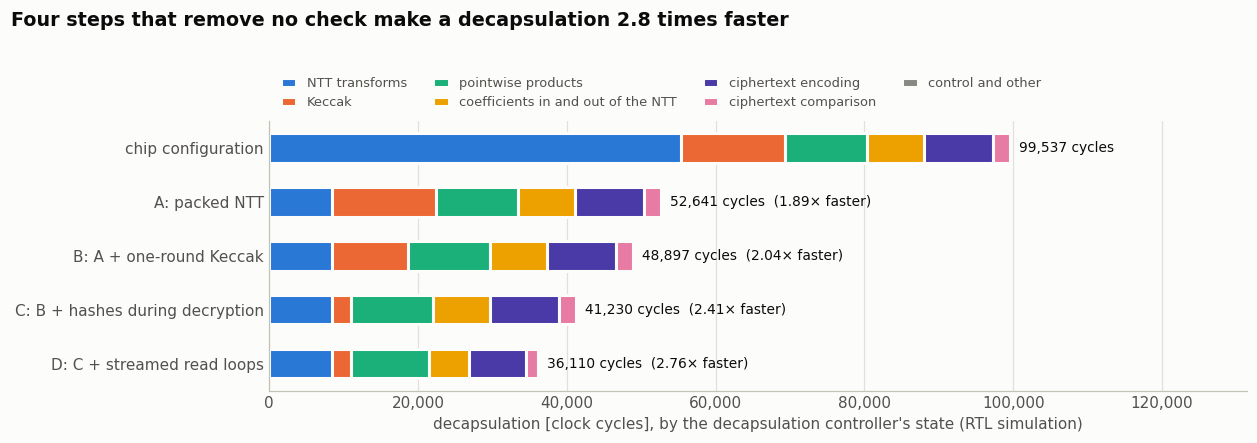

,NTT transforms,Keccak,pointwise products,coefficients in and out of the NTT,ciphertext encoding,ciphertext comparison,control and other,total
chip configuration,55320,13996,11011,7680,9220,2304,6,99537
A: packed NTT,8424,13996,11011,7680,9220,2304,6,52641
B: A + one-round Keccak,8424,10252,11011,7680,9220,2304,6,48897
C: B + hashes during decryption,8424,2585,11011,7680,9220,2304,6,41230
D: C + streamed read loops,8424,2585,10499,5376,7684,1536,6,36110


In [34]:
# True re-runs the eight builds (about fifteen minutes in parallel; works in Colab)
RUN_PACKED_SYSTEM = False
if RUN_PACKED_SYSTEM:
    sh("bash scripts/run_packed_system.sh")
psys = json.loads((ROOT/"results/system_sim/packed_system.json").read_text())
cs = psys["configs"]
STEPS = [("asic_sysR", "chip configuration"), ("asic_sysA", "A: packed NTT"),
         ("sram_only_sysB", "B: A + one-round Keccak"), ("sram_only_sysBC", "C: B + hashes during decryption"),
         ("sram_only_sysBCD", "D: C + streamed read loops")]
# every build passes the full-system testbench; valid and rejected ciphertexts take equally long
assert all(v["tb_result"].startswith("ALL PASS") for v in cs.values())
assert all(v["profiled_intervals_used"] >= 2 for v in cs.values())
assert all(v["packed_contract_check"]["violations"] == 0 for t, v in cs.items() if t != "asic_sysR")
assert all(psys["model_checks"].values()), psys["model_checks"]     # each step as the cycle model predicts
cyc_ = {t: cs[t]["decaps_cycles_valid_and_rejected"] for t, _ in STEPS}
assert cyc_["asic_sysR"] == int(cfg.loc["asic", "decaps_cycles"])     # without the defines: the published chip
ph_ = cs["sram_only_sysB"]["phases"]
assert ph_["hashes_h_ek_h_c_j"] < ph_["decryption"]                  # so the overlap hides the hashes entirely
GCOL = {"NTT transforms": ps.SERIES[0], "Keccak": ps.SERIES[1], "pointwise products": ps.SERIES[2],
        "coefficients in and out of the NTT": ps.SERIES[3], "ciphertext encoding": ps.SERIES[6],
        "ciphertext comparison": ps.SERIES[4], "control and other": ps.MUTED}
fig, ax = plt.subplots(figsize=(11.5, 3.9))
for y, (t, name) in enumerate(STEPS[::-1]):
    left = 0
    for g, col in GCOL.items():
        ax.barh(y, cs[t]["groups"][g], left=left, height=0.55, label=g if y == 0 else None, **ps.bar_kw(col))
        left += cs[t]["groups"][g]
    note = "" if t == "asic_sysR" else f"  ({cyc_['asic_sysR'] / cyc_[t]:.2f}× faster)"
    ax.annotate(f"{cyc_[t]:,} cycles{note}", (left, y), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=ps.INK)
ax.set_yticks(range(len(STEPS)), [n for _, n in STEPS[::-1]]); ax.grid(axis="y", visible=False)
ax.set_xlim(0, cyc_["asic_sysR"] * 1.32); ps.thousands(ax)
ax.set_xlabel("decapsulation [clock cycles], by the decapsulation controller's state (RTL simulation)")
ax.legend(ncols=4, loc="lower left", bbox_to_anchor=(0, 1.0), handlelength=1.2, fontsize=8.5)
ps.finish(fig, title="Four steps that remove no check make a decapsulation 2.8 times faster")
ps.save_pdf(fig, "decaps_redesign"); plt.show()
gtab = pd.DataFrame({name: cs[t]["groups"] for t, name in STEPS}).T
gtab["total"] = gtab.sum(axis=1)
gD = cs["sram_only_sysBCD"]["groups"]           # guards for the shares stated in the text below
assert 0.21 < gD["NTT transforms"] / cyc_["sram_only_sysBCD"] < 0.25
assert 0.6 < (gD["pointwise products"] + gD["ciphertext encoding"] + gD["coefficients in and out of the NTT"]) / cyc_["sram_only_sysBCD"] < 0.72
assert abs(int(cfg.loc["fpga", "decaps_cycles"]) / cyc_["sram_only_sysBCD"] - 2.3) < 0.05
assert cs["sram_only_sysBCD"]["phases"]["decryption"] == 7959 > cs["sram_only_sysB"]["phases"]["hashes_h_ek_h_c_j"]
gtab

Each step lands exactly where the cycle model puts it, and the assertions above check this to the cycle.
The packed engine removes 46,896 cycles, its saving of 5,286 cycles per forward and 6,438 per inverse
transform on four transforms of each kind. The one-round Keccak removes 144 cycles from each of the 26
permutations. The overlapped hashes remove their whole phase of 7,668 cycles less one cycle for the
hand-over, because the decryption beside them takes longer, 9,239 cycles. The streamed loops save one
cycle per element, 5,120 in all, and the decryption, now 7,959 cycles, still outlasts the hashes. Together
the four steps shorten a decapsulation from 99,537 to 36,110 cycles, 2.8 times faster than the chip's
configuration and 2.3 times faster than the FPGA configuration. The NTT now takes under a quarter of what
remains, while the pointwise products, the encoding of the ciphertext and the transfers of coefficients
in and out of the engine take two thirds; each of them still advances one coefficient every few cycles,
which marks them as the next targets. These results come from RTL simulation of the whole system, and
Section 9 runs the final configuration on the board; the signed-off chip keeps the original engines.

### What a decapsulation costs in energy

The profiled decapsulation also yields the energy of the whole chip. The logic's activity is replayed on
a shadow of the routed netlist, whose combinational cells are those of the layout and whose flip-flops
follow the RTL simulation, and annotated with the extracted parasitics; the clock network comes from
OpenSTA's clock analysis. The SRAM macros are priced with their transistor-level energies (Appendix C.4)
and the access counts of the decapsulation.

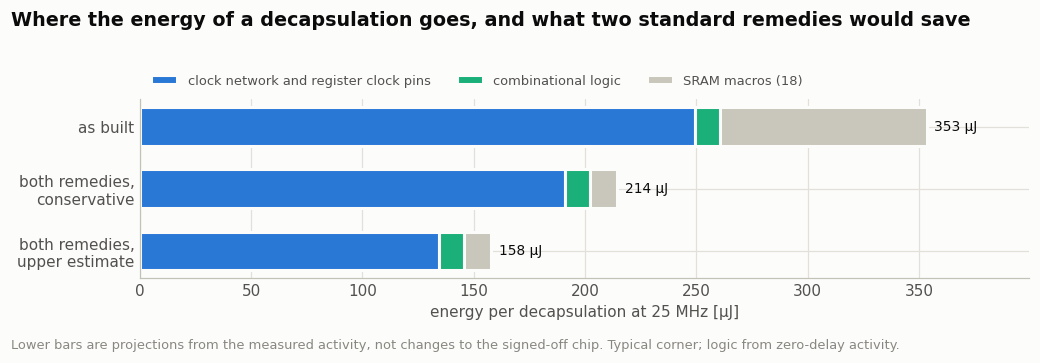

decapsulation: 99536 cycles at 40 ns; logic 65.5 mW, 580195 pins annotated from the shadow; SRAM accesses 1791648 as built, 70208 useful


In [35]:
pw = json.loads((ROOT/"results/fullchip/power.json").read_text())
se = json.loads((ROOT/"results/fullchip/sram_energy.json").read_text())
cg = json.loads((ROOT/"results/fullchip/clock_gating_whatif.json").read_text())
sa = json.loads((ROOT/"results/fullchip/sram_accesses.json").read_text())
t_dec = pw["window_cycles"] * pw["clock_ns"] * 1e-9                      # seconds
e = {k: v * 1e-3 * t_dec * 1e6 for k, v in pw["power_mw"].items()}         # uJ per decapsulation
sram = se["sram_energy_per_decaps_uj"]
gate = se["sram_energy_with_chip_select_gating_uj"]
saved_lo = cg["saved_by_gating_idle_blocks_mw"] * 1e-3 * t_dec * 1e6
saved_hi = cg["saved_upper_estimate_mw"] * 1e-3 * t_dec * 1e6
logic = sum(e.values())
seg = ["clock network and register clock pins", "combinational logic", "SRAM macros (18)"]
rows = {"as built": [e["clock"] + e["sequential"], e["combinational"], sram],
        "both remedies,\nconservative": [e["clock"] + e["sequential"] - saved_lo, e["combinational"], gate],
        "both remedies,\nupper estimate": [e["clock"] + e["sequential"] - saved_hi, e["combinational"], gate]}
fig, ax = plt.subplots(figsize=(9.5, 2.9))
for k, vals in enumerate(rows.values()):
    left = 0.0
    for j, v in enumerate(vals):
        ax.barh(k, v, left=left, height=0.62, label=seg[j] if k == 0 else None,
                **ps.bar_kw([ps.SERIES[0], ps.SERIES[2], "#c9c6bb"][j]))
        left += v
    ax.annotate(f"{left:.0f} µJ", (left, k), xytext=(5, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_yticks(range(len(rows)), list(rows)); ax.invert_yaxis()
ax.set_xlim(0, 1.13 * (logic + sram)); ax.set_xlabel("energy per decapsulation at 25 MHz [µJ]")
ax.legend(ncol=3, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False, fontsize=8.5)
ps.finish(fig, title="Where the energy of a decapsulation goes, and what two standard remedies would save")
fig.text(0.01, -0.04, "Lower bars are projections from the measured activity, not changes to the signed-off chip. "
         "Typical corner; logic from zero-delay activity.", fontsize=8.5, color=ps.MUTED)
ps.save_pdf(fig, "decaps_energy"); plt.show()
useful = sum(v["useful_accesses"] for v in sa["instances"].values())
print(f"decapsulation: {pw['window_cycles']} cycles at {pw['clock_ns']:.0f} ns; logic {pw['logic_power_mw']:.1f} mW, "
      f"{pw['pins_annotated_from_vcd']} pins annotated from the shadow; SRAM accesses {18 * sa['window_cycles']} "
      f"as built, {useful} useful")
# guards for the statements made in the text below
assert 0.9 < (e["clock"] + e["sequential"]) / logic < 0.97                    # "about 95 % is clock"
assert e["combinational"] / logic < 0.05
assert 0.6 < pw["registers_never_toggling"] / pw["registers_compared"] < 0.7   # "two thirds"
assert 0.33 < (logic + sram) * 1e-3 < 0.37                                    # "about 0.35 mJ"
assert 0.22 < sram / (logic + sram) < 0.28                                     # "about a quarter"
assert 0.8 < 1 - gate / sram < 0.9                                             # "more than four fifths"
assert 0.37 < (sram - gate + saved_lo) / (logic + sram) < 0.43                # "roughly 40 to 55 %"
assert 0.52 < (sram - gate + saved_hi) / (logic + sram) < 0.58
assert cg["idle_flip_flops"] == 13400
assert useful / (18 * sa["window_cycles"]) < 0.05                             # "fewer than one in twenty"
assert cg["idle_blocks"] == ["g_qualification_puf_vault", "u_hsm_shell", "u_security_hmac", "u_c2_shake_drbg", "u_puf"]
assert 0.2 < cg["saved_fraction"] and cg["saved_upper_fraction"] < 0.5

The top bar shows that a decapsulation costs about 0.35 mJ at 25 MHz, and that little of it pays for the
computation. About 95 % of the logic's energy goes into the clock network and the clock pins of the
28,000 registers, two thirds of which never change during the operation. The SRAM macros add about a
quarter of the total, because their chip selects are tied active: all 18 access in every cycle, while
fewer than one access in twenty does useful work. Both are choices of the integration, and the lower bars
price their standard remedies: gating the clock of the five blocks that stay idle throughout (PUF vault,
PUF root service, HSM shell, HMAC and the deterministic random-bit generator), and driving each chip
select from the block's own requests, which removes more than four fifths of the SRAM energy. Together
they would save roughly 40 to 55 %, a projection from the measured activity rather than a change made to
the signed-off chip.

# Part III — Does it hold up?

The last part leaves the simulator in two directions: onto real hardware, where the same RTL runs on the
FPGA board, and towards a side-channel adversary, whose view of the power trace is modelled here.

## 9. The same RTL on the FPGA board

The board runs the FPGA configuration of the RTL, with a dual-port M20K store and one Keccak round per
clock; the two ASIC choices exist only in simulation and layout. On the DE25-Nano at 50 MHz, driven by an
ESP32 host over SPI, I executed the complete two-role ML-KEM flow 100 times in succession: key
generation, public-key transfer, encapsulation, ciphertext transfer and an independent decapsulation that
must reproduce the same shared secret. The FPGA's 16-bit cycle counters saturate at 65,535, so
decapsulation is reported as a lower bound; key generation and encapsulation vary by a few cycles, as
expected, because `SampleNTT` rejection-samples the **public** seed ρ.

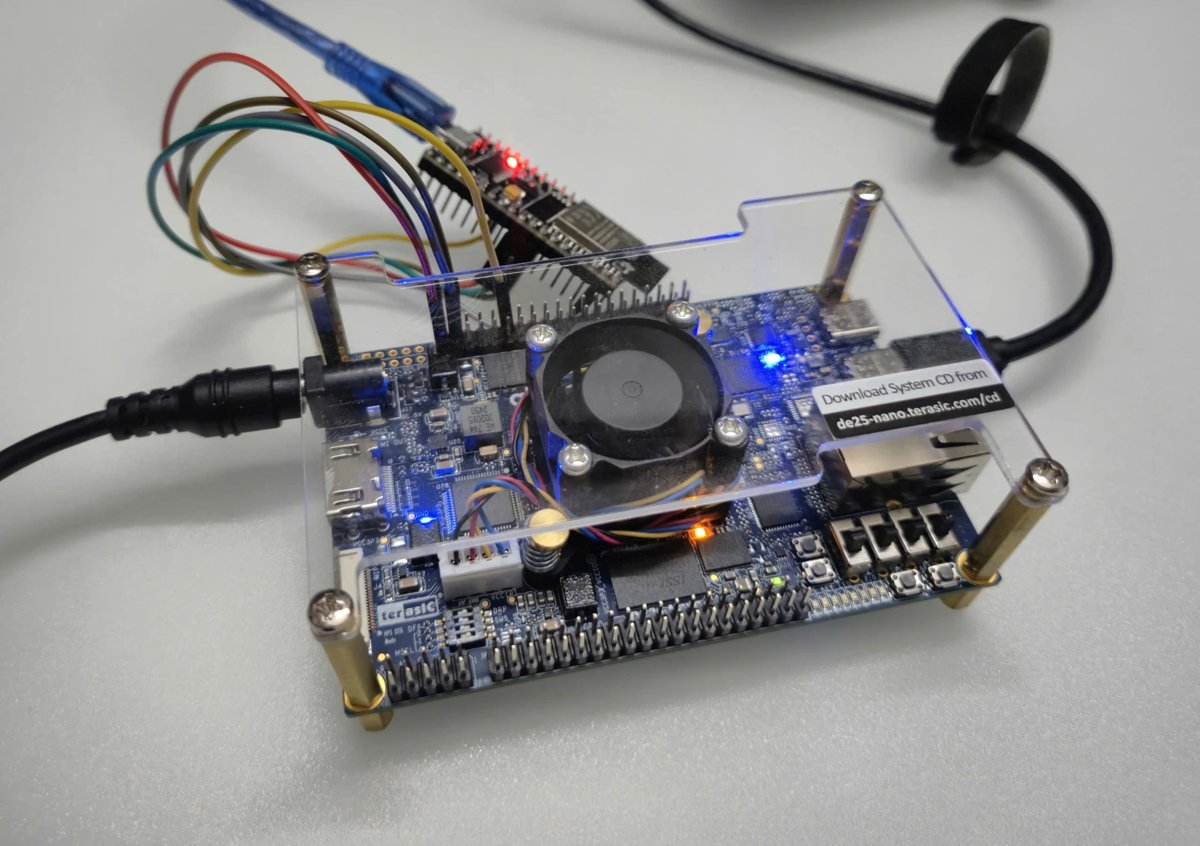

In [36]:
display(Image(str(ROOT/"results/fpga/board_setup.jpg"), width=620))

*The measurement setup. The DE25-Nano board (Altera Agilex 5, shown in an acrylic case with its cooling
fan) hosts HSKEM; the ESP32 development board at the rear acts as the untrusted host and reaches the
FPGA's GPIO header through the jumper wires that carry the SPI link.*

,min,median,max,saturated runs,core time at median [ms],note
key generation,35640,35655,35670,0,0.7131,
encapsulation,56157,56171,56188,0,1.1234,
ciphertext finalization,6148,6148,6148,0,0.1230,
decapsulation,65535,65535,65535,100,1.3107,counter saturated: lower bound only


runs: 100  all PASS: True  shared-secret match in every run
end-to-end C3 latency seen by the ESP32: median 8625.3 ms  (min 8625.0, max 8625.7)
FPGA core time (lower bound, decaps saturated): 3.27 ms  ->  0.038 % of the end-to-end time
payload over the host link: 3,136 bytes per run; effective throughput median 364 B/s (range 363.6-363.6); end-to-end spread 628 us


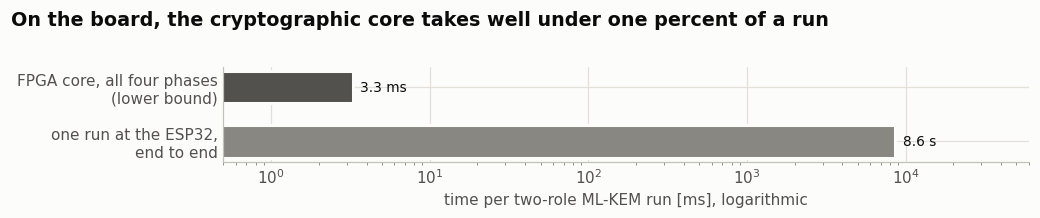

In [37]:
fr = json.loads((ROOT/"results/fpga/fpga_resources.json").read_text())     # resources: Appendix D.1
assert fr["device_total_alms"].startswith("39,")       # Section 1: "about 39,000 ALMs"
b = pd.read_csv(ROOT/"results/fpga/c3_repeat.csv")
F_CLK = 50e6
assert b.result_pass.all(), "a two-role ML-KEM run failed"
phases = ["keygen", "encaps", "ciphertext_final", "decaps"]
st = pd.DataFrame({p: {"min": b[f"{p}_cycles"].min(), "median": b[f"{p}_cycles"].median(),
                       "max": b[f"{p}_cycles"].max(),
                       "saturated": int((b[f"{p}_cycles"] >= 65535).sum())} for p in phases}).T
st["core_time_ms (at median)"] = st["median"] / F_CLK * 1e3
st["note"] = ["counter saturated: lower bound only" if s else "" for s in st["saturated"]]
display(st)
core_ms = st.loc[["keygen","encaps","ciphertext_final","decaps"], "median"].sum() / F_CLK * 1e3
e2e_ms = b.esp32_latency_us.median() / 1e3
print(f"runs: {len(b)}  all PASS: {bool(b.result_pass.all())}  shared-secret match in every run")
print(f"end-to-end C3 latency seen by the ESP32: median {e2e_ms:.1f} ms  (min {b.esp32_latency_us.min()/1e3:.1f}, max {b.esp32_latency_us.max()/1e3:.1f})")
print(f"FPGA core time (lower bound, decaps saturated): {core_ms:.2f} ms  ->  {100*core_ms/e2e_ms:.3f} % of the end-to-end time")
# guards for the statements made in the text below
assert core_ms / e2e_ms < 0.01, "the core no longer accounts for well under one percent"

# effective throughput of the host link: payload bytes moved per run (public key and ciphertext,
# each exported and imported once) over the end-to-end time, read from the raw log of every run
raw = (ROOT/"results/fpga/c3_repeat_raw.log").read_text()
moved = [sum(int(x) for x in re.findall(r"C3_(?:PUBLIC_KEY|CIPHERTEXT)_(?:EXPORT|IMPORT): PASS chunks=\d+ bytes=(\d+)", run))
         for run in raw.split("### run ")[1:]]
assert len(moved) == len(b) and set(moved) == {3136}
tput = 3136 / (b.esp32_latency_us / 1e6)
print(f"payload over the host link: 3,136 bytes per run; effective throughput median {tput.median():.0f} B/s "
      f"(range {tput.min():.1f}-{tput.max():.1f}); end-to-end spread {b.esp32_latency_us.max() - b.esp32_latency_us.min():.0f} us")
assert 300 < tput.median() < 450 and b.esp32_latency_us.max() - b.esp32_latency_us.min() < 1000

fig, ax = plt.subplots(figsize=(9.5, 1.9))
bars = {"FPGA core, all four phases\n(lower bound)": core_ms, "one run at the ESP32,\nend to end": e2e_ms}
for k, (name, v) in enumerate(bars.items()):
    ax.barh(k, v, height=0.6, **ps.bar_kw([ps.INK_2, ps.MUTED][k]))   # neutral: not the NTT/Keccak colours
    ax.annotate(f"{v/1e3:.1f} s" if v >= 1e3 else f"{v:.1f} ms", (v, k), xytext=(5, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_xscale("log"); ax.set_xlim(0.5, 6e4); ax.set_yticks(range(2), list(bars)); ax.invert_yaxis()
ax.set_xlabel("time per two-role ML-KEM run [ms], logarithmic")
ps.finish(fig, title="On the board, the cryptographic core takes well under one percent of a run"); plt.show()

**HSM security invariants.** The same board then ran the HSM's frame protection 100 times in a banking
scenario. Each run opens a fresh ML-KEM session and checks that an authenticated frame is accepted, that
a copy with the amount altered by one unit and a replay are rejected, and that after a zeroize every frame
is refused. This is a regression test on one board, not a security evaluation.

In [38]:
bank = pd.read_csv(ROOT/"results/fpga/bank_repeat.csv")
marks = [c for c in bank.columns if c.startswith("bank_")]
summary = pd.DataFrame({k: bank[k].value_counts() for k in marks}).fillna(0).astype(int).T
display(summary)
print("runs:", len(bank), " duplicate debits:", int(bank.duplicate_debit.sum()),
      " runs with any FAIL/failed text:", int(bank.any_fail_text.sum()))
assert (bank[marks] == "PASS").all().all() and bank.duplicate_debit.sum() == 0

,runs passed
ML-KEM session established,100
authenticated frame prepared,100
altered amount rejected,100
genuine frame accepted,100
replayed frame rejected,100
zeroize executed,100
frame after zeroize refused,100
complete scenario,100


runs: 100  duplicate debits: 0  runs with any FAIL/failed text: 0


**Where the time goes.** The bar chart above shows that on this prototype the cryptography is not the
bottleneck: the FPGA phases take a few milliseconds of a run that lasts about 8.6 seconds at the host,
because the ESP32 moves the public key and the ciphertext over a deliberately slow bit-banged SPI link at
about 0.36 kB/s (Appendix D.2). For the prototype the next speed-up must come from the interface; for
the chip, it is the NTT.

**The redesigned system on the board.** The board also ran the final redesign of Section 8: the packed
NTT, the overlapped hashes and the streamed loops, compiled from the same edits as the simulations, with
the one-round Keccak that the FPGA configuration always had. Its bitstream closes timing at 50 MHz and
passes five two-role runs. For the first time the decapsulation counter does not saturate: it reads
36,112 cycles in every run, the 36,110 cycles of the simulated busy interval plus the two cycles in which
the controller's start request and the returned done cross between the blocks. On the hardware the
redesign therefore takes exactly the time that the RTL simulation and the cycle model predict. The packed
engine needs 900 ALMs instead of 375, with the same single M20K and two DSP blocks.

In [39]:
pb = pd.read_csv(ROOT/"results/fpga/packed_c3_repeat.csv")
pkb = json.loads((ROOT/"results/fpga/packed_build.json").read_text())
sim_fcd = json.loads((ROOT/"results/system_sim/packed_system.json").read_text())["configs"]["fpga_sysFCD"]
display(pb[["run", "result_pass", "keygen_cycles", "encaps_cycles", "ciphertext_final_cycles", "decaps_cycles"]])
alm = [float(x["alms_needed"].split()[0]) for x in (fr["kyber_ntt_engine (u_shared_ntt)"],
                                                     pkb["kyber_ntt_engine_packed (u_shared_ntt)"])]
print(f"bitstream {pkb['sof_sha256'][:16]}… (not published), Fmax {pkb['fmax_clock1_50_mhz']} MHz; "
      f"NTT engine {alm[0]:.0f} -> {alm[1]:.0f} ALMs")
# guards for the statements made in the text above
assert pb.result_pass.all() and len(pb) == 5
assert (pb.decaps_cycles == 36112).all()                                  # equal in every run
assert pb.decaps_cycles.iloc[0] == sim_fcd["decaps_cycles_valid_and_rejected"] + 2
assert pkb["fmax_clock1_50_mhz"] > 50 and 2.2 < alm[1] / alm[0] < 2.6

run,result_pass,keygen_cycles,encaps_cycles,ciphertext_final_cycles,decapsulation cycles
0,1,21689,32163,5380,36112
1,1,21667,32176,5380,36112
2,1,21692,32187,5380,36112
3,1,21677,32183,5380,36112
4,1,21683,32165,5380,36112


bitstream 67066b54dd71b7bb… (not published), Fmax 54.8 MHz; NTT engine 375 -> 900 ALMs


## 10. What is not yet protected: a simulated leakage assessment

Timing is already settled: Sections 4 and 8 showed that neither block, nor a decapsulation as a whole,
takes a data-dependent number of cycles. This section turns to power, the channel that an attacker with
an oscilloscope would use.

**What is measured.** `tb/tb_ntt_leak.sv` simulates a forward NTT and records, for every clock cycle, how
many bits of the datapath registers change. This Hamming distance is the standard register-transition
stand-in for the power drawn in that cycle, and Gaussian noise of four bit flips (σ) is added to every
sample to imitate a real measurement.

**How it is tested.** `golden/leakage.py` applies the fixed-versus-random Test Vector Leakage Assessment
(TVLA) [6]. One set of traces transforms a fixed secret polynomial, the other fresh random ones, and
Welch's t-test compares the two sets cycle by cycle; a value of $|t| > 4.5$ means that the power in that
cycle depends detectably on the data. To check the test itself, a **negative control** compares two
halves of the random set, which come from the same distribution and must therefore stay below the
threshold.

**What it can show.** The model covers the registers of the engine's logic, not the switching inside an
SRAM macro, so it locates data-dependent activity in the logic; it does not predict how many physical
traces an attack would need.

**A first-order countermeasure.** Because the NTT is linear, it can be protected at the algorithm level
without any change to the hardware [7]. The secret $a$ is split into two shares, $a - m$ and a fresh
uniform mask $m$; the engine transforms each share separately, and the two results add up to
$\mathrm{NTT}(a)$. Each share on its own is uniformly random, so neither transform should reveal anything
about $a$. The same TVLA treats the two transforms as one trace, with 2000 traces per experiment in the
committed results and 400 in Colab.

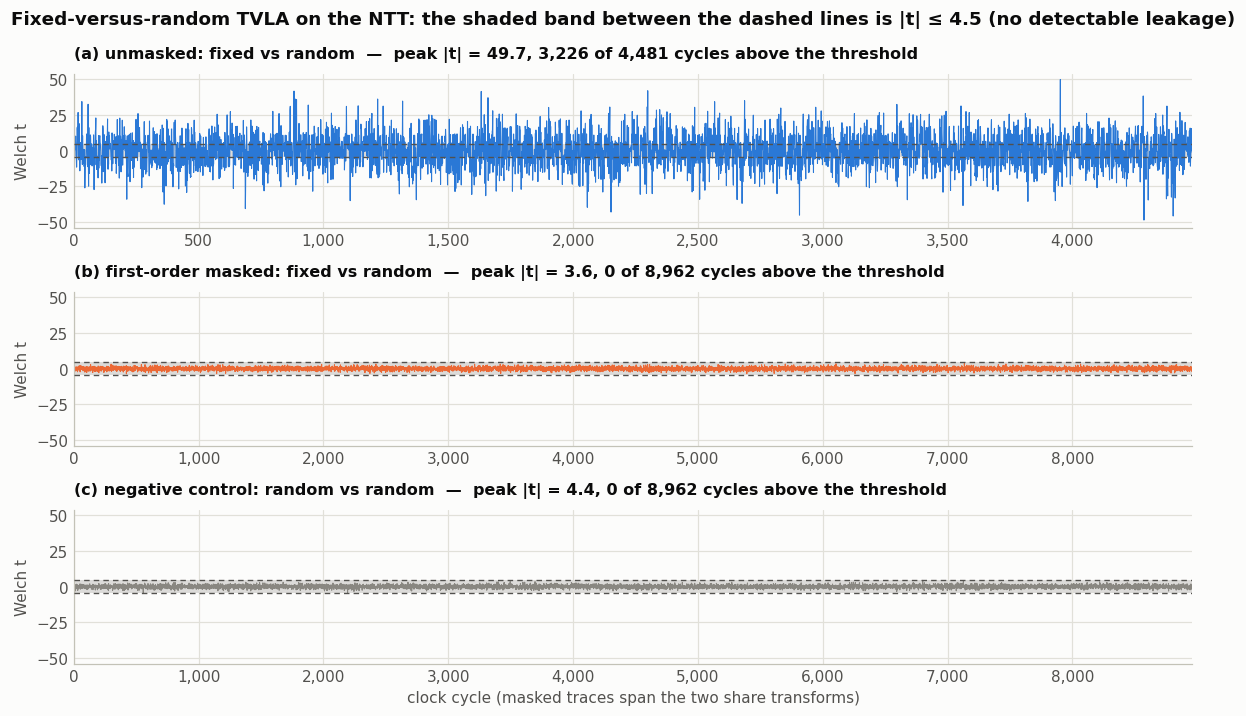

,traces,cycles,peak |t|,cycles with |t| > 4.5,share of cycles with |t| > 4.5,negative control: peak |t|,negative control: cycles with |t| > 4.5
unmasked,2000,4481,49.7495,3226,0.7199,3.4338,0
first-order masked,2000,8962,3.6362,0,0.0000,4.3507,0
"unmasked, ASIC configuration",2000,6273,44.1727,3259,0.5195,4.4953,0
"first-order masked, ASIC configuration",2000,12546,4.1766,0,0.0000,3.9590,0
"unmasked, packed engine",2000,987,65.8776,805,0.8156,3.5991,0
"first-order masked, packed engine",2000,1974,3.7052,0,0.0000,3.8296,0


In [40]:
LEAK_N = 400
if IN_COLAB:
    sh(f"bash scripts/run_leakage.sh {LEAK_N} 4.0 plain")
    sh(f"bash scripts/run_leakage.sh {LEAK_N} 4.0 masked")
summ, series = {}, []
for name, d in [("unmasked", "leakage"), ("first-order masked", "leakage_masked")]:
    summ[name] = json.loads((ROOT/"results"/d/"tvla_summary.json").read_text())
    series.append((f"{name}: fixed vs random", np.load(ROOT/"results"/d/"tvla_t.npy"), ps.SERIES[0 if name == "unmasked" else 1]))
series.append(("negative control: random vs random", np.load(ROOT/"results/leakage_masked/tvla_t_control.npy"), ps.MUTED))

ylim = max(np.abs(s[1]).max() for s in series) * 1.08
fig, axes = plt.subplots(3, 1, figsize=(11, 6.6), sharey=True)
for ax, tag, (title, t, colour) in zip(axes, "abc", series):
    ax.axhspan(-4.5, 4.5, color=ps.MUTED, alpha=0.28, zorder=0, lw=0)  # the "no detectable leakage" band
    ax.plot(t, lw=0.7, color=colour, zorder=2)
    for y in (4.5, -4.5):                           # thresholds stay visible above the trace
        ax.axhline(y, color=ps.INK_2, lw=0.9, ls=(0, (4, 3)), zorder=3)
    ax.set_ylim(-ylim, ylim); ax.set_xlim(0, len(t)); ax.set_ylabel("Welch t"); ps.thousands(ax)
    over = int((np.abs(t) > 4.5).sum())
    ax.set_title(f"({tag}) {title}  —  peak |t| = {np.abs(t).max():.1f}, {over:,} of {len(t):,} cycles above the threshold",
                 fontsize=10.5, loc="left")
axes[-1].set_xlabel("clock cycle (masked traces span the two share transforms)")
fig.suptitle("Fixed-versus-random TVLA on the NTT: the shaded band between the dashed lines is |t| ≤ 4.5 (no detectable leakage)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()
S = pd.DataFrame(summ).T[["traces", "runs_per_trace", "max_abs_t", "cycles_over_4p5",
                          "fraction_over_4p5", "control_max_abs_t", "control_cycles_over_4p5"]]
assert (S.control_cycles_over_4p5 == 0).all(), "negative control failed"
assert S.loc["unmasked", "cycles_over_4p5"] > 0 and S.loc["first-order masked", "cycles_over_4p5"] == 0
assert summ["first-order masked"]["cycles"] == 2 * summ["unmasked"]["cycles"]   # "twice the transform time"
# the same assessment of the ASIC configuration (single-port store), 2000 traces, committed results only
for name, d in [("unmasked, ASIC configuration", "leakage_asic"), ("first-order masked, ASIC configuration", "leakage_masked_asic"),
                ("unmasked, packed engine", "leakage_packed"), ("first-order masked, packed engine", "leakage_masked_packed")]:
    f = ROOT/"results"/d/"tvla_summary.json"
    if f.exists():
        summ[name] = json.loads(f.read_text())
S = pd.DataFrame(summ).T[["traces", "cycles", "max_abs_t", "cycles_over_4p5", "fraction_over_4p5",
                          "control_max_abs_t", "control_cycles_over_4p5"]]
assert (S.control_cycles_over_4p5 == 0).all(), "negative control failed"
assert S.loc["unmasked, ASIC configuration", "cycles_over_4p5"] > 0                  # "leaks as well"
assert S.loc["first-order masked, ASIC configuration", "cycles_over_4p5"] == 0       # "and masking removes it"
assert S.loc["unmasked, packed engine", "cycles_over_4p5"] > 0 and S.loc["first-order masked, packed engine", "cycles_over_4p5"] == 0
S

The figure confirms both expectations. Without masking, most cycles of the transform exceed the
threshold, many by a wide margin (a); with masking none does, and the peak $|t|$ stays at the level of
the negative control (b, c). The protection costs twice the transform time, mask generation not included.
The table repeats the assessment for the ASIC configuration, whose single-port store reorders the same
arithmetic over seven cycles per butterfly, and for the packed engine of Section 7, whose register banks
hold sixteen coefficients at a time: unmasked, both leak just as clearly, and masking again removes every
crossing of the threshold.
It establishes first-order resistance of the NTT stage within this model only: the rest of the
decapsulation, higher-order attacks, glitches and physical measurements remain outside its scope.

## 11. Findings

The next cell derives the ratios behind each finding from the committed results and asserts every claim
made in the text that follows, so that the prose cannot silently diverge from the data.

In [41]:
P = pnr[pnr.clk_target_ns == 20].set_index("variant")   # the common 20 ns comparison point
def ratio(col, a, b): return P.loc[a, col] / P.loc[b, col]
F = pd.Series({
    "NTT dual/single: cell area":       ratio("cell_area_um2", "ntt_dp", "ntt_sp"),
    "NTT dual/single: latency":         ratio("latency_us_at_fmax", "ntt_dp", "ntt_sp"),
    "NTT dual/single: area x time":     ratio("at_product", "ntt_dp", "ntt_sp"),
    "Keccak serial/round: cell area":   ratio("cell_area_um2", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: die area":    ratio("die_area_um2", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: fmax":        ratio("fmax_mhz", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: latency":     ratio("latency_us_at_fmax", "keccak_s7", "keccak_r1"),
    "Keccak serial/round: area x time": ratio("at_product", "keccak_s7", "keccak_r1"),
}).round(3)
assert F["NTT dual/single: latency"] < 1 < F["NTT dual/single: cell area"]
assert abs(F["NTT dual/single: area x time"] - 1) < 0.05
assert F["Keccak serial/round: cell area"] > 0.95 and 8.5 < F["Keccak serial/round: latency"] < 10  # "roughly nine times"
# every routed block-level layout, including the clock-sweep points, must be fully clean
assert (pnr.drc_errors == 0).all(), "a routed layout has DRC errors"
assert (pnr.antenna_violating_nets == 0).all(), "a routed layout has antenna violations"
# system level (Section 8): share of the decapsulation slowdown caused by each decision
sys_total = dec["both_delta"]
F["System: Decaps slowdown, both decisions"] = round(sys_total / int(cfg.loc["fpga", "decaps_cycles"]), 3)
F["System: share due to single-port store"] = round(dec["single_port_sram_delta"] / sys_total, 3)
F["System: share due to row-serial Keccak"] = round(dec["keccak_serial_delta"] / sys_total, 3)
assert F["System: share due to single-port store"] > 0.5 > F["System: share due to row-serial Keccak"]
assert dec["keccak_serial_delta"] / int(cfg.loc["fpga", "decaps_cycles"]) < 0.1   # "only a few percent"
assert 0.11 < pf.loc["fpga", "sponge_busy"] / pf.loc["fpga", "cycles"] < 0.14      # "about an eighth"
# design iteration (Section 7), post-route, final iteration vs the original single-port NTT
F["Iteration (routed): cell area"] = round(it.loc["ntt_opt_pipe_w12", "cell_area_um2"] / base_it.cell_area_um2, 3)
F["Iteration (routed): fmax"] = round(it.loc["ntt_opt_pipe_w12", "fmax_mhz"] / base_it.fmax_mhz, 3)
F["Iteration (routed): latency"] = round(it.loc["ntt_opt_pipe_w12", "latency_us_at_fmax"] / base_it.latency_us_at_fmax, 3)
F["Iteration (routed): area x time"] = round(it.loc["ntt_opt_pipe_w12", "at_product"] / base_it.at_product, 3)
assert F["Iteration (routed): cell area"] < 0.85 and F["Iteration (routed): latency"] < 0.75 \
       and F["Iteration (routed): fmax"] > 1.5 and F["Iteration (routed): area x time"] < 0.6
# the packed iteration (Sections 7 and 8)
F["Packed (routed): latency vs macro original"] = round(P.loc["ntt_packed", "latency_us_at_fmax"] / P.loc["ntt_macro", "latency_us_at_fmax"], 3)
F["Packed (routed): total area vs macro original"] = round(sum(total_area("ntt_packed_20ns")) / sum(total_area("ntt_macro_20ns")), 3)
F["Packed system: decapsulation vs chip configuration"] = round(cyc_["sram_only_sysBCD"] / cyc_["asic_sysR"], 3)
assert 1.35 < F["Packed (routed): total area vs macro original"] < 1.55     # "almost half more area"
assert F["Packed (routed): latency vs macro original"] < 1 / 8.5            # "nine times faster"
print("NTT fmax [MHz]:", P.loc[["ntt_dp","ntt_sp"], "fmax_mhz"].round(1).to_dict())
F

NTT fmax [MHz]: {'ntt_dp': 47.5, 'ntt_sp': 49.8}


NTT dual/single: cell area                            1.333
NTT dual/single: latency                              0.748
NTT dual/single: area x time                          0.997
Keccak serial/round: cell area                        0.986
Keccak serial/round: die area                         0.965
Keccak serial/round: fmax                             0.719
Keccak serial/round: latency                          9.405
Keccak serial/round: area x time                      9.272
System: Decaps slowdown, both decisions               0.222
System: share due to single-port store                0.793
System: share due to row-serial Keccak                0.207
Iteration (routed): cell area                         0.786
Iteration (routed): fmax                              1.658
Iteration (routed): latency                           0.689
Iteration (routed): area x time                       0.542
Packed (routed): latency vs macro original            0.111
Packed (routed): total area vs macro ori

Taken together, the measurements of Parts I to III support seven findings.

| Finding | Evidence | Section |
|:---|:---|:---:|
| **The design is correct from Python to layout.** | every NIST vector in the golden model; all 25 key-generation vectors on the complete RTL; a proof of the reducer; gate-level agreement of the routed blocks | 2, 4, 7 |
| **The single-port store is the right store and the main cost.** | a second port buys a flip-flop store nothing in area × time; the chip's macro saves a third of the area and four fifths of the energy; yet the single port sets most of the ASIC's extra latency | 6, 8 |
| **Row-serializing Keccak barely matters.** | about 1 % less area for a permutation nine times slower and 5.5 times costlier in energy, which still adds only a few percent to a decapsulation | 6, 8 |
| **The integration sets the energy.** | about 0.35 mJ per decapsulation, mostly clocking and macros selected in every cycle; two standard remedies would save 40 to 55 % by projection | 8 |
| **The measurements pay for themselves.** | a proof and two measurements gave an NTT about two thirds faster after routing; with flip-flops it halves area × time, with the chip's macro it costs a seventh more energy | 7 |
| **The single port need not cost time.** | two coefficients per word and fused layers cut the macro accesses of a transform from 6,274 to 768: nine times faster, a third of the energy, almost half more area; with the one-round Keccak, overlapped hashes and streamed loops a decapsulation takes 36,110 instead of 99,537 cycles, in RTL and on the board | 7, 8, 9 |
| **The prototype is interface-bound, and the NTT leaks.** | the core takes well under 1 % of a run on the board; masking removes the modelled first-order leakage of the NTT at twice its time | 9, 10 |

### Context: published Kyber hardware

HSKEM's NTT was designed for a small datapath and a simple controller rather than for speed. The table
compares it with the compact FPGA design of Xing and Li [13] and the Sapphire crypto-processor [14],
whose figures refer to other platforms and, for Sapphire, to round-1 Kyber, so it gives orders of
magnitude rather than a ranking.

In [42]:
fp_c = cfg.loc["fpga", "decaps_cycles"]
# the published figures are quoted from the cited papers; the HSKEM rows are read from this notebook's results
ctx = pd.DataFrame([
    {"design": "HSKEM, FPGA configuration (this work)", "platform": "Agilex 5 FPGA, 50 MHz",
     "cycles / NTT": int(sim.loc["ntt_dp", "cycles_measured"]), "cycles / decapsulation": f"{int(fp_c):,}",
     "resources": f"NTT engine: {fr['kyber_ntt_engine (u_shared_ntt)']['alms_needed'].split()[0]} ALMs, 1 M20K, 2 DSP"},
    {"design": "HSKEM, NTT redesign (this work)", "platform": f"SKY130, {P.loc['ntt_opt_pipe_w12', 'fmax_mhz']:.1f} MHz",
     "cycles / NTT": int(P.loc["ntt_opt_pipe_w12", "cycles"]), "cycles / decapsulation": "–",
     "resources": f"NTT block: {P.loc['ntt_opt_pipe_w12', 'cell_area_um2'] / 1e6:.3f} mm² (flip-flop store)"},
    {"design": "HSKEM, packed NTT (this work)", "platform": f"SKY130, {P.loc['ntt_packed', 'fmax_mhz']:.1f} MHz",
     "cycles / NTT": int(P.loc["ntt_packed", "cycles"]),
     "cycles / decapsulation": f"{cyc_['sram_only_sysBCD']:,} (RTL, Section 8)",
     "resources": "NTT block: {:.3f} mm² cells + {:.3f} mm² SRAM macro".format(*(a / 1e6 for a in total_area("ntt_packed_20ns")))},
    {"design": "Xing and Li, TCHES 2021 [13]", "platform": "Artix-7 FPGA, 161 MHz",
     "cycles / NTT": 448, "cycles / decapsulation": "6,668 (k = 2)",
     "resources": "complete KEM, server configuration: 7,412 LUTs, 2 DSP, 3 BRAM"},
    {"design": "Sapphire, TCHES 2019 [14]", "platform": "TSMC 40 nm, 72 MHz",
     "cycles / NTT": 1289, "cycles / decapsulation": "–",
     "resources": "processor core: 0.28 mm² (Kyber round 1, q = 7681)"},
]).set_index("design")
# guards for the comparison in the text below
assert int(P.loc["ntt_packed", "cycles"]) < 1289 and 1.8 < int(P.loc["ntt_packed", "cycles"]) / 448 < 2.5
assert 5.2 < cyc_["sram_only_sysBCD"] / 6668 < 5.6
ctx

design,platform,cycles / NTT,cycles / decapsulation,resources
"HSKEM, FPGA configuration (this work)","Agilex 5 FPGA, 50 MHz",4482,"81,457","NTT engine: 375.3 ALMs, 1 M20K, 2 DSP"
"HSKEM, NTT redesign (this work)","SKY130, 82.5 MHz",7170,–,NTT block: 0.170 mm² (flip-flop store)
"HSKEM, packed NTT (this work)","SKY130, 68.4 MHz",988,"36,110 (RTL, Section 8)",NTT block: 0.076 mm² cells + 0.132 mm² SRAM macro
"Xing and Li, TCHES 2021 [13]","Artix-7 FPGA, 161 MHz",448,"6,668 (k = 2)","complete KEM, server configuration: 7,412 LUTs, 2 DSP, 3 BRAM"
"Sapphire, TCHES 2019 [14]","TSMC 40 nm, 72 MHz",1289,–,"processor core: 0.28 mm² (Kyber round 1, q = 7681)"


The published designs need several to ten times fewer cycles per transform than HSKEM's original
engine, because they complete at least one butterfly per clock. Sapphire is the instructive case: it too
stores its coefficients in single-port SRAMs but spreads them over banks, so that the operands and
results of a butterfly never compete for one port. The packed iteration of Section 7 reaches the same
effect with a single macro: at 988 cycles it needs fewer than Sapphire and about twice as many as Xing
and Li's design, whose two memory banks also hold pairs of coefficients. A decapsulation, at 36,110
cycles in RTL simulation, still takes more than five times as many cycles as theirs, because the
datapath around the NTT advances one coefficient every few cycles (Section 8).

### Things that looked right and were not

Several results here exist only because a first answer that looked right was checked by a second,
independent route. In each case a tool reported success, or a plausible number, on incomplete input or
with a model that did not apply. An open flow makes such errors easy to commit, and the lesson that
transfers is to obtain every important number twice, by routes that share no shortcut.

| What looked right | What was wrong | What exposed it |
|:---|:---|:---|
| Timing of the routed chip from its exported netlist, with two hold violations | ORFS leaves the antenna diodes out of the netlist while the parasitics refer to them, so about 4,300 nets lost their wiring | Re-timing the routed database, which reproduces ORFS's own report to the picosecond (Appendix C.1) |
| The power view that OpenRAM writes for each SRAM macro | It reports several megawatts for a single macro | Transistor-level simulation of every macro type (Appendix C.4) |
| Device sizes read from OpenRAM's SPICE netlists | Junction areas are written as `0.75u` but mean square microns, so they were read a million times too small | Checking the unit suffix of every device parameter before simulation (`scripts/sram_energy_spice.sh`) |
| The expectation that wiring capacitance raises energy | The extracted layout draws *less* energy per access than the schematic | The same extracted netlist simulated with and without its capacitors (Appendix C.4) |
| A clean design-rule report from the flow | Its front-end section was disabled; with it, implant gaps inside the OpenRAM macros produce 180,456 markers | Running the front-end rules on their own (Appendix C.3) |
| Repaired transitions on the macro's address pins | The macro sat against the die edge, so the repair buffers ended up 25 to 70 µm from its pins | Measuring the transition at every address pin after routing (Appendix B.4) |

In [43]:
# evidence behind each row of the table above
sta_fc = json.loads((ROOT/"results/fullchip/sta_corners.json").read_text())
assert "4,300 nets" in sta_fc["analysis"]
lib_w = json.loads((ROOT/"results/gls_power/ntt_macro_20ns/summary.json").read_text())["macro_liberty_power_w"]
assert lib_w > 1e6                                                              # "several megawatts"
wd_ = json.loads((ROOT/"results/fullchip/sram_wiring_diagnosis.json").read_text())
assert wd_["without_wiring"]["read_pj"] > wd_["with_wiring"]["read_pj"]
fe = json.loads((ROOT/"results/fullchip/feol_drc.json").read_text())
assert fe["signed_off_gds"]["markers_total"] == 180456 and set(fe["signed_off_gds"]["markers_by_location"]) == {"OpenRAM macro"}
assert fe["after_implant_fix"]["markers_total"] == 0
print(f"OpenRAM power view of the 16x256 macro: {lib_w / 1e6:.1f} MW; FEOL markers before/after the implant fix: "
      f"{fe['signed_off_gds']['markers_total']:,} / {fe['after_implant_fix']['markers_total']}")

OpenRAM power view of the 16x256 macro: 3.9 MW; FEOL markers before/after the implant fix: 180,456 / 0


## 12. Limitations

The findings hold within the following boundaries.

* **Pre-silicon and uncertified.** Nothing has been fabricated, and the design holds no NIST algorithm (CAVP) or
  module (CMVP) validation certificate, which only an accredited laboratory can obtain.
* **Physical verification.** The chip passes the complete DRC deck only after the implant gaps inside the
  OpenRAM macros are closed (Appendix C.3), and its LVS abstracts the SRAMs, which are verified separately.
  Four of the five macro-store block layouts exceed the macro's 0.04 ns address-pin transition limit on
  two to four pins, by about 4 ps at most (Appendix B.4).
* **Timing.** Closure was performed at the typical corner; the slow corner roughly halves every block's
  frequency, and the SRAM timing views exist for the typical corner only. The signed-off chip misses hold
  by 1 ps on one path at the fast corner (Appendix C.1).
* **Power.** All energies are for the typical corner, and the chip's logic energy rests on zero-delay
  activity, so glitches are not counted. The SRAM energies come from transistor-level simulation of every
  macro type; the wiring correction was measured on the macros whose extracted layouts could be simulated
  and averaged for the others, and the access energy depends on the clock period (Appendix C.4).
* **Scope.** Apart from the macro-store points, the block-level stores are built from flip-flops, and
  dual-port or banked SRAM macros were not evaluated.
* **The redesigns are not in the chip.** Both NTT iterations, the restored one-round Keccak, the
  overlapped hashes and the streamed loops are verified in RTL simulation and, for the blocks, at gate
  level after place-and-route; the final system also ran on the board (Section 9). The signed-off chip
  and its energy keep the original engines.
* **Security and hardware.** The leakage assessment is a register-transition model of the logic, not a
  power measurement. The PUF and entropy sources are ring oscillators on the FPGA and service interfaces
  on the ASIC, and the FPGA measurements come from a single board.

**Reuse.** No existing notebook was reused. Apart from the third-party material listed in `NOTICE` (the
SKY130 cell models and the NIST ACVP vectors) and the OpenRAM views and netlists of the chip's own SRAM
macros, all code in this folder was written for this project.

**AI assistance.** Claude (Anthropic) assisted with debugging, with launching and monitoring the long
simulation and place-and-route runs, and with repetitive bookkeeping; the design, the measurements and
every claim are the author's responsibility.

### References
1. NIST, FIPS 203, *Module-Lattice-Based Key-Encapsulation Mechanism Standard*, 2024. doi:10.6028/NIST.FIPS.203.
2. NIST, FIPS 202, *SHA-3 Standard: Permutation-Based Hash and Extendable-Output Functions*, 2015.
   doi:10.6028/NIST.FIPS.202.
3. NIST, ACVP-Server test vectors for ML-KEM, https://github.com/usnistgov/ACVP-Server.
4. G. Bertoni, J. Daemen, M. Peeters, G. Van Assche, *The Keccak reference*, version 3.0, 2011.
5. P. Barrett, "Implementing the Rivest Shamir and Adleman public key encryption algorithm on a standard
   digital signal processor", *Advances in Cryptology — CRYPTO '86*, Springer, 1987.
   doi:10.1007/3-540-47721-7_24.
6. G. Goodwill, B. Jun, J. Jaffe, P. Rohatgi, "A testing methodology for side-channel resistance
   validation", NIST Non-Invasive Attack Testing Workshop, 2011.
7. O. Reparaz, S. Sinha Roy, F. Vercauteren, I. Verbauwhede, "A masked ring-LWE implementation",
   *Cryptographic Hardware and Embedded Systems — CHES 2015*, Springer, 2015. doi:10.1007/978-3-662-48324-4_34.
8. T. Ajayi et al., "Toward an open-source digital flow: first learnings from the OpenROAD project",
   *Design Automation Conference (DAC)*, 2019, doi:10.1145/3316781.3326334; OpenROAD-flow-scripts,
   https://github.com/The-OpenROAD-Project/OpenROAD-flow-scripts.
9. M. R. Guthaus et al., "OpenRAM: an open-source memory compiler", *International Conference on
   Computer-Aided Design (ICCAD)*, 2016. doi:10.1145/2966986.2980098.
10. SkyWater Technology and Google, SKY130 open-source PDK, https://github.com/google/skywater-pdk.
11. YosysHQ, Yosys and the OSS CAD Suite, https://github.com/YosysHQ/oss-cad-suite-build; the `slang`
    front end, https://github.com/povik/yosys-slang; Icarus Verilog, https://github.com/steveicarus/iverilog.
12. G. Pope, `kyber-py`, https://github.com/GiacomoPope/kyber-py.
13. Y. Xing, S. Li, "A compact hardware implementation of CCA-secure key exchange mechanism
    CRYSTALS-KYBER on FPGA", *IACR Transactions on Cryptographic Hardware and Embedded Systems*,
    2021(2), pp. 328–356. doi:10.46586/tches.v2021.i2.328-356.
14. U. Banerjee, T. S. Ukyab, A. P. Chandrakasan, "Sapphire: a configurable crypto-processor for
    post-quantum lattice-based protocols", *IACR Transactions on Cryptographic Hardware and Embedded
    Systems*, 2019(4), pp. 17–61. doi:10.46586/tches.v2019.i4.17-61.
15. L. Botros, M. J. Kannwischer, P. Schwabe, "Memory-efficient high-speed implementation of Kyber on
    Cortex-M4", *Progress in Cryptology — AFRICACRYPT 2019*, Springer, 2019, pp. 209–228.
    doi:10.1007/978-3-030-23696-0_11.

# Appendices

The appendices hold the supporting detail; every check and assertion in them still runs, and each is
referenced where its result is used: **A** verification, **B** place-and-route, **C** the chip, **D** the
FPGA, **E** reproduction.

## A. Verification details

### A.1 The on-chip self-test constant

HSKEM's NTT self-test compares a fingerprint of the transform of $a_i = 7 + 13i$, a CRC-16/CCITT-FALSE of
the 256 output coefficients followed by their 16-bit sum, with the constant `0xFC3B59FC` in the RTL and
firmware; the cell below recomputes it from the golden model.

In [44]:
import binascii
a = [7 + 13 * i for i in range(256)]
out = ref.ntt(a)
digest = (binascii.crc_hqx(b"".join(c.to_bytes(2, "big") for c in out), 0xFFFF) << 16) | (sum(out) & 0xFFFF)
print(f"golden self-test fingerprint: 0x{digest:08X}")
assert digest == 0xFC3B59FC, "on-chip self-test constant does not match the FIPS 203 NTT"

golden self-test fingerprint: 0xFC3B59FC


### A.2 The memory-access pattern of the NTT

Each layer halves the distance between the operands of a butterfly, from 128 coefficients to 2, and every
butterfly reads two coefficients and writes two back: one cycle per pair on a dual-port memory, one per
access on a single-port memory, as the controller trace of Section 3 shows.

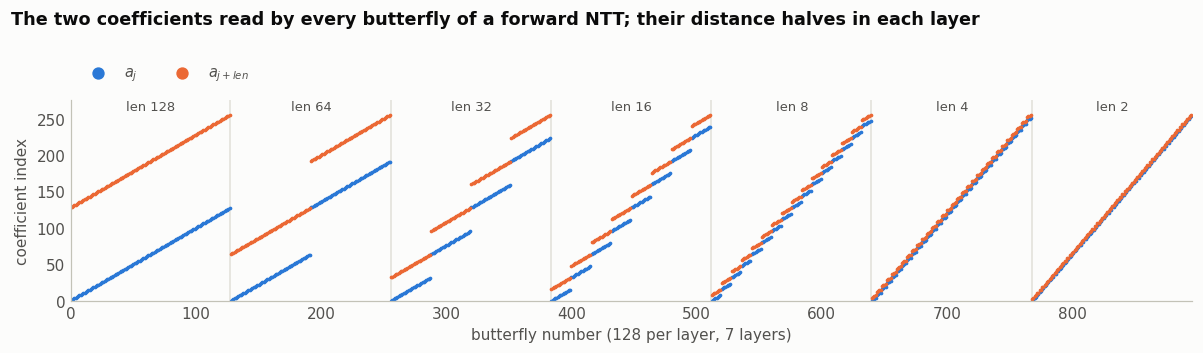

In [45]:
# the memory-access pattern of the whole transform, read from the same trace
f = tr["ntt_sp"][tr["ntt_sp"].state == "FETCH"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.scatter(f.index, f.j, s=2, color=ps.SERIES[0], label="$a_j$", rasterized=True)
ax.scatter(f.index, f.j + f.len, s=2, color=ps.SERIES[1], label="$a_{j+len}$", rasterized=True)
for layer, (L, g) in enumerate(f.groupby("len", sort=False)):
    x0 = g.index.min()
    if layer:
        ax.axvline(x0 - 0.5, color=ps.GRID, lw=1, zorder=0)
    ax.text(x0 + 64, 262, f"len {L}", ha="center", fontsize=8.5, color=ps.INK_2)
ax.set_xlim(0, 896); ax.set_ylim(0, 275); ax.grid(False)
ax.set_xlabel("butterfly number (128 per layer, 7 layers)"); ax.set_ylabel("coefficient index")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=2, markerscale=5, frameon=False)
fig.suptitle("The two coefficients read by every butterfly of a forward NTT; their distance halves in each layer",
             x=0.01, ha="left", y=0.99, fontsize=11.5, fontweight="bold")
ps.finish(fig); plt.show()

## B. Place-and-route details

### B.1 Every routed run

The table lists every routed design point, including the clock sweep and the iterations. The blocks are
compared on their worst **register-to-register** slack, because the design-level slack includes the I/O
budget of the timing constraints, which for the Keccak wrapper makes a combinational read path of the
wrapper critical; the design-level value is kept in `design fmax`. OpenSTA's vectorless power estimates
are omitted.

In [46]:
cols = ["variant","clk_target_ns","flow_rc","die_area_um2","cell_area_um2","flops","wns_ns","reg2reg_slack_ns",
        "fmax_mhz","fmax_design_mhz","drc_errors","antenna_violating_nets","cycles","latency_us_at_fmax","at_product"]
pnr[[c for c in cols if c in pnr]]

design,clock target [ns],flow exit code,die area [µm²],cell area [µm²],flip-flops,design WNS [ns],reg→reg slack [ns],reg→reg fmax [MHz],design fmax [MHz],DRC errors,antenna violations,cycles,latency at fmax [µs],area × time [mm²·µs]
"Keccak, one round per clock",10,0,470850,235078.0,3207,2.0061,5.69,232.0186,125.0960,0,0,25,0.1077,0.0253
"Keccak, one round per clock",20,0,470850,234290.0,3207,7.1845,14.48,181.1594,78.0308,0,0,25,0.1380,0.0323
"Keccak, one round per clock",7,0,470850,237944.0,3207,0.5862,2.82,239.2344,155.9150,0,0,25,0.1045,0.0249
"Keccak, row-serialized",10,0,454316,231333.0,3534,1.3298,4.46,180.5054,115.3380,0,0,169,0.9363,0.2166
"Keccak, row-serialized",20,0,454316,230962.0,3534,6.5019,12.32,130.2083,74.0846,0,0,169,1.2979,0.2998
"Keccak, row-serialized",7,0,454316,235517.0,3534,0.1592,2.09,203.6660,146.1810,0,0,169,0.8298,0.1954
"NTT, dual-port store",15,0,574200,287563.0,4277,-6.0969,-6.10,47.3934,47.4003,0,0,4482,94.5702,27.1949
"NTT, dual-port store",20,0,574200,287711.0,4277,-1.0580,-1.06,47.4834,47.4878,0,0,4482,94.3909,27.1573
"NTT, dual-port store",30,0,574200,281128.0,4277,2.8141,2.81,36.7782,36.7838,0,0,4482,121.8656,34.2598
"NTT, OpenRAM macro store",20,0,293206,38804.7,155,-0.7985,-0.80,48.0769,48.0805,0,0,6274,130.4992,5.0640


### B.2 The critical path and the routed layouts

The worst setup path of the single-port NTT (red) starts at a coefficient register, passes the modular
subtraction of the inverse butterfly, the multiplier and the Barrett reducer, and ends at the
reduced-product register.

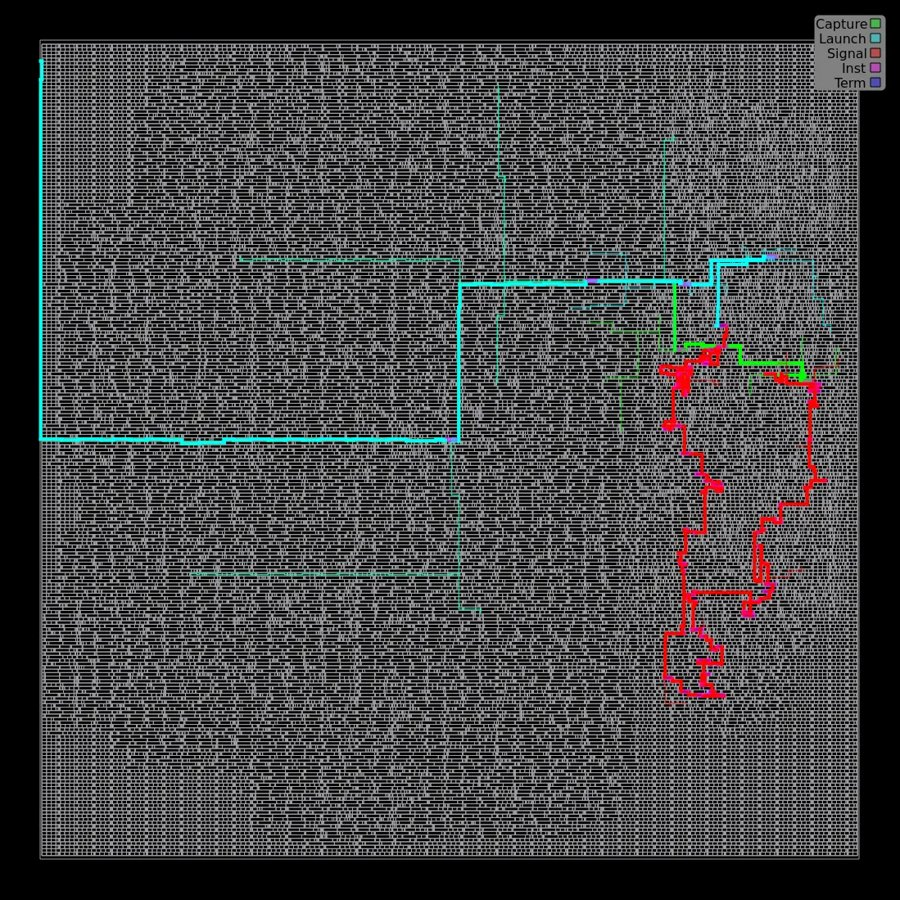

In [47]:
display(Image(str(ROOT/"results/asic/ntt_sp_20ns/worst_path.jpg"), width=520))

The routed layouts, rendered with KLayout at a common scale, show the NTT redesign of Section 7 as the
smallest of the four.

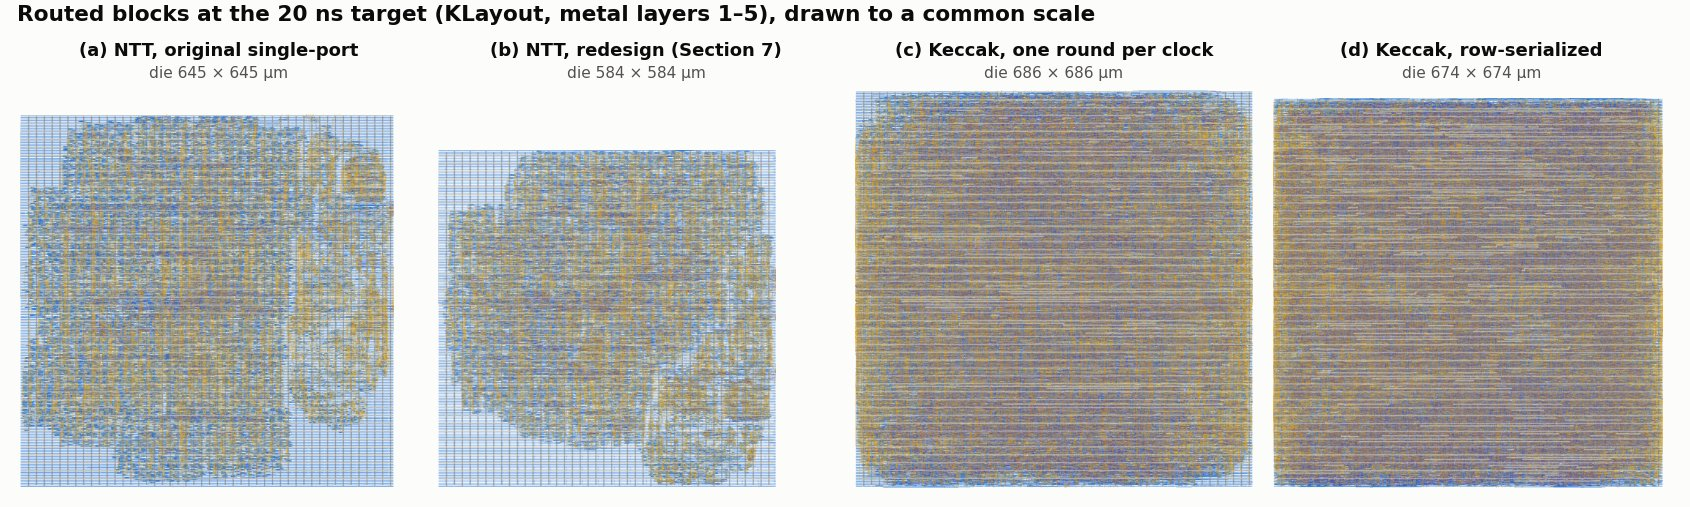

In [48]:
display(Image(str(ROOT/"figures/block_layouts.jpg")))

A picture of a layout is not the layout, so the next cell fetches one of the GDS files published with the
release `hskem-block-layouts`, checks its SHA-256 against `results/asic/release_gds_sha256.txt` and
renders the file itself with KLayout's Python module; `RUN_DRC_COLAB = True` also runs the front-end
rules of Appendix C.3 on it.

ntt_opt_pipe_w12_20ns.gds.gz: 2.3 MB, SHA-256 matches the committed list


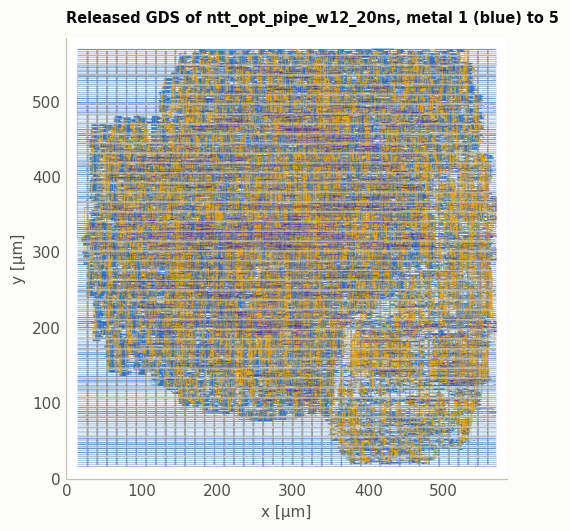

In [49]:
import hashlib, gzip, urllib.request
GDS_POINT = "ntt_opt_pipe_w12_20ns"          # any line of results/asic/release_gds_sha256.txt
RUN_DRC_COLAB = False
REL = "https://github.com/tandat08052007/sscs-ose-code-a-chip.github.io/releases/download/hskem-block-layouts"
want = dict(l.split()[::-1] for l in (ROOT/"results/asic/release_gds_sha256.txt").read_text().splitlines())
gz = pathlib.Path(f"/tmp/{GDS_POINT}.gds.gz")
try:
    if not gz.exists():
        urllib.request.urlretrieve(f"{REL}/{GDS_POINT}.gds.gz", gz)
    digest = hashlib.sha256(gz.read_bytes()).hexdigest()
    assert digest == want[f"{GDS_POINT}.gds.gz"], "the downloaded GDS differs from the published checksum"
    gds = gz.with_suffix("")
    gds.write_bytes(gzip.decompress(gz.read_bytes()))
    print(f"{GDS_POINT}.gds.gz: {gz.stat().st_size / 1e6:.1f} MB, SHA-256 matches the committed list")
    try:
        import klayout.lay as kl
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "klayout"], check=True)
        import klayout.lay as kl
    lv = kl.LayoutView()
    lv.set_config("background-color", "#ffffff"); lv.set_config("grid-visible", "false")
    lv.set_config("text-visible", "false")
    lv.load_layout(str(gds), True); lv.max_hier()
    METAL = {(68, 20): 0x2a78d6, (69, 20): 0xeda100, (70, 20): 0x4a3aa7, (71, 20): 0x898781, (72, 20): 0xc3c2b7}
    it = lv.begin_layers()
    while not it.at_end():                      # metal 1 to 5 only, as in the figure above
        lp = it.current()
        key = (lp.source_layer, lp.source_datatype)
        if key not in METAL:
            lp.visible = False
        else:                                   # the palette of the three-scale layout figure of Section 7
            lp.fill_color = lp.frame_color = METAL[key]; lp.dither_pattern = 2
        lv.set_layer_properties(it, lp)
        it.next()
    lv.zoom_fit(); lv.save_image("/tmp/gds_render.png", 1000, 1000)
    bb = lv.active_cellview().layout().top_cell().dbbox()
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.imshow(plt.imread("/tmp/gds_render.png"), extent=(0, bb.width(), 0, bb.height()))
    ax.set_xlabel("x [µm]"); ax.set_ylabel("y [µm]"); ax.grid(False)
    ax.set_title(f"Released GDS of {GDS_POINT}, metal 1 (blue) to 5", loc="left", fontsize=9.5)
    plt.show()
    if RUN_DRC_COLAB:
        if not have("klayout"):
            subprocess.run("apt-get -qq install -y klayout > /dev/null", shell=True, check=True)
        print(sh(f"bash scripts/feol_drc.sh {gds} /tmp/{GDS_POINT}_feol.lyrdb")[-300:])
except OSError as e:                            # no network: the committed figure above still stands
    print("could not fetch the release asset:", e)

### B.3 Response to the clock target

Runs at 7 to 30 ns show how far each block can be pushed (reg→reg fmax, and area relative to 20 ns).

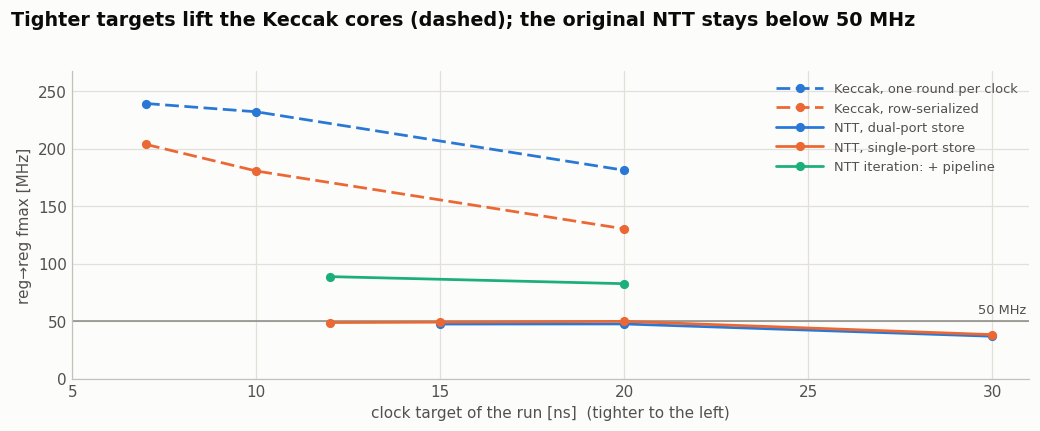

cell-area change vs 20 ns [%],7 ns,10 ns,12 ns,15 ns,20 ns,30 ns
"Keccak, one round per clock",1.6,0.3,,,0.0,
"Keccak, row-serialized",2.0,0.2,,,0.0,
"NTT, dual-port store",,,,-0.1,0.0,-2.3
"NTT, OpenRAM macro store",,,,,0.0,
NTT iteration: 12-bit store,,,,,0.0,
"NTT iteration: + pipeline, OpenRAM macro store",,,0.7,,0.0,
NTT iteration: + pipeline,,,0.6,,0.0,
"NTT iteration: packed pairs, 24 × 128 macro",,,4.2,,0.0,
"NTT, single-port store",,,0.4,0.7,0.0,-3.1


In [50]:
fx = pnr.pivot(index="variant", columns="clk_target_ns", values="fmax_mhz")
ar = pnr.pivot(index="variant", columns="clk_target_ns", values="cell_area_um2")
darea = 100 * (ar.div(ar[20.0], axis=0) - 1)
show = fx.round(1).astype(object).where(fx.notna(), "")
show.columns = [f"{c:g} ns" for c in show.columns]
fig, ax = plt.subplots(figsize=(9.5, 3.8))
for v in ["keccak_r1", "keccak_s7", "ntt_dp", "ntt_sp", "ntt_opt_pipe_w12"]:
    line = fx.loc[v].dropna()
    ax.plot(line.index, line.values, marker="o", ms=5, lw=1.8, color=COLOR[v], label=LABEL[v],
            ls="-" if v.startswith("ntt") else (0, (5, 2)))
ps.reference_line(ax, 50, "50 MHz")
ax.legend(loc="upper right", fontsize=8.5, handlelength=3.6)
ax.set_xlim(5, 31); ax.set_ylim(0, fx.max().max() * 1.12)
ax.set_xlabel("clock target of the run [ns]  (tighter to the left)"); ax.set_ylabel("reg→reg fmax [MHz]")
ps.finish(fig, title="Tighter targets lift the Keccak cores (dashed); the original NTT stays below 50 MHz")
plt.show()
show = darea.round(1).astype(object).where(darea.notna(), "")
show.columns = [f"{c:g} ns" for c in show.columns]
display(show.rename(index=LABEL).rename_axis("cell-area change vs 20 ns [%]"))
# the statements below rest on these checks
assert fx.loc["keccak_r1", 7.0] > 1.3 * fx.loc["keccak_r1", 20.0] and fx.loc["keccak_s7", 7.0] > 1.5 * fx.loc["keccak_s7", 20.0]
assert darea.loc[["keccak_r1", "keccak_s7"], 7.0].max() < 2.0
assert fx.loc["ntt_dp"].max() < 50 and fx.loc["ntt_sp"].max() < 50
assert darea.loc[["ntt_dp", "ntt_sp"], 30.0].between(-3.5, -1.5).all()   # "saves only 2-3 % of area"
assert fx.loc["ntt_opt_pipe_w12", 12.0] > fx.loc["ntt_sp"].max() * 1.7

From 20 to 7 ns the Keccak cores gain about a third (one round per clock) and more than half
(row-serialized) in frequency for at most 2 % more area, while the original NTT blocks stay below 50 MHz
at every target, because sizing and buffering barely shorten their single-stage critical path.

### B.4 The macro's address pins

The macro's Liberty view limits the transition at its address pins to 0.04 ns. The flow's repair left
0.26 to 0.35 ns with minimum-size buffers, and larger buffers still 0.05 to 0.07 ns, because the placer
had put the macro against the die edge, where six of its address pins sit, and their drivers ended up
25 to 70 µm away. Two flow hooks fix the macro about 30 µm higher
(`flow/macro_place_ntt.tcl`) and place a 12-times buffer at the edge of its halo for every address pin
(`flow/post_grt_macro_pins.tcl`), as panel (b) of the layout figure in Section 7 shows. The remaining excesses, below half a picosecond at 20 ns and about 4 ps
at 12 ns, extrapolate the last entry of OpenRAM's analytical slew table by a few percent. The packed
engine's 24 × 128 macro carries its address pins on its top and bottom edges, so
`flow/macro_place_packed.tcl` leaves room on both, and the same hook places one driver for each of its
seven used address bits; `scripts/macro_pin_slew.py` measures all of them. Its excesses stay near 2 ps.

In [51]:
ps_ = json.loads((ROOT/"results/asic/macro_pin_slew.json").read_text())
pin_t = pd.DataFrame({r: v["address_pin_transition_ns"] for r, v in ps_["runs"].items()})
pin_t.columns = [{"ntt_macro_20ns": "original engine, 20 ns", "ntt_opt_pipe_macro_20ns": "pipelined, 20 ns",
                  "ntt_opt_pipe_macro_12ns": "pipelined, 12 ns", "ntt_packed_20ns": "packed, 20 ns",
                  "ntt_packed_12ns": "packed, 12 ns"}[c] for c in pin_t.columns]
display(pin_t.rename_axis("address-pin transition [ns]"))
# the statements made in Sections 6 and 7 and above
over = {r: v["pins_over_limit"] for r, v in ps_["runs"].items()}
assert {r: over[r] for r in ("ntt_macro_20ns", "ntt_opt_pipe_macro_20ns", "ntt_opt_pipe_macro_12ns")} == \
       {"ntt_macro_20ns": 2, "ntt_opt_pipe_macro_20ns": 0, "ntt_opt_pipe_macro_12ns": 2}, over
assert all(0.001 < ps_["runs"][r]["max_ns"] - 0.04 < 0.003 for r in ("ntt_packed_20ns", "ntt_packed_12ns"))   # "about 2 ps"
assert ps_["runs"]["ntt_macro_20ns"]["max_ns"] - 0.04 < 0.0005
assert ps_["runs"]["ntt_opt_pipe_macro_12ns"]["max_ns"] - 0.04 <= 0.0045
for r in ps_["runs"]:
    packed = r.startswith("ntt_packed")
    log = next((ROOT/"results/asic"/r/"logs").rglob("5_1_grt.log")).read_text()
    assert f"CAC_MACRO_PIN_ECO: placed {7 if packed else 8} address-pin drivers (sky130_fd_sc_hd__buf_12)" in log, r
    place = next((ROOT/"results/asic"/r/"logs").rglob("2_2_floorplan_macro.log")).read_text()
    assert ("macro_place_packed.tcl" if packed else "macro_place_ntt.tcl") in place, r

address-pin transition [ns],"original engine, 20 ns","pipelined, 20 ns","pipelined, 12 ns","packed, 20 ns","packed, 12 ns"
addr0[0],0.0398,0.0357,0.0442,0.0410,0.0408
addr0[1],0.0357,0.0361,0.0416,0.0421,0.0424
addr0[2],0.0404,0.0367,0.0400,0.0390,0.0378
addr0[3],0.0376,0.0365,0.0365,0.0420,0.0379
addr0[4],0.0367,0.0400,0.0396,0.0383,0.0397
addr0[5],0.0381,0.0393,0.0370,0.0387,0.0373
addr0[6],0.0402,0.0395,0.0399,0.0413,0.0398
addr0[7],0.0365,0.0371,0.0381,,


### B.5 Process corners and the hold margin

`scripts/sta_corners.sh` re-times every routed block at the slow (`ss`, 100 °C, 1.60 V) and the fast
corner (`ff`, −40 °C, 1.95 V); the typical corner reproduces the ORFS figures exactly.

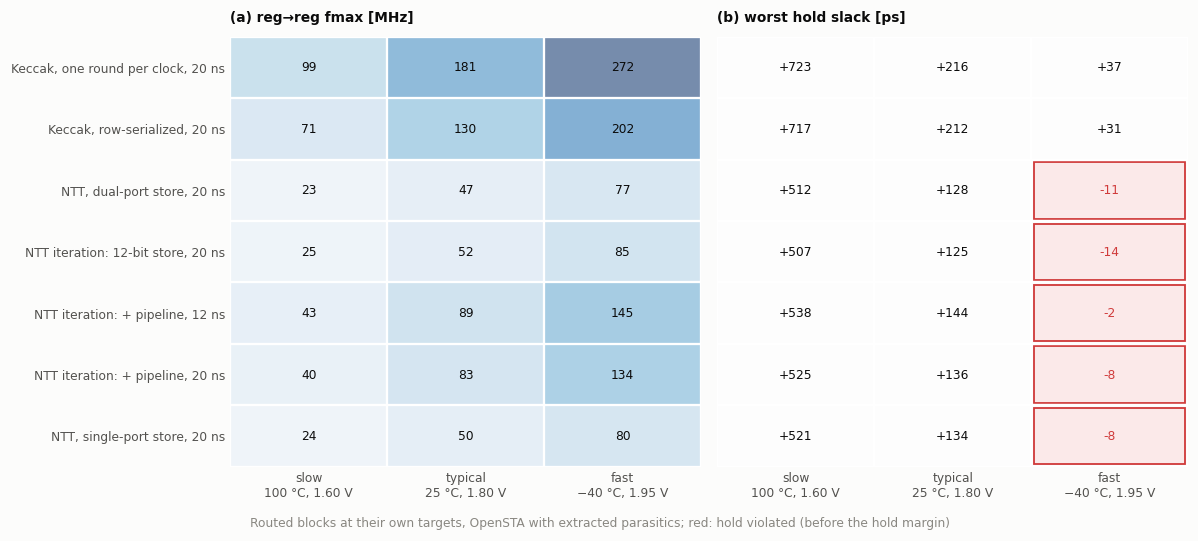

In [52]:
cor = pd.read_csv(ROOT/"results/sta_corners/summary.csv")
tt = cor[cor.corner == "tt_025C_1v80"].set_index("design")
tt_ref = pnr.assign(design=pnr.variant + "_" + pnr.clk_target_ns.map("{:g}".format) + "ns").set_index("design")
assert (abs(tt.reg2reg_setup_slack_ns - tt_ref.loc[tt.index, "reg2reg_slack_ns"]) < 0.01).all(), "STA setup differs from ORFS"
CORNER_ORDER = ["ss_100C_1v60", "tt_025C_1v80", "ff_n40C_1v95"]
fmx = cor.pivot(index="design", columns="corner", values="reg2reg_fmax_mhz")[CORNER_ORDER]
hold = cor.pivot(index="design", columns="corner", values="hold_wns_ns")[CORNER_ORDER] * 1e3      # ps
rows = [nbd.label(d) for d in fmx.index]
cols = ["slow\n100 °C, 1.60 V", "typical\n25 °C, 1.80 V", "fast\n−40 °C, 1.95 V"]
fig, ax = plt.subplots(1, 2, figsize=(11, 0.45 * len(rows) + 1.6))
for a, data, cmap, fmt, title in ((ax[0], fmx, "Blues", "{:.0f}", "(a) reg→reg fmax [MHz]"),
                                  (ax[1], hold * 0, "Greys", "{:+.0f}", "(b) worst hold slack [ps]")):
    a.imshow(data.values, cmap=cmap, aspect="auto", vmin=0, vmax=max(data.values.max(), 1), alpha=0.55)
    a.grid(False)
    for (r, c), v in np.ndenumerate((fmx if a is ax[0] else hold).values):
        a.text(c, r, fmt.format(v), ha="center", va="center", fontsize=8,
               color=ps.CRITICAL if (a is ax[1] and v < 0) else ps.INK)
        if a is ax[1] and v < 0:
            a.add_patch(plt.Rectangle((c - 0.48, r - 0.46), 0.96, 0.92, fc="#fbe9e9", ec=ps.CRITICAL, lw=1.2, zorder=0))
    a.set_xticks(range(3), cols, fontsize=8); a.set_yticks(range(len(rows)), rows if a is ax[0] else [""] * len(rows), fontsize=8)
    a.set_title(title, loc="left", fontsize=9); a.tick_params(length=0)
    for sp in a.spines.values(): sp.set_visible(False)
    a.set_xticks(np.arange(-0.5, 3), minor=True); a.set_yticks(np.arange(-0.5, len(rows)), minor=True)
    a.grid(which="minor", color="white", lw=1.5); a.tick_params(which="minor", length=0)
fig.text(0.5, -0.02, "Routed blocks at their own targets, OpenSTA with extracted parasitics; red: hold violated (before the hold margin)",
         ha="center", fontsize=8, color=ps.MUTED)
plt.tight_layout(); ps.save_pdf(fig, "corners"); plt.show()
# guards for the statements made in the text below
fx_c = cor.pivot(index="design", columns="corner", values="reg2reg_fmax_mhz")
hold_ff = cor[cor.corner.str.startswith("ff")].set_index("design").hold_wns_ns
assert fx_c["ss_100C_1v60"].div(fx_c["tt_025C_1v80"]).between(0.4, 0.6).all()
assert hold_ff.filter(like="ntt").between(-0.015, 0, inclusive="left").all()
assert (cor[cor.design.str.startswith("keccak")].reg2reg_hold_slack_ns > 0).all()

At the slow corner every block runs at roughly half its typical-corner frequency. At the fast corner the
five flip-flop-store NTT layouts miss hold by 2 to 14 ps, because ORFS repairs hold at the typical corner
only, so they were re-run with `HOLD_SLACK_MARGIN = 0.17` ns, re-timed and re-simulated at gate level.

In [53]:
hc = json.loads((ROOT/"results/asic/hold_margin_check.json").read_text())["layouts"]
CN = ("ss_100C_1v60", "tt_025C_1v80", "ff_n40C_1v95")
rows = {}
for base, v in hc.items():
    h0, h1 = v["committed"], v["hold margin 0.17 ns"]
    rows[base] = {"ff hold before [ps]": 1e3 * h0["hold_wns_ns_ff_n40C_1v95"],
                  "ff hold after [ps]": 1e3 * h1["hold_wns_ns_ff_n40C_1v95"],
                  "worst hold after, any corner [ps]": 1e3 * min(h1[f"hold_wns_ns_{c}"] for c in CN),
                  "cell change": h1["stdcell_count"] - h0["stdcell_count"],
                  "area change [%]": 100 * (h1["stdcell_area_um2"] / h0["stdcell_area_um2"] - 1),
                  "fmax before [MHz]": h0["fmax_mhz"], "fmax after [MHz]": h1["fmax_mhz"],
                  "GLS after": "pass" if h1["gls_pass"] else "FAIL"}
hct = pd.DataFrame(rows).T.infer_objects()
display(hct.round({c: 0 for c in hct.columns[:3]} | {"area change [%]": 3,
                   "fmax before [MHz]": 2, "fmax after [MHz]": 2}))
# guards for the statements made in the text
assert len(hc) == 5, "every NTT layout of the corner table should have been re-run"
assert (hct["ff hold before [ps]"] < 0).all() and (hct["worst hold after, any corner [ps]"] >= 0).all()
assert (hct["cell change"].abs() <= 6).all() and (hct["area change [%]"].abs() < 0.02).all()
assert (hct["fmax after [MHz]"] / hct["fmax before [MHz]"]).between(0.995, 1.005).all()
assert (hct["GLS after"] == "pass").all()

,ff hold before [ps],ff hold after [ps],"worst hold after, any corner [ps]",cell change,area change [%],fmax before [MHz],fmax after [MHz],GLS after
"NTT, dual-port store, 20 ns",-11,51,51,-5,0.001,47.49,47.49,pass
"NTT, single-port store, 20 ns",-8,59,59,2,0.016,49.74,49.75,pass
"NTT iteration: 12-bit store, 20 ns",-14,50,50,6,0.018,52.28,52.31,pass
"NTT iteration: + pipeline, 20 ns",-8,18,18,3,0.013,82.49,82.39,pass
"NTT iteration: + pipeline, 12 ns",-2,60,60,3,0.018,88.64,88.28,pass


The margin removes every violation at negligible cost, and every repaired netlist passes gate-level
simulation; the rest of the notebook uses the original layouts, which the repair changes only beyond the
second decimal.

### B.6 The redesign at a 12 ns target

At 12 ns the pipelined NTT closes timing, while the original saturates just below 50 MHz. The packed
engine closes as well, near 84 MHz, which would shorten its forward transform to about 12 µs.

In [54]:
t12 = pnr[(pnr.clk_target_ns == 12) & pnr.variant.isin(["ntt_sp", "ntt_opt_pipe_w12", "ntt_packed"])].set_index("variant")
if len(t12) == 3:
    assert t12.loc["ntt_opt_pipe_w12", "reg2reg_slack_ns"] >= 0 > t12.loc["ntt_sp", "reg2reg_slack_ns"]
    assert t12.loc["ntt_packed", "reg2reg_slack_ns"] >= 0 and 82 < t12.loc["ntt_packed", "fmax_mhz"] < 86
    assert 11 < t12.loc["ntt_packed", "latency_us_at_fmax"] < 12.5
    display(t12[["cell_area_um2", "reg2reg_slack_ns", "fmax_mhz", "latency_us_at_fmax", "drc_errors",
                 "antenna_violating_nets"]].rename(index=LABEL).round(2))

design,cell area [µm²],reg→reg slack [ns],reg→reg fmax [MHz],latency at fmax [µs],DRC errors,antenna violations
NTT iteration: + pipeline,170828.0,0.72,88.65,80.88,0,0
"NTT iteration: packed pairs, 24 × 128 macro",78680.5,0.20,84.75,11.66,0,0
"NTT, single-port store",216822.0,-8.53,48.71,128.81,0,0


## C. Chip-level details

The chip was verified hierarchically: each SRAM type has its own transistor-level LVS in Netgen, the top
level is compared with the macros abstracted to their pin frames, and a deliberately altered endpoint
must be detected. The DRC covers the back-end, off-grid and front-end rules of the standard SKY130 deck.

### C.1 The whole chip at three corners

`scripts/sta_corners_fullchip.sh` repeats the corner analysis on the chip's routed database. OpenRAM's
SRAM timing views exist for the typical corner only, so the slow and fast corners judge only the
flip-flop-to-flip-flop paths.

In [55]:
fs = json.loads((ROOT/"results/fullchip/sta_corners.json").read_text())
CN = ["ss_100C_1v60", "tt_025C_1v80", "ff_n40C_1v95"]
fct = pd.DataFrame({c: {"reg→reg fmax [MHz]": fs["corners"][c]["reg2reg_fmax_mhz"],
                        "reg→reg hold slack [ns]": fs["corners"][c]["reg2reg_hold_slack_ns"],
                        "design setup WNS [ns]": fs["corners"][c]["setup_wns"],
                        "design hold WNS [ns]": fs["corners"][c]["hold_wns"],
                        "hold-violating endpoints": int(fs["corners"][c]["hold_violating_endpoints"])} for c in CN}).T
# paths through the macros use typical-corner views at every corner: the design-level slow-corner figures
# mix corners and are not shown
fct = fct.astype(object)
fct.loc["ss_100C_1v60", ["design setup WNS [ns]", "design hold WNS [ns]", "hold-violating endpoints"]] = "not meaningful (macro views: tt only)"
display(fct.rename_axis("corner"))
for c in ("tt_025C_1v80", "ff_n40C_1v95"):
    for v in fs["corners"][c]["hold_violators"]:
        print(f"{c}: {v['path']}, hold slack {1e3 * v['slack_ns']:.0f} ps")
# guards for the statements made in the text below
clk = fs["clock_period_ns"]
assert all(fs["corners"][c]["reg2reg_fmax_mhz"] > 1e3 / clk and fs["corners"][c]["reg2reg_hold_slack_ns"] > 0 for c in CN)
assert fs["corners"]["ss_100C_1v60"]["reg2reg_fmax_mhz"] > 2e3 / clk
tt_, ff_ = fs["corners"]["tt_025C_1v80"], fs["corners"]["ff_n40C_1v95"]
assert tt_["setup_wns"] > 4.5 and tt_["hold_violating_endpoints"] == 0
assert abs(tt_["hold_wns"] - m["finish__timing__hold__ws"]) < 0.001        # reproduces ORFS's own report
assert abs(tt_["setup_wns"] - m["finish__timing__setup__ws"]) < 0.001
assert ff_["setup_wns"] > 0 and ff_["hold_violating_endpoints"] == 1 and ff_["hold_wns"] >= -0.005

corner,reg→reg fmax [MHz],reg→reg hold slack [ns],design setup WNS [ns],design hold WNS [ns],hold-violating endpoints
"slow corner (ss, 100 °C, 1.60 V)",53.76,1.03,not meaningful (macro views: tt only),not meaningful (macro views: tt only),not meaningful (macro views: tt only)
"typical corner (tt, 25 °C, 1.80 V)",93.63,0.51,4.893,0.119,0.0
"fast corner (ff, −40 °C, 1.95 V)",140.65,0.29,10.495,-0.001,1.0


ff_n40C_1v95: register to register inside the SPI frame buffer, hold slack -1 ps


Every flip-flop-to-flip-flop path meets the 40 ns clock at all three corners, with room for twice the
clock rate even at the slow corner. At the typical corner the whole design meets setup and hold, and the
analysis matches ORFS's own report to the picosecond once it starts from the routed database rather than
the exported netlist (Section 11). At the fast corner one path in the SPI frame buffer misses hold by
1 ps; the signed-off chip carries this miss, which the hold margin of Appendix B.5 would remove.

### C.2 The rendered layout

At about 2.5 µm per pixel, the rendering shows the floorplan, with the SRAM macros along the left and
right edges, but no individual cell. The layout database itself is not published, because its logic
contains the demonstration board's provisioning test credential; its SHA-256 is in `results/fullchip/`.

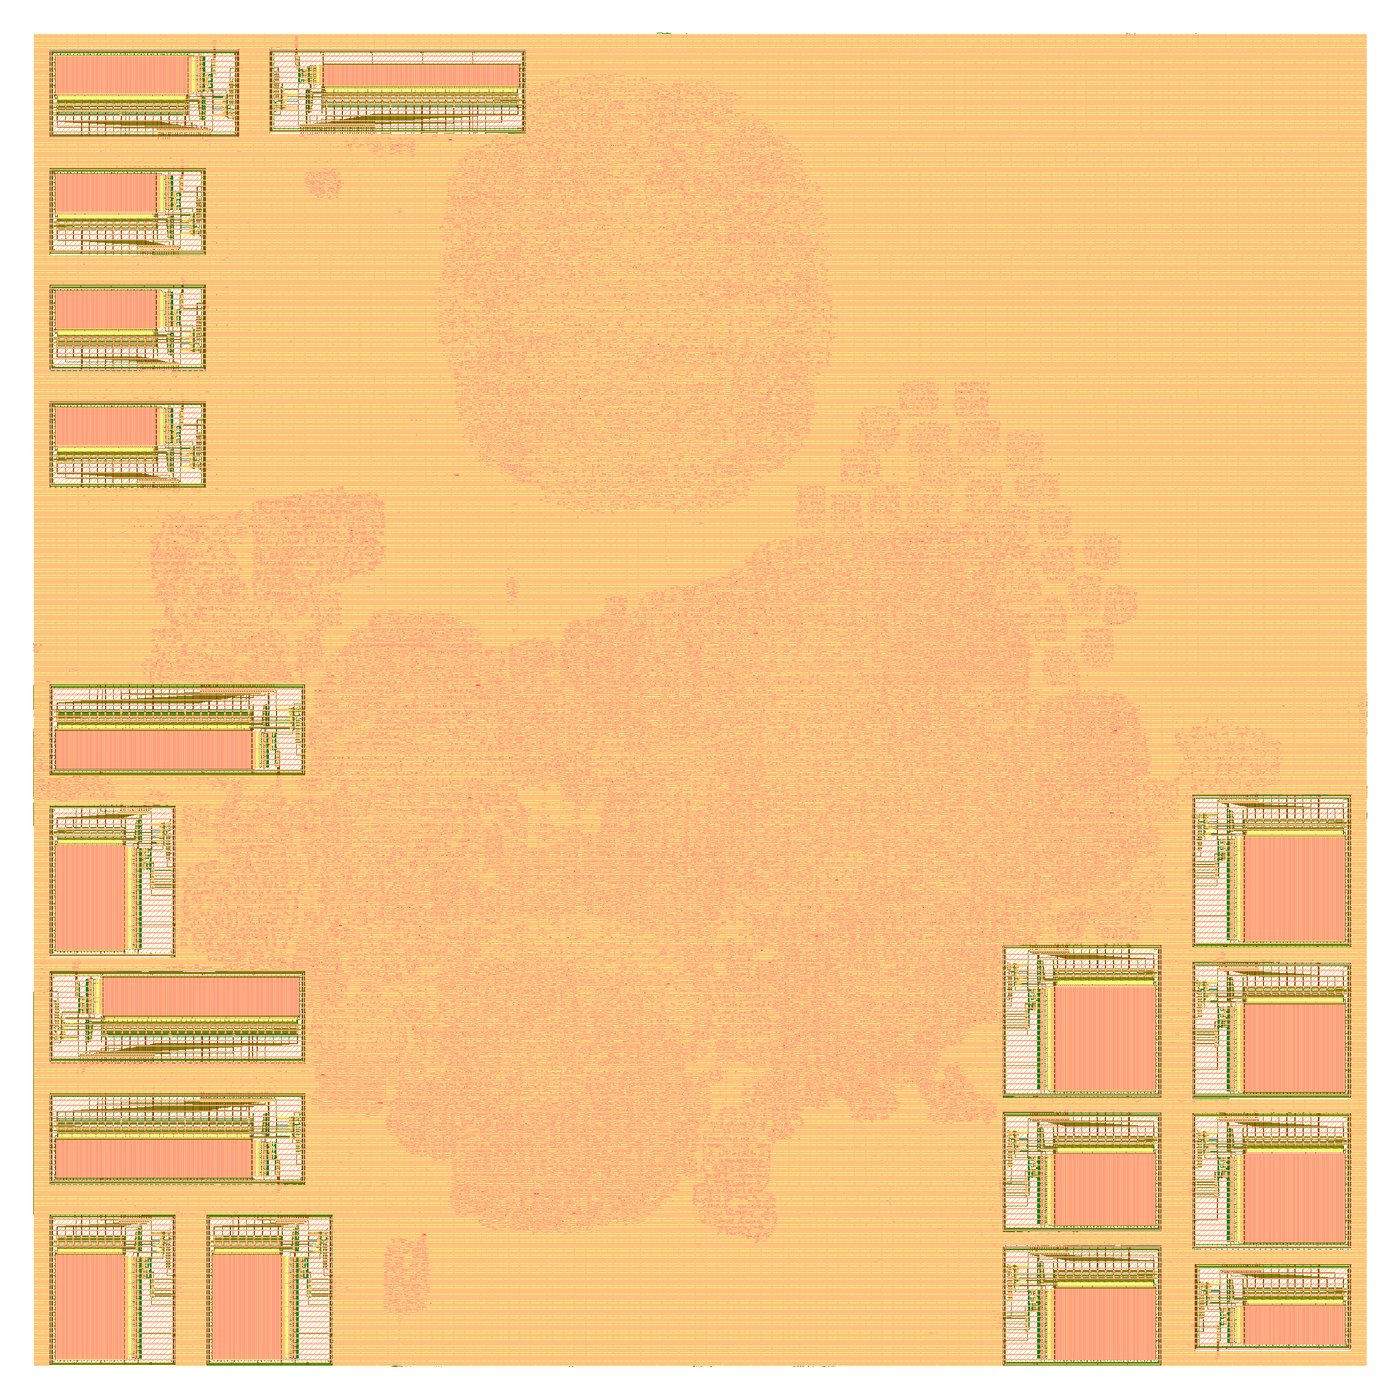

In [56]:
display(Image(str(ROOT/"figures/fullchip_layout.jpg"), width=640))

### C.3 Front-end design rules

ORFS runs the SKY130 KLayout deck with its front-end-of-line (FEOL) section disabled, so
`scripts/feol_drc.sh` runs that section on its own, skipping only `vpp.5`, which never finished and can
fire only on the capacitor layer that the script confirms to be empty. On the chip two implant-spacing
rules fired, every marker inside the OpenRAM macros, where abutted cells leave slivers that the deck
itself says should be merged by hand. `scripts/implant_fix.py` closes them as mask preparation would and
refuses to write a result if any transistor or resistor would change, and `scripts/verify_untouched.py`
confirms that everything outside the macros is identical, shape for shape. The corrected chip passes all
FEOL rules, as do all 27 block-level layouts.

In [57]:
fd = json.loads((ROOT/"results/fullchip/feol_drc.json").read_text())
fb = json.loads((ROOT/"results/asic/feol_blocks.json").read_text())["layouts"]
display(pd.DataFrame({"signed-off layout": fd["signed_off_gds"]["markers_by_rule"],
                      "after the implant fix": fd["after_implant_fix"]["markers_by_rule"]}).fillna(0).astype(int)
        .rename_axis("FEOL markers by rule"))
print(f"block-level layouts checked: {len(fb)}, FEOL markers in total: {sum(v['feol_markers'] for v in fb.values())}")
# guards for the statements made in the text above
assert set(fd["signed_off_gds"]["markers_by_rule"]) == {"n/psdm.1", "npc.2"}
assert fd["signed_off_gds"]["markers_by_location"] == {"OpenRAM macro": fd["signed_off_gds"]["markers_total"]}
assert fd["after_implant_fix"]["markers_total"] == 0
assert len(fb) == 27 and all(v["feol_markers"] == 0 and v["vpp_shapes"] == 0 for v in fb.values())
assert {"ntt_macro_20ns", "ntt_opt_pipe_macro_20ns", "ntt_opt_pipe_macro_12ns", "ntt_packed_20ns", "ntt_packed_12ns"} <= set(fb)

FEOL markers by rule,signed-off layout,after the implant fix
n/psdm.1,167408,0
npc.2,13048,0


block-level layouts checked: 27, FEOL markers in total: 0


### C.4 The energy of the SRAM macros

`scripts/sram_energy_spice.sh` simulates the transistor netlist of each macro type in ngspice at 25 MHz,
through idle cycles, writes and reads of random data, and repeated reads of one address, as most of the
chip's accesses are; every simulated read returns the data written. Because OpenRAM's netlists contain no
wiring, the four of the eight macro types whose layout could be simulated in reasonable time (12 × 256,
16 × 256, 24 × 128 and 24 × 256, bits × words) were simulated again from a flat extraction, and the ratio of the
two results scales their schematic energies; the other four take the mean ratio.

The wiring *lowers* the energy of an access, to between 0.65 and 0.77 of the schematic value, while it
raises that of an idle cycle by about a third. The read cycle below shows why: a current flows through
the accessed row for as long as the wordline is on, the whole 20 ns low half of the clock, and settles at
about 2.5 mA without the wiring but at 0.8 mA with it. Removing the capacitors from the extracted
netlist restores the schematic energy within a few percent, so the wiring capacitance is the cause,
although the circuit mechanism has not been isolated; and because the current lasts as long as the
wordline phase, these energies hold for 25 MHz only.

read [pJ],repeated read [pJ],write [pJ],idle cycle [pJ],wiring factor (access)
44.48,43.81,45.55,4.34,0.75
45.86,45.20,46.87,4.46,
47.67,46.98,48.49,4.46,
49.18,48.50,49.97,4.46,
59.17,58.34,60.66,5.03,0.77
71.52,70.73,73.62,6.29,0.65
83.11,81.75,85.53,6.47,0.73
34.25,33.65,34.62,3.88,


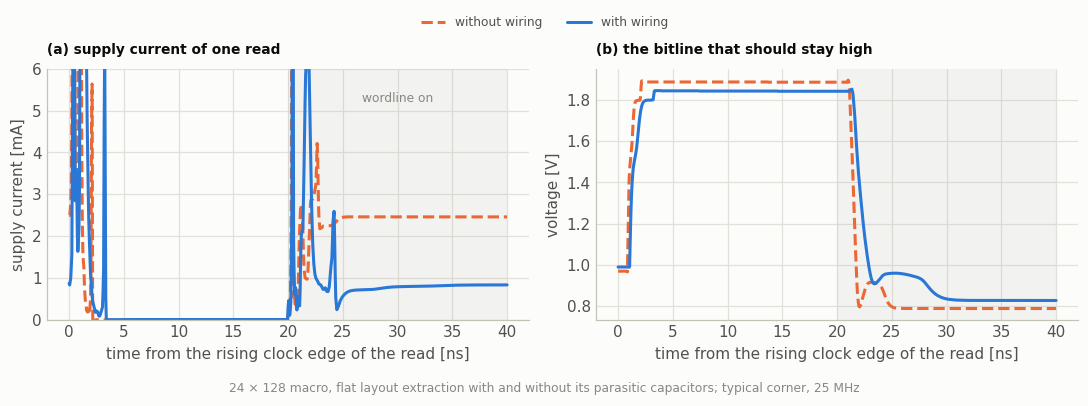

In [58]:
sm = json.loads((ROOT/"results/fullchip/sram_macro_spice.json").read_text())
se4 = json.loads((ROOT/"results/fullchip/sram_energy.json").read_text())
wd = json.loads((ROOT/"results/fullchip/sram_wiring_diagnosis.json").read_text())
macros = pd.DataFrame({m: {"read [pJ]": e["read_pj"], "repeated read [pJ]": e["read_repeat_pj"],
                           "write [pJ]": e["write_pj"], "idle cycle [pJ]": e["idle_pj"],
                           "wiring factor (access)": se4["wiring_factor"]["per_macro"].get(m, {}).get("access")}
                       for m, e in se4["masters"].items()}).T
macros.index = [re.sub(r"sky130_sram_1rw_(\d+)x(\d+).*", r"\1 bits × \2 words", m) for m in macros.index]
nbd.show(macros.round(2).rename_axis("macro, after wiring"))
wv = pd.read_csv(ROOT/"results/fullchip/sram_wiring_diagnosis_read_cycle.csv")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2), sharex=True)
for lab, ls_ in (("without wiring", "--"), ("with wiring", "-")):
    w = wv[wv.netlist == lab]
    ax[0].plot(w.t_ns, w.i_mA, ls=ls_, color=ps.SERIES[0] if lab == "with wiring" else ps.SERIES[1], label=lab)
    ax[1].plot(w.t_ns, w.br3, ls=ls_, color=ps.SERIES[0] if lab == "with wiring" else ps.SERIES[1])
for a in ax:
    a.axvspan(20, 40, color=ps.MUTED, alpha=0.08, lw=0)
    a.set_xlabel("time from the rising clock edge of the read [ns]")
ax[0].set_ylim(0, 6); ax[0].set_ylabel("supply current [mA]")
ax[1].set_ylabel("voltage [V]")
ax[0].text(30, 5.2, "wordline on", ha="center", color=ps.MUTED, fontsize=8)
ax[0].set_title("(a) supply current of one read", loc="left", fontsize=9)
ax[1].set_title("(b) the bitline that should stay high", loc="left", fontsize=9)
fig.legend(*ax[0].get_legend_handles_labels(), loc="upper center", ncol=2, frameon=False, fontsize=8,
           bbox_to_anchor=(0.5, 1.06))
fig.text(0.5, -0.04, "24 × 128 macro, flat layout extraction with and without its parasitic capacitors; typical corner, 25 MHz",
         ha="center", fontsize=8, color=ps.MUTED)
plt.tight_layout(); ps.save_pdf(fig, "sram_read_cycle"); plt.show()
# guards for the statements made in the text above
fac = sorted(f["access"] for f in se4["wiring_factor"]["per_macro"].values())
assert [round(f, 2) for f in (fac[0], fac[-1])] == [0.65, 0.77] and len(fac) == 4   # "four of the eight types"
assert fac[-1] < 1 and all(1.2 < f["idle"] < 1.45 for f in se4["wiring_factor"]["per_macro"].values())   # "lowers", "about a third"
assert all(all(v["reads_correct"]) and all(v["read_repeat_correct"]) for v in sm["macros"].values())
i_wo, i_w = (wd[k]["settled_current_wordline_on_ma"] for k in ("without_wiring", "with_wiring"))
assert round(i_wo, 1) == 2.5 and round(i_w, 1) == 0.8 and wd["with_wiring"]["clock_high_phase_pj"] > wd["without_wiring"]["clock_high_phase_pj"]
noc = sm["flat_layout_without_wiring_capacitance"]["macros"]["sky130_sram_1rw_24x128"]
sch = sm["macros"]["sky130_sram_1rw_24x128"]
assert abs(noc["read_pj"][0] / np.mean(sch["read_pj"]) - 1) < 0.05 and abs(noc["write_pj"][0] / np.mean(sch["write_pj"]) - 1) < 0.05

## D. FPGA details

### D.1 Resources and the FPGA store

On the FPGA the NTT occupies a few hundred ALMs, one M20K block and two DSP blocks, and Quartus stores only
12 bits per coefficient because the upper four are provably zero. The released bitstreams disable the
stand-alone NTT self-test, so on hardware the NTT is observed only within the flows of Section 9.

In [59]:
display(pd.DataFrame({k: v for k, v in fr.items() if isinstance(v, dict)}).T)
# guards for the statements made in the text above
ntt_fpga = fr["kyber_ntt_engine (u_shared_ntt)"]
assert 100 < float(ntt_fpga["alms_needed"].split()[0]) < 1000
assert (ntt_fpga["m20k"], ntt_fpga["dsp"], ntt_fpga["block_memory_bits"]) == ("1", "2", "3072")

,ALMs,registers,block-memory bits,M20K blocks,DSP blocks
NTT engine,375.3 (255.6),176 (176),3072,1,2
Keccak permutation (one round per clock),1881.5 (1881.5),1997 (1997),0,0,0
"Keccak sponge, including the permutation",4008.2 (2126.7),4046 (2049),0,0,0


### D.2 The host link

The ESP32 bit-bangs the SPI link at a nominal 10 kHz, chosen for robustness and not measured; the
effective rate of Section 9 follows from the logged latency and the 3,136 payload bytes of a run, and the run-to-run
spread stays under a millisecond.

## E. Reproducing every result

### E.1 Run time in Colab

A complete `Run all` takes about half an hour on a free Colab instance, almost all of it in Sections 4,
5 and 7, and the last cell reports the time of every section.

### E.2 Place-and-route, locally or in Colab

Place-and-route takes eight minutes to three and a half hours per design point on a desktop machine.
`RUN_PNR = True` regenerates the committed results on Linux with ORFS at commit `6101364b`, and the README
lists the commands behind every other result; only the chip-level ones need the unpublished layout
database. Without ORFS, `RUN_PNR_COLAB = True` downloads an archive of the very ORFS build used here
(`scripts/make_orfs_bundle.sh`), which reproduced every final metric of three design points in a pristine
Ubuntu 22.04 container, repeats the pipelined-NTT run and compares the result with the committed one.

In [60]:
bundle = json.loads((ROOT/"results/asic/bundle_reproduction.json").read_text())
for chk in bundle["checks"]:
    print(f"{nbd.label(chk['committed']):<34} {chk['label']}: {chk['identical']} of {chk['metrics_compared']} final metrics identical")
assert all(chk["identical"] == chk["metrics_compared"] for chk in bundle["checks"])

RUN_PNR_COLAB = False     # True: about 130 MB download and 30-45 minutes on a free Colab instance
BUNDLE_URL = ("https://github.com/tandat08052007/sscs-ose-code-a-chip.github.io/releases/download/"
              "hskem-orfs-6101364b/orfs-6101364b-sky130hd.tar.xz")
if RUN_PNR_COLAB:
    bdir = pathlib.Path("/content" if IN_COLAB else pathlib.Path.home())
    if not (bdir/"orfs").exists():
        sh(f"curl -sL {BUNDLE_URL} | tar xJ -C {bdir}")
    work = bdir/"cac_runs"
    target = work/"ntt_opt_pipe_w12_20ns_colab/logs/sky130hd/cac_ntt_opt_pipe_w12_20ns/base/6_report.log"
    sh(f"ORFS_ROOT={bdir}/orfs OPENROAD_EXE={bdir}/orfs/bin/openroad YOSYS_EXE={bdir}/orfs/bin/yosys "
       f"CAC_WORK={work} CAC_TAG_SUFFIX=_colab CAC_TARGET={target} bash scripts/run_orfs.sh ntt_opt_pipe_w12 20")
    print(sh("python3 scripts/compare_runs.py ntt_opt_pipe_w12_20ns ntt_opt_pipe_w12_20ns_colab")[:2000])

NTT iteration: + pipeline, 20 ns   clean ubuntu:22.04 container (udocker), 12 threads: 67 of 67 final metrics identical
NTT iteration: + pipeline, 20 ns   clean ubuntu:22.04 container (udocker), 2 threads, as on a free Colab instance: 67 of 67 final metrics identical
NTT, single-port store, 20 ns      clean ubuntu:22.04 container (udocker), 12 threads: 67 of 67 final metrics identical
Keccak, one round per clock, 20 ns clean ubuntu:22.04 container (udocker), 12 threads: 67 of 67 final metrics identical


### E.3 The published RTL

The RTL in `hskem_rtl/` differs from the source tree only as documented in `PUBLICATION_PATCH.diff`: a
provisioning test credential still used by my board is replaced by a public placeholder, with the
testbench's two provisioning tags recomputed and the measurements unchanged. The redesigned systems of
Section 8 are built from this copy on the fly: `scripts/make_packed_system.py` applies its edits behind
three defines, asserts that each of its anchors occurs exactly once and records them in
`results/system_sim/packed_system.diff`, and without the defines the built system repeats the published
one cycle for cycle. `rtl/` is copied from the source tree by `scripts/sync_rtl.sh`, with upstream hashes
and one documented portability change.

### E.4 Unit tests of the analysis scripts

The scripts that turn simulation output into numbers are tested on small inputs with hand-computed
results, in under a second, by the next cell.

In [61]:
out = sh("python3 -m pytest -q -p no:cacheprovider tests")
assert " passed" in out and "failed" not in out and "error" not in out.lower()

....                                                                     [100%]
4 passed in 0.25s
 


In [62]:
# the timer starts with the third code cell; earlier cells (clone, tool download) count in the total only
SECTIONS = ['At a glance', '1. Context', '2. An independent golden model', '2. An independent golden model', '3. RTL architecture and an analytical cycle model', '3. RTL architecture and an analytical cycle model', '3. RTL architecture and an analytical cycle model', '4. RTL against the golden model and the NIST vectors', '4. RTL against the golden model and the NIST vectors', '4. RTL against the golden model and the NIST vectors', '4. RTL against the golden model and the NIST vectors', '5. Synthesis', '5. Synthesis', '6. Place-and-route', '6. Place-and-route', '6. Place-and-route', '6. Place-and-route', '6. Place-and-route', '7. Closing the loop', '7. Closing the loop', '7. Closing the loop', '7. Closing the loop', '7. Closing the loop', '7. Closing the loop', '7. Closing the loop', '7. Closing the loop', '7. Closing the loop', '8. The full chip', '8. The full chip', '8. The full chip', '8. The full chip', '8. The full chip', '8. The full chip', '9. The same RTL on the FPGA board', '9. The same RTL on the FPGA board', '9. The same RTL on the FPGA board', '9. The same RTL on the FPGA board', '10. What is not yet protected', '11. Findings', '11. Findings', '11. Findings', 'A. Verification details', 'A. Verification details', 'B. Place-and-route details', 'B. Place-and-route details', 'B. Place-and-route details', 'B. Place-and-route details', 'B. Place-and-route details', 'B. Place-and-route details', 'B. Place-and-route details', 'B. Place-and-route details', 'B. Place-and-route details', 'C. Chip-level details', 'C. Chip-level details', 'C. Chip-level details', 'C. Chip-level details', 'D. FPGA details', 'E. Reproducing every result', 'E. Reproducing every result']
total = (time.time() - T_START) / 60
if len(nbd.DURATIONS) == len(SECTIONS):          # a single top-to-bottom run
    t = pd.Series(nbd.DURATIONS, index=SECTIONS).groupby(level=0, sort=False).sum() / 60
    t["Setup and untimed cells"] = total - t.sum()
    nbd.show(t.round(1).rename("minutes").rename_axis("Section").reset_index())
display(Markdown(f"**Notebook finished in {total:.1f} min** ({'Colab' if IN_COLAB else 'local'} run)."))

Section,minutes
At a glance,0.0
1. Context,0.0
2. An independent golden model,0.0
3. RTL architecture and an analytical cycle model,0.0
4. RTL against the golden model and the NIST vectors,0.1
5. Synthesis,0.0
6. Place-and-route,0.1
7. Closing the loop,0.0
8. The full chip,0.2
9. The same RTL on the FPGA board,0.0


**Notebook finished in 0.7 min** (local run).